# All CNN Experiments Performed using Google Colab's T4 GPU

In [1]:
#now running jobs with integrated colab for vscode...
!nvidia-smi

Fri Jul 31 08:57:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
!git clone https://github.com/henrybattley/neurons-as-autoencoders.git

Cloning into 'neurons-as-autoencoders'...
remote: Enumerating objects: 1317, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 1317 (delta 58), reused 51 (delta 29), pack-reused 1229 (from 1)
Receiving objects: 100% (1317/1317), 3.76 MiB | 10.36 MiB/s, done.
Resolving deltas: 100% (1006/1006), done.


In [2]:
#once we have already cloned the repo we can pull it down when if we make changes and push them

%cd neurons-as-autoencoders
!git pull

/content/neurons-as-autoencoders
Already up to date.


# Imports...

In [3]:
import sys
import os
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
#get model
from src.models import cnn_model
from src.models import conv_autoencoder
from src.models import weight_tied_conv_autoencoder

#get experiment
from src.experiments import cnn_experiments

In [5]:
import random
import numpy as np
import pandas as pd
import torch, torchvision
import torch.nn as nn
from torchsummary import summary
import importlib
import matplotlib.pyplot as plt


# Parameter Counting

In [6]:
#count how many params of the model...

#just to make sure we are getting the most current file version 
importlib.reload(cnn_model)  

device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        pool_padding=0,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (16, 1, 3, 3) -> 144
conv1.bias           (16,) -> 16
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31530


# Inspecting MACS  (multiply accumulate operations)

In [6]:
!pip install thop
from thop import profile

In [7]:
dummy = torch.randn(1, 1, 28, 28)

macs, params = profile(model, inputs=(dummy,))

print(f"MACs   : {macs:,}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
MACs   : 144,256.0


In [8]:
print(f"The conv layer: \n {profile(model.conv1, inputs=(dummy,))} \n =")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
The conv layer: 
 (112896.0, 0) 
 =


In [9]:
print(f"The fully connected layer: \n {profile(model.fc, inputs=(torch.randn(1,3136),))} \n =")

[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
The fully connected layer: 
 (31360.0, 0) 
 =


---------------------Explaining MACs for standard cnn:---------------------------
<br>
<br>
28x28 outputs x 3x3 kernels = 784 x 9 = 7056
<br>
so 7056 x 16 for the feature maps = 7056 x 16 = 112,896 (half as much as the autoencoding cnn)
<br>
then the classifier does 3136×10 (for the flattened input for each class)
<br>
so this gives 31,360 + 112,896  = 144,256 (slightly over half of the amount required for the filters as encoders method)

# Getting MNIST Data...

In [6]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [7]:
# getting data
print("Loading MNIST dataset...")
mnist_raw = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
)

#dataset to a GPU-ready float tensor 
# Extract raw PIL data (.data is a 60000x28x28 unit8 tensor)
mnist_images = mnist_raw.data.float() / 255.0  # Scale to [0.0, 1.0]
mnist_images = mnist_images.unsqueeze(1)        # Shape becomes (60000, 1, 28, 28)
mnist_labels = mnist_raw.targets                # Shape (60000,)

#Wrap in a TensorDataset
mnist = torch.utils.data.TensorDataset(mnist_images, mnist_labels)

Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.41MB/s]


# Initial 1-Layer CNN Training...

In [21]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []



for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)




model run: 0
device is: cuda
Epoch [1/1], Training Loss: 0.4247, Training Accuracy: 88.37
peak memory from train : 55.50927734375
memory now reset and is: 17.4931640625 MB
time elapsed: 1.0449179279999044
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 0.4085, Training Accuracy: 88.21
Epoch [2/100], Training Loss: 0.1788, Training Accuracy: 94.99
Epoch [3/100], Training Loss: 0.1223, Training Accuracy: 96.61
Epoch [4/100], Training Loss: 0.0940, Training Accuracy: 97.38
Epoch [5/100], Training Loss: 0.0786, Training Accuracy: 97.80
Epoch [6/100], Training Loss: 0.0685, Training Accuracy: 98.08
Epoch [7/100], Training Loss: 0.0617, Training Accuracy: 98.25
Epoch [8/100], Training Loss: 0.0559, Training Accuracy: 98.41
Epoch [9/100], Training Loss: 0.0524, Training Accuracy: 98.51
Epoch [10/100], Training Loss: 0.0479, Training Accuracy: 98.59
Epoch [11/100], Training Loss: 0.0448, Training Accuracy: 98.74
Epoch [12/100], Training Loss: 0.0420, Training Accuracy: 98.76
Epoch [

In [22]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [23]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})



In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_epoch_results.csv",
    index=False,
)

# Loss and Accuracy...

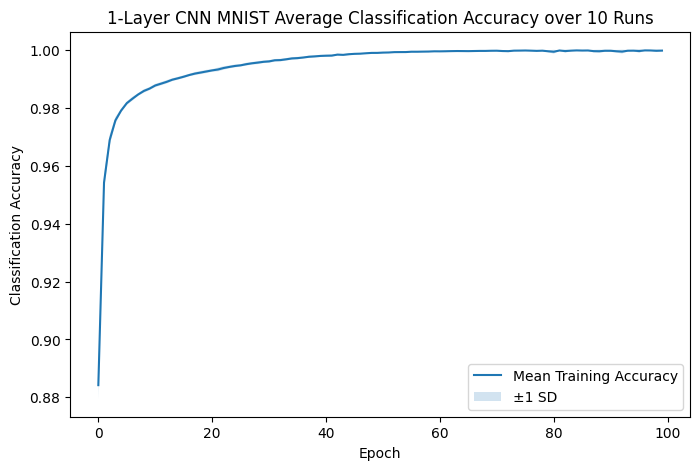

In [23]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer CNN MNIST Average Classification Accuracy over 10 Runs")
plt.show()

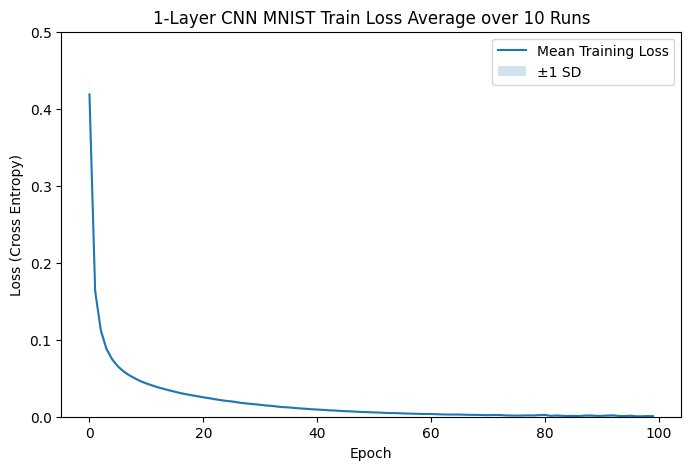

In [32]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Train Loss Average over 10 Runs")
plt.show()

# Memory overhead and Runtime

In [33]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory



Mean max memory allocated: 55.51025390625
All peak memories (including the warm up run):


[55.26708984375,
 55.51025390625,
 55.51025390625,
 55.51025390625,
 55.51025390625,
 55.51025390625,
 55.51025390625,
 55.51025390625,
 55.51025390625,
 55.51025390625,
 55.51025390625]

In [34]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times


Mean training time for 100 epochs over the 10 runs: 89.28219062299999 
All training times for the 100 epochs over the 10 runs:


array([88.53375548, 89.77323623, 89.46553108, 88.74594126, 89.96939909,
       88.1626449 , 89.23945421, 89.79347427, 89.38435583, 89.75411389])

In [27]:
print(f"Max accuracy: {epoch_df["mean_accuracy"].max()}")
print(f"Max accuracy std: {epoch_df["std_accuracy"].max()}")

print(f"Min Loss: {epoch_df["mean_loss"].min()}")
print(f"Max Loss std: {epoch_df["std_loss"].max()}")

Max accuracy: 99.99883333333334
Max accuracy std: 0.48674314467580143
Min Loss: 0.0005754488167610575
Max Loss std: 0.02227178409840209


# Cutting down the CNN 
### Firstly measuring results with 1 feature map... (kernel reset before timing another model run)

In [35]:
!nvidia-smi

Thu Jul 23 10:33:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             28W /   70W |     209MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Paramter count

In [ ]:
#count how many params of the model...

#just to make sure we are getting the most current file version 
importlib.reload(cnn_model)  

device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        pool_padding=0,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=1,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (1, 1, 3, 3) -> 9
conv1.bias           (1,) -> 1
fc.weight            (10, 196) -> 1960
fc.bias              (10,) -> 10
1980


In [ ]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=1,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)





model run: 0
device is: cuda
Epoch [1/1], Training Loss: 1.2463, Training Accuracy: 0.64
peak memory from train : 23.85009765625
memory now reset and is: 17.2685546875 MB
time elapsed: 1.8526025800001662
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 1.5556, Training Accuracy: 0.58
Epoch [2/100], Training Loss: 0.5120, Training Accuracy: 0.86
Epoch [3/100], Training Loss: 0.3821, Training Accuracy: 0.89
Epoch [4/100], Training Loss: 0.3433, Training Accuracy: 0.90
Epoch [5/100], Training Loss: 0.3238, Training Accuracy: 0.91
Epoch [6/100], Training Loss: 0.3114, Training Accuracy: 0.91
Epoch [7/100], Training Loss: 0.3040, Training Accuracy: 0.91
Epoch [8/100], Training Loss: 0.2980, Training Accuracy: 0.91
Epoch [9/100], Training Loss: 0.2934, Training Accuracy: 0.91
Epoch [10/100], Training Loss: 0.2896, Training Accuracy: 0.92
Epoch [11/100], Training Loss: 0.2867, Training Accuracy: 0.92
Epoch [12/100], Training Loss: 0.2846, Training Accuracy: 0.92
Epoch [13/100], Trai

In [7]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=1,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)





model run: 0
device is: cuda
Epoch [1/1], Training Loss: 1.2463, Training Accuracy: 63.86
peak memory from train : 23.85009765625
memory now reset and is: 17.2685546875 MB
time elapsed: 2.180195736999849
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 1.5556, Training Accuracy: 57.88
Epoch [2/100], Training Loss: 0.5120, Training Accuracy: 85.85
Epoch [3/100], Training Loss: 0.3821, Training Accuracy: 88.83
Epoch [4/100], Training Loss: 0.3433, Training Accuracy: 89.92
Epoch [5/100], Training Loss: 0.3238, Training Accuracy: 90.59
Epoch [6/100], Training Loss: 0.3114, Training Accuracy: 90.94
Epoch [7/100], Training Loss: 0.3040, Training Accuracy: 91.16
Epoch [8/100], Training Loss: 0.2980, Training Accuracy: 91.27
Epoch [9/100], Training Loss: 0.2934, Training Accuracy: 91.43
Epoch [10/100], Training Loss: 0.2896, Training Accuracy: 91.58
Epoch [11/100], Training Loss: 0.2867, Training Accuracy: 91.63
Epoch [12/100], Training Loss: 0.2846, Training Accuracy: 91.68
Epoch [1

In [9]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [12]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})


In [14]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_epoch_results_1_filter.csv",
    index=False,
)

# Loss and Accuracy

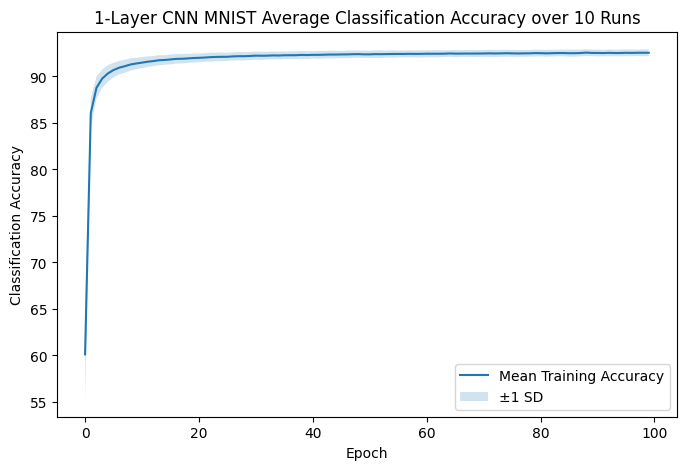

In [15]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer CNN MNIST Average Classification Accuracy over 10 Runs")
plt.show()

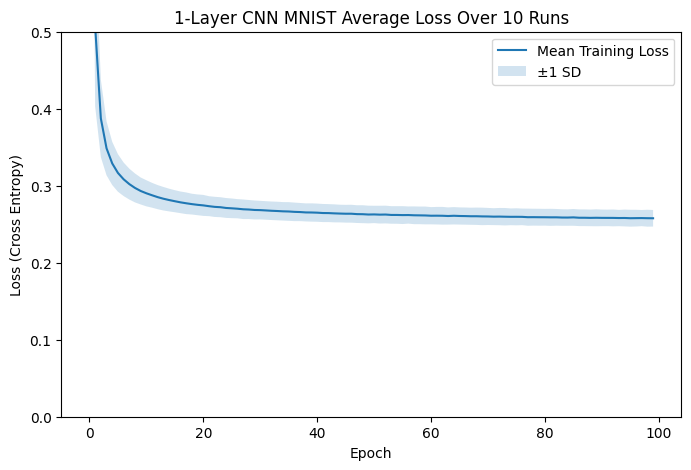

In [16]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Average Loss Over 10 Runs")
plt.show()

In [10]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory



Mean max memory allocated: 23.86865234375
All peak memories (including the warm up run):


[23.85009765625,
 23.86865234375,
 23.86865234375,
 23.86865234375,
 23.86865234375,
 23.86865234375,
 23.86865234375,
 23.86865234375,
 23.86865234375,
 23.86865234375,
 23.86865234375]

In [11]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 85.69773227949995 
All training times for the 100 epochs over the 10 runs:


array([85.7765011 , 85.35833315, 85.73336026, 85.63180045, 85.71284674,
       86.29651664, 85.00206613, 85.46021045, 86.72810245, 85.27758542])

# Removing The Conv Bias
### Results on the 16-filter model

In [ ]:
#count how many params of the model...

#just to make sure we are getting the most current file version 
importlib.reload(cnn_model)  

device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        pool_padding=0,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        classes=10,
        bias=False
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (16, 1, 3, 3) -> 144
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31514


In [7]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)




model run: 0
device is: cuda
Epoch [1/1], Training Loss: 0.4177, Training Accuracy: 88.45
peak memory from train : 55.265625
memory now reset and is: 17.4921875 MB
time elapsed: 1.8427256259997193
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 0.3967, Training Accuracy: 88.48
Epoch [2/100], Training Loss: 0.1778, Training Accuracy: 94.92
Epoch [3/100], Training Loss: 0.1262, Training Accuracy: 96.47
Epoch [4/100], Training Loss: 0.1024, Training Accuracy: 97.15
Epoch [5/100], Training Loss: 0.0880, Training Accuracy: 97.56
Epoch [6/100], Training Loss: 0.0789, Training Accuracy: 97.77
Epoch [7/100], Training Loss: 0.0724, Training Accuracy: 97.95
Epoch [8/100], Training Loss: 0.0658, Training Accuracy: 98.12
Epoch [9/100], Training Loss: 0.0617, Training Accuracy: 98.24
Epoch [10/100], Training Loss: 0.0570, Training Accuracy: 98.35
Epoch [11/100], Training Loss: 0.0543, Training Accuracy: 98.42
Epoch [12/100], Training Loss: 0.0511, Training Accuracy: 98.49
Epoch [13/100],

In [8]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [9]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})


In [11]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/simple_cnn_epoch_results_.csv",
    index=False,
)

# Loss and Accuracy

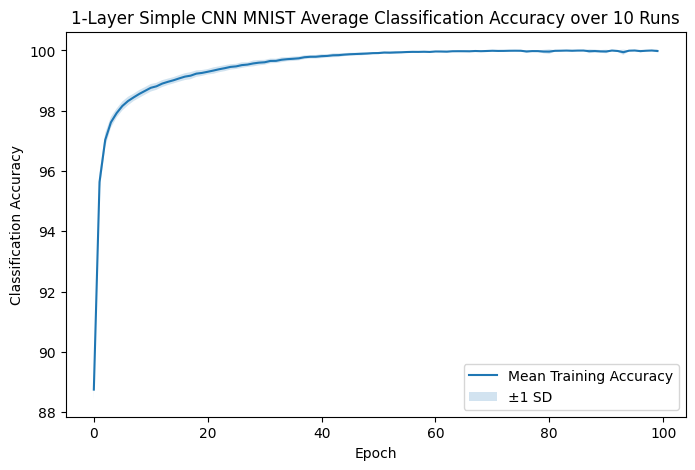

In [12]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Simple CNN MNIST Average Classification Accuracy over 10 Runs")
plt.show()

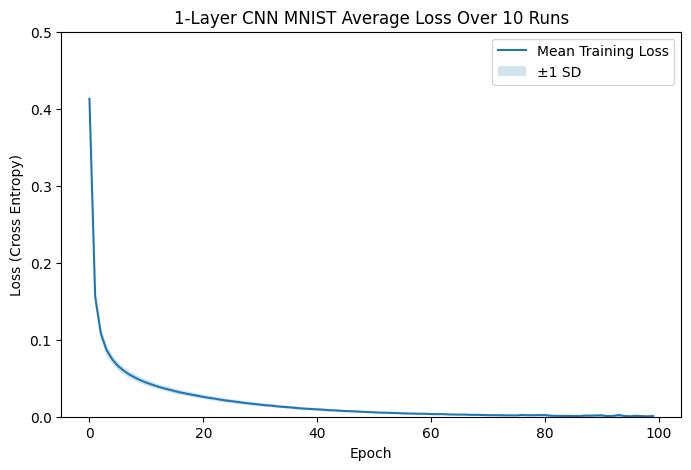

In [13]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Average Loss Over 10 Runs")
plt.show()

In [14]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 55.5078125
All peak memories (including the warm up run):


[55.265625,
 55.5078125,
 55.5078125,
 55.5078125,
 55.5078125,
 55.5078125,
 55.5078125,
 55.5078125,
 55.5078125,
 55.5078125,
 55.5078125]

In [15]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 88.049182091 
All training times for the 100 epochs over the 10 runs:


array([88.8716195 , 88.82773428, 87.18130626, 88.0160529 , 87.69295664,
       88.94198355, 87.73117275, 87.20084319, 88.1587007 , 87.86945113])

# Removing bias from the 1-filter cnn...

In [ ]:
#count how many params of the model...

#just to make sure we are getting the most current file version 
importlib.reload(cnn_model)  

device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        pool_padding=0,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=1,
        classes=10,
        bias=False
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (1, 1, 3, 3) -> 9
fc.weight            (10, 196) -> 1960
fc.bias              (10,) -> 10
1979


In [7]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=1,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)




model run: 0
device is: cuda
Epoch [1/1], Training Loss: 1.2048, Training Accuracy: 64.48
peak memory from train : 23.8486328125
memory now reset and is: 17.267578125 MB
time elapsed: 1.7776156609997997
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 1.5209, Training Accuracy: 56.45
Epoch [2/100], Training Loss: 0.4607, Training Accuracy: 86.81
Epoch [3/100], Training Loss: 0.3674, Training Accuracy: 89.36
Epoch [4/100], Training Loss: 0.3351, Training Accuracy: 90.27
Epoch [5/100], Training Loss: 0.3174, Training Accuracy: 90.79
Epoch [6/100], Training Loss: 0.3066, Training Accuracy: 91.14
Epoch [7/100], Training Loss: 0.2993, Training Accuracy: 91.39
Epoch [8/100], Training Loss: 0.2933, Training Accuracy: 91.54
Epoch [9/100], Training Loss: 0.2890, Training Accuracy: 91.62
Epoch [10/100], Training Loss: 0.2851, Training Accuracy: 91.75
Epoch [11/100], Training Loss: 0.2822, Training Accuracy: 91.87
Epoch [12/100], Training Loss: 0.2796, Training Accuracy: 91.98
Epoch [13

In [8]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [9]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})

In [10]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/simple_cnn_epoch_results_1_filter.csv",
    index=False,
)

# Loss and Accuracy

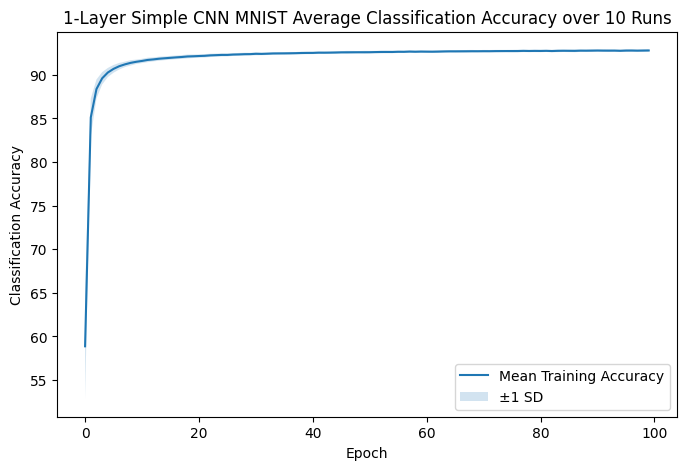

In [11]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Simple CNN MNIST Average Classification Accuracy over 10 Runs")
plt.show()

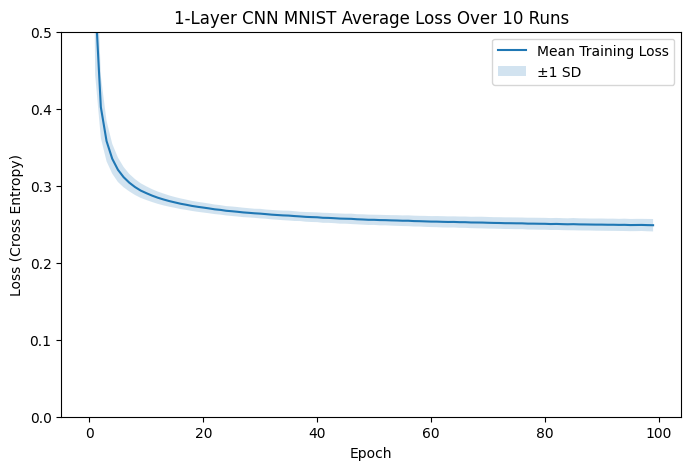

In [12]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Average Loss Over 10 Runs")
plt.show()

In [13]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 23.8662109375
All peak memories (including the warm up run):


[23.8486328125,
 23.8662109375,
 23.8662109375,
 23.8662109375,
 23.8662109375,
 23.8662109375,
 23.8662109375,
 23.8662109375,
 23.8662109375,
 23.8662109375,
 23.8662109375]

In [14]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 82.76328396909985 
All training times for the 100 epochs over the 10 runs:


array([82.21688046, 82.28906721, 81.46452547, 81.67104489, 84.11837706,
       82.61462112, 82.15667327, 83.85509392, 84.70212559, 82.5444307 ])

# Feature map compression with no pooling 

In [18]:
from src.models import cnn_model_no_pooling

# Inspect model here

In [20]:
#count how many params of the model...

#just to make sure we are getting the most current file version 
importlib.reload(cnn_model_no_pooling)  

device = torch.device('cpu')

model = cnn_model_no_pooling.CNN(
        input_dims=28,
        in_channels=1,
        kernel_size=3,
        stride=2,
        padding=1,
        n_filters=16,
        classes=10,
        bias=False
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (16, 1, 3, 3) -> 144
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31514


In [7]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_no_pool_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=2,
        padding=1,
        kernel_size=3,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)




model run: 0
device is: cuda
Epoch [1/1], Training Loss: 0.4825, Training Accuracy: 87.16
peak memory from train : 27.703125
memory now reset and is: 17.4921875 MB
time elapsed: 1.6241447730001255
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 0.4282, Training Accuracy: 87.81
Epoch [2/100], Training Loss: 0.2097, Training Accuracy: 94.15
Epoch [3/100], Training Loss: 0.1571, Training Accuracy: 95.61
Epoch [4/100], Training Loss: 0.1289, Training Accuracy: 96.39
Epoch [5/100], Training Loss: 0.1107, Training Accuracy: 96.89
Epoch [6/100], Training Loss: 0.0976, Training Accuracy: 97.29
Epoch [7/100], Training Loss: 0.0890, Training Accuracy: 97.50
Epoch [8/100], Training Loss: 0.0808, Training Accuracy: 97.73
Epoch [9/100], Training Loss: 0.0752, Training Accuracy: 97.87
Epoch [10/100], Training Loss: 0.0691, Training Accuracy: 98.07
Epoch [11/100], Training Loss: 0.0647, Training Accuracy: 98.19
Epoch [12/100], Training Loss: 0.0611, Training Accuracy: 98.21
Epoch [13/100],

In [8]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [9]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})

In [10]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/simple_cnn__no_pooling_epoch_results_compressed_map_.csv",
    index=False,
)

# Loss and Accuracy

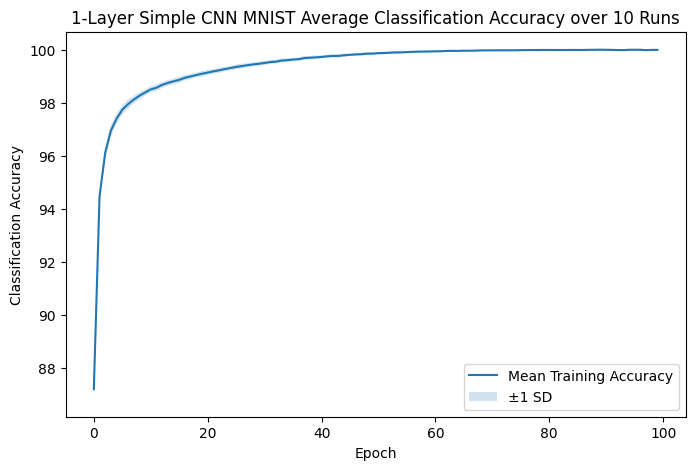

In [11]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Simple CNN MNIST Average Classification Accuracy over 10 Runs")
plt.show()

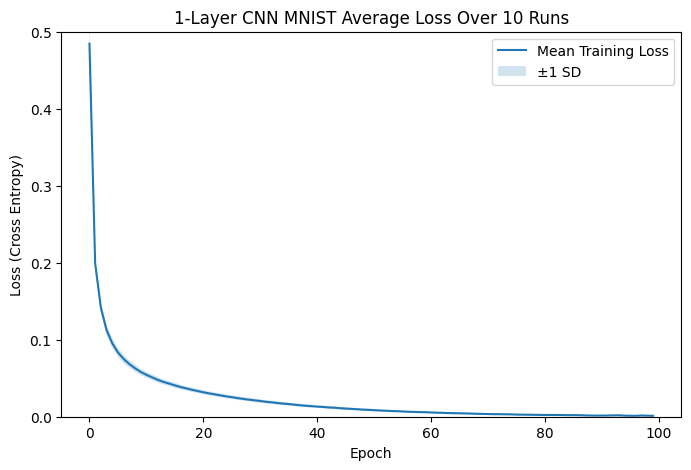

In [12]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Average Loss Over 10 Runs")
plt.show()

# Memory and Runtime

In [13]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory


Mean max memory allocated: 27.9453125
All peak memories (including the warm up run):


[27.703125,
 27.9453125,
 27.9453125,
 27.9453125,
 27.9453125,
 27.9453125,
 27.9453125,
 27.9453125,
 27.9453125,
 27.9453125,
 27.9453125]

In [14]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times


Mean training time for 100 epochs over the 10 runs: 92.67511904300002 
All training times for the 100 epochs over the 10 runs:


array([95.5723789 , 91.87058521, 95.59209672, 93.46705936, 93.49806959,
       94.64697886, 89.81139799, 91.64949514, 90.41590066, 90.227228  ])

# No Pooling with 28x28 feature map

In [40]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_no_pool_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)




model run: 0
device is: cuda
Epoch [1/1], Training Loss: 0.3014, Training Accuracy: 91.55
peak memory from train : 74.1474609375
memory now reset and is: 34.6962890625 MB
time elapsed: 0.8280491679997795
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 0.2914, Training Accuracy: 91.53
Epoch [2/100], Training Loss: 0.1266, Training Accuracy: 96.47
Epoch [3/100], Training Loss: 0.0871, Training Accuracy: 97.56
Epoch [4/100], Training Loss: 0.0686, Training Accuracy: 98.07
Epoch [5/100], Training Loss: 0.0568, Training Accuracy: 98.37
Epoch [6/100], Training Loss: 0.0485, Training Accuracy: 98.61
Epoch [7/100], Training Loss: 0.0425, Training Accuracy: 98.78
Epoch [8/100], Training Loss: 0.0366, Training Accuracy: 98.96
Epoch [9/100], Training Loss: 0.0336, Training Accuracy: 99.03
Epoch [10/100], Training Loss: 0.0282, Training Accuracy: 99.21
Epoch [11/100], Training Loss: 0.0260, Training Accuracy: 99.28
Epoch [12/100], Training Loss: 0.0229, Training Accuracy: 99.38
Epoch [1

In [41]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [42]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})

In [43]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/simple_cnn__no_pooling_epoch_results_28x28_map_.csv",
    index=False,
)

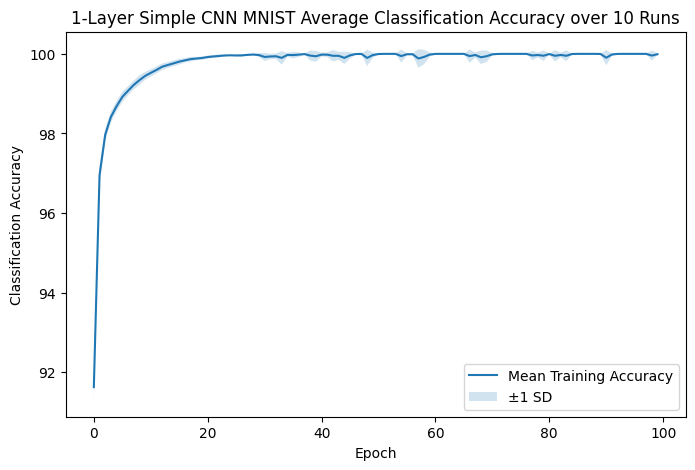

In [44]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Simple CNN MNIST Average Classification Accuracy over 10 Runs")
plt.show()

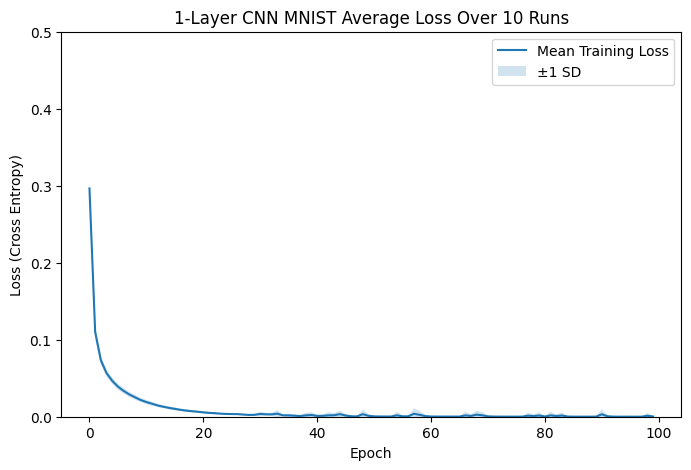

In [45]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Average Loss Over 10 Runs")
plt.show()

In [46]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 74.1474609375
All peak memories (including the warm up run):


[74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375,
 74.1474609375]

In [47]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 86.69673116160011 
All training times for the 100 epochs over the 10 runs:


array([85.88106141, 87.10546731, 86.29689907, 87.25064941, 85.93680766,
       87.24243756, 86.42516608, 87.13120797, 86.32221512, 87.37540004])

In [49]:
print(f"Max accuracy: {epoch_df["mean_accuracy"].max()}")
print(f"Max accuracy std: {epoch_df["std_accuracy"].max()}")

print(f"Min Loss: {epoch_df["mean_loss"].min()}")
print(f"Max Loss std: {epoch_df["std_loss"].max()}")


Max accuracy: 100.0
Max accuracy std: 0.3033406592521963
Min Loss: 4.687615115433298e-05
Max Loss std: 0.011302039990117833


# Inspecting Learned Features and Kernels for model seed=0

In [8]:
all_train_histories = []
all_train_accuracies = []

peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_cnn_get_features(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Training Loss: 0.4247, Training Accuracy: 88.37
Epoch [2/100], Training Loss: 0.1706, Training Accuracy: 95.18
Epoch [3/100], Training Loss: 0.1183, Training Accuracy: 96.74
Epoch [4/100], Training Loss: 0.0924, Training Accuracy: 97.52
Epoch [5/100], Training Loss: 0.0789, Training Accuracy: 97.83
Epoch [6/100], Training Loss: 0.0682, Training Accuracy: 98.15
Epoch [7/100], Training Loss: 0.0606, Training Accuracy: 98.31
Epoch [8/100], Training Loss: 0.0557, Training Accuracy: 98.46
Epoch [9/100], Training Loss: 0.0507, Training Accuracy: 98.57
Epoch [10/100], Training Loss: 0.0467, Training Accuracy: 98.72
Epoch [11/100], Training Loss: 0.0439, Training Accuracy: 98.74
Epoch [12/100], Training Loss: 0.0406, Training Accuracy: 98.85
Epoch [13/100], Training Loss: 0.0386, Training Accuracy: 98.94
Epoch [14/100], Training Loss: 0.0367, Training Accuracy: 99.00
Epoch [15/100], Training Loss: 0.0340, Training Accuracy: 99.07
Epoch [16/100], Trai

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
#save the features history 
features_df= pd.DataFrame(feature_history)

features_df.to_csv(
    "/content/drive/MyDrive/research_jobs/standard_cnn_features.csv",
    index=False,
)

# Loss and Accuracy

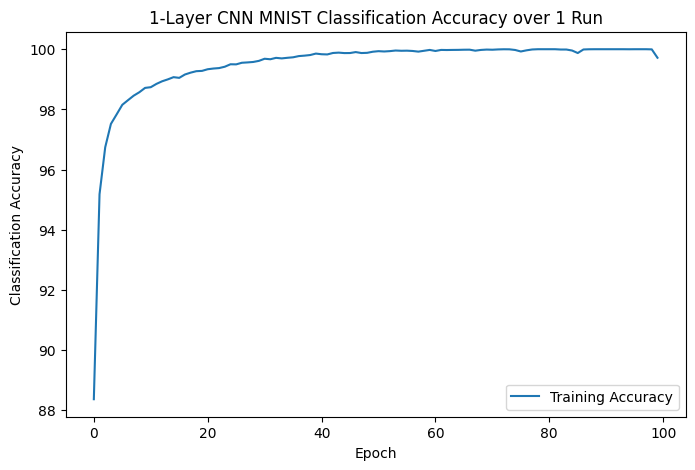

In [12]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")



plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer CNN MNIST Classification Accuracy over 1 Run")
plt.show()

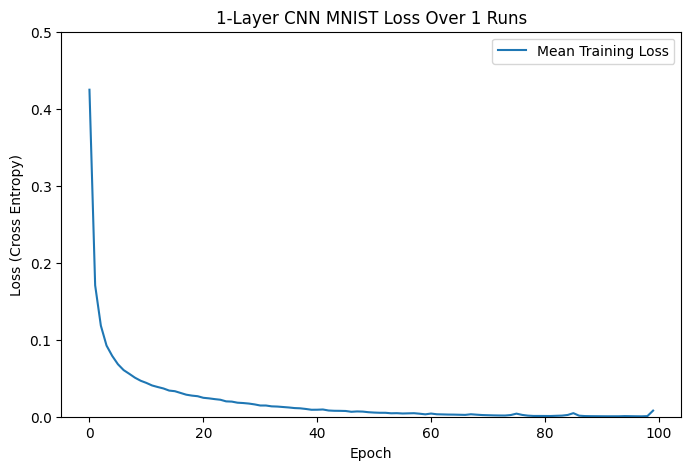

In [13]:
epochs = np.arange(len(training_history["train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_loss"],label="Mean Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Loss Over 1 Runs")
plt.show()

# Visualising...

In [14]:
print(feature_history.keys())

dict_keys([0, 1, 15, 30, 45, 60, 75, 90, 99])


In [15]:
print(feature_history[1].keys())

dict_keys(['label', 'prediction', 'logits', 'original', 'maps', 'pooled_maps', 'kernel_weights'])


# Original

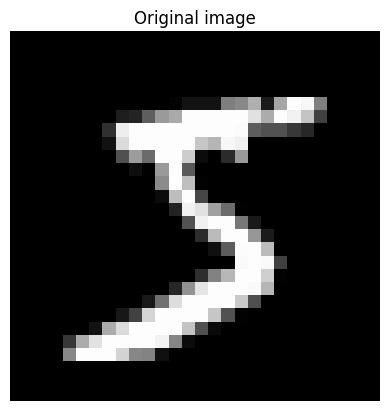

In [16]:
epoch = 0

img = feature_history[epoch]["original"][0,0]

plt.imshow(img, cmap="gray")
plt.title(f"Original image")
plt.axis("off")
plt.show()

# Feature Maps

### Epoch 1:

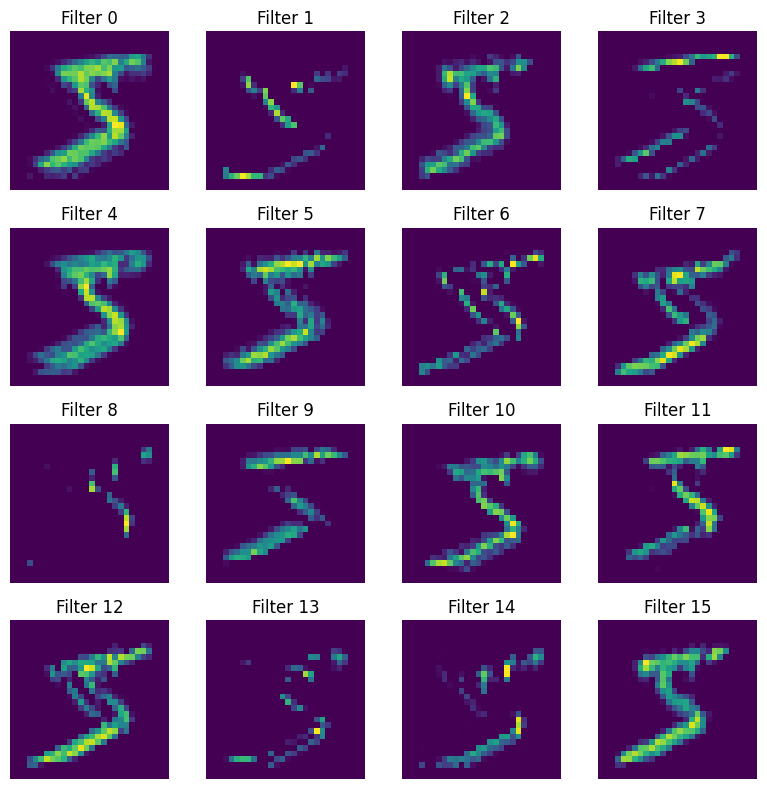

In [17]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[0]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Epoch 2:

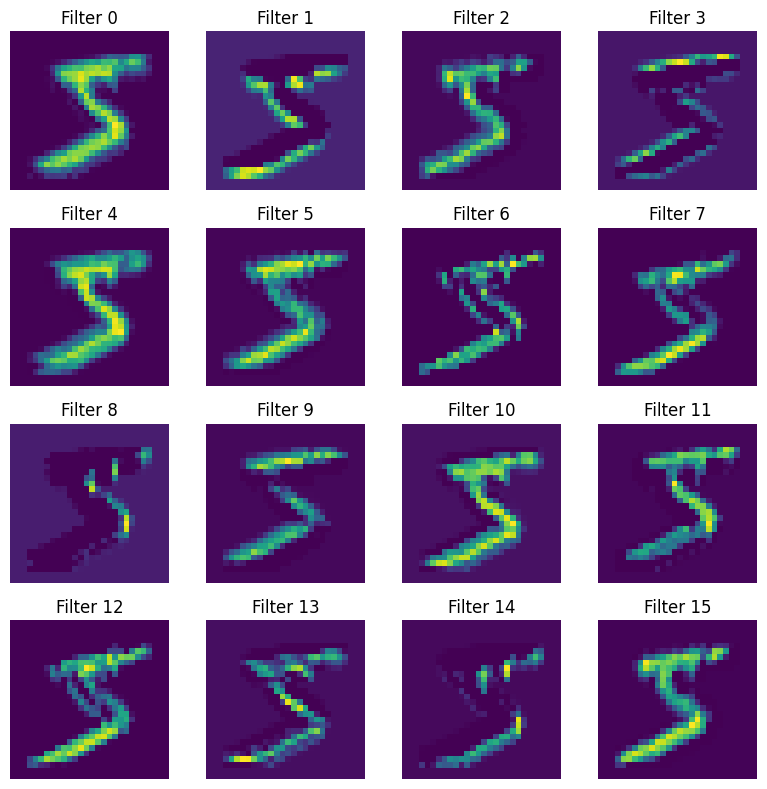

In [18]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[1]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Epoch 15:

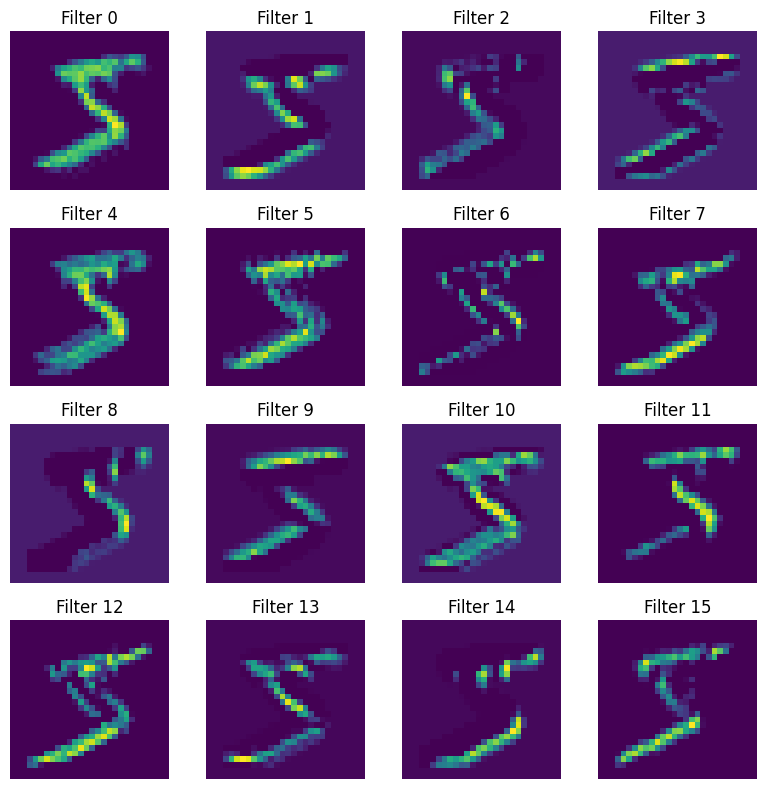

In [19]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[15]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Epoch 30

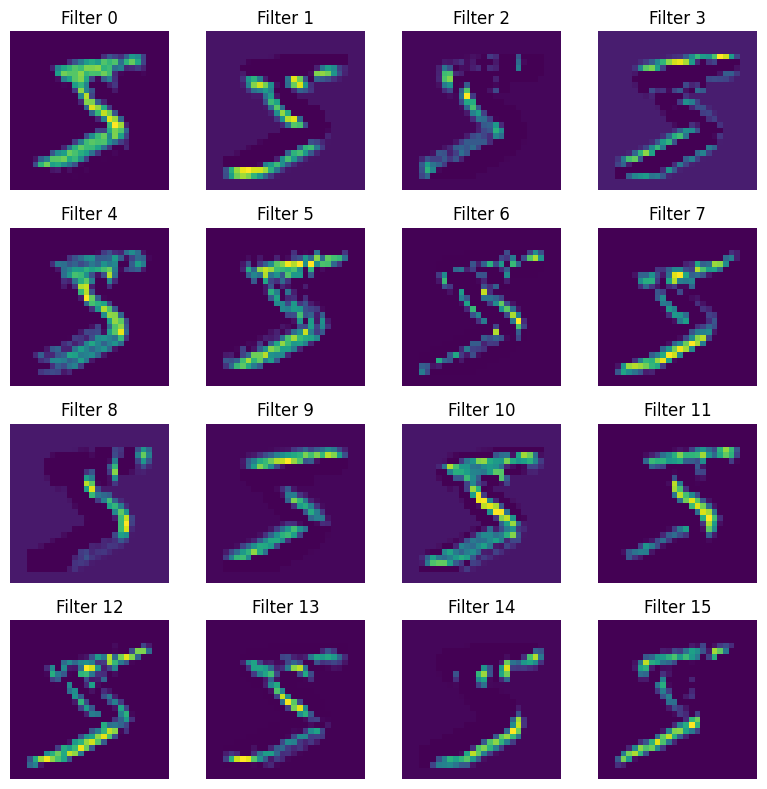

In [20]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[30]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Epoch 99

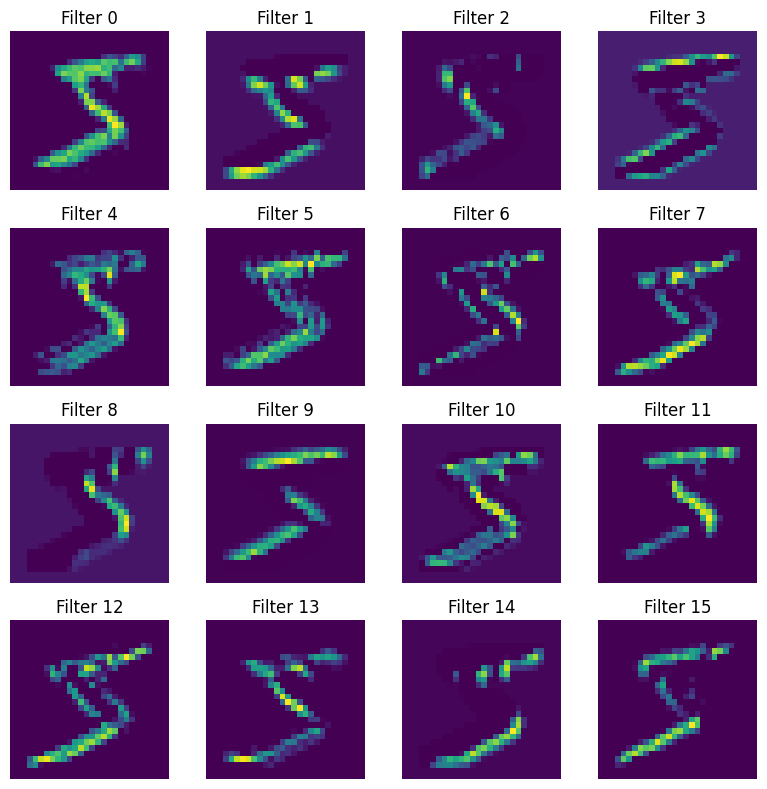

In [21]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Evolution of Kernels' Activations Across Epochs (each row is a kernel)

In [22]:
epochs = [0,1,15,30,45,60,75,90,99]

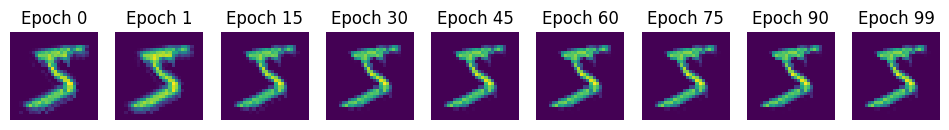

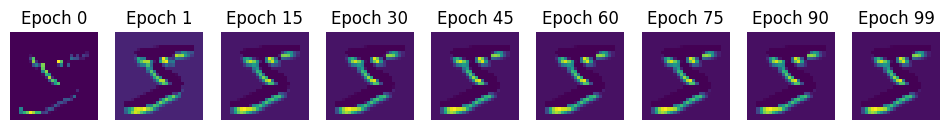

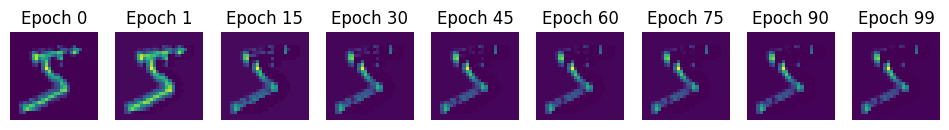

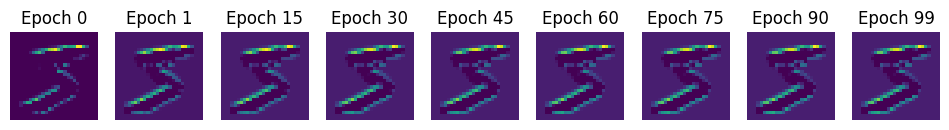

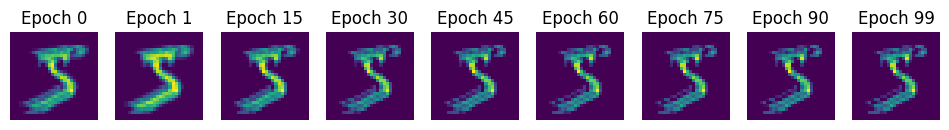

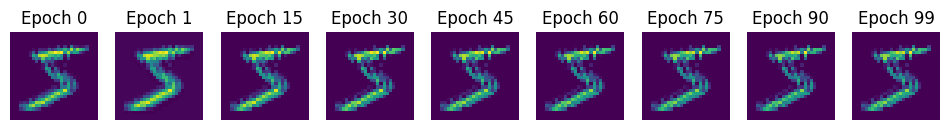

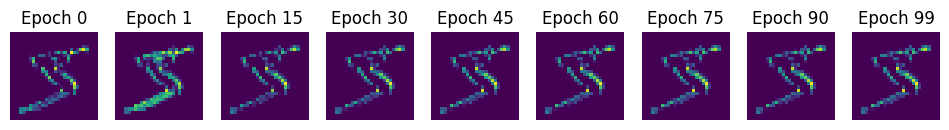

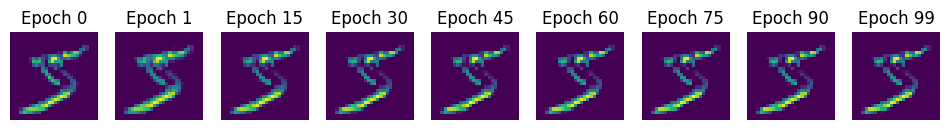

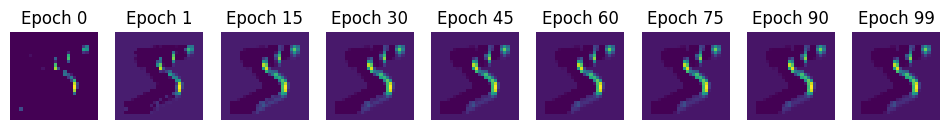

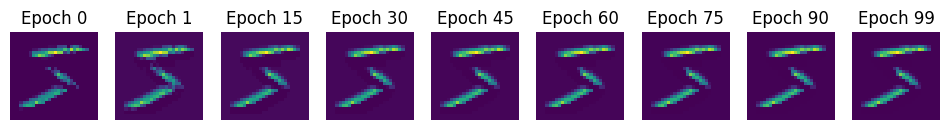

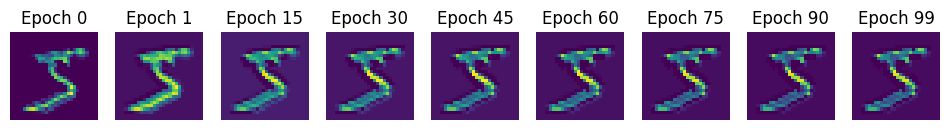

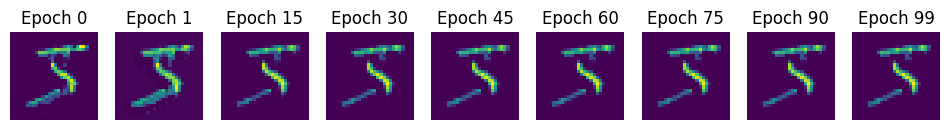

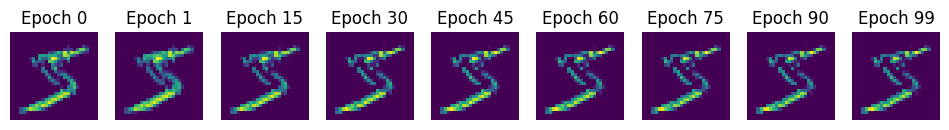

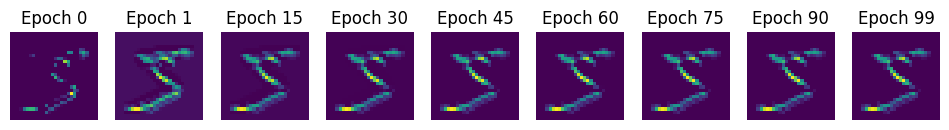

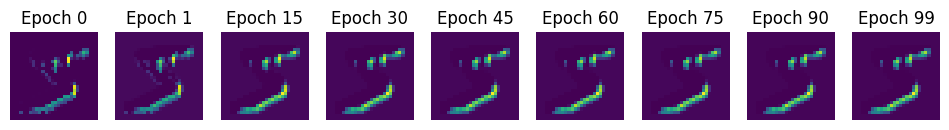

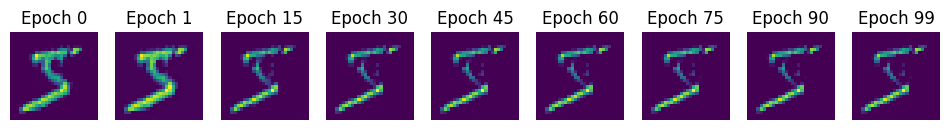

In [23]:
for i in range(16):
    filter_idx = i

    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))


    for ax, epoch in zip(axes, epochs):

        fmap = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(fmap,cmap="viridis")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

# Pooled Features

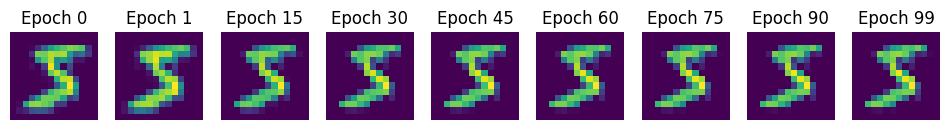

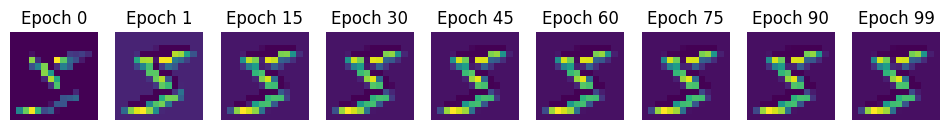

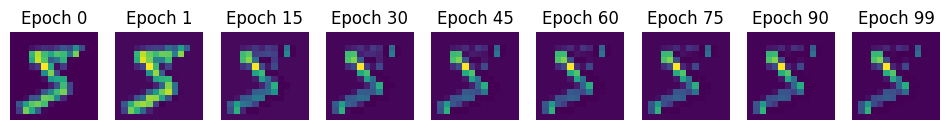

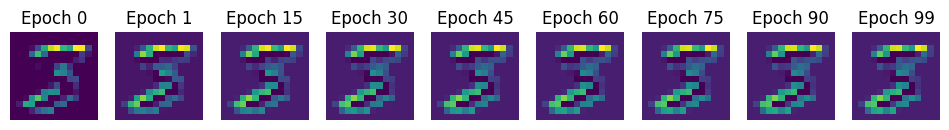

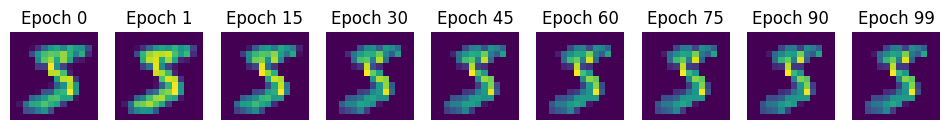

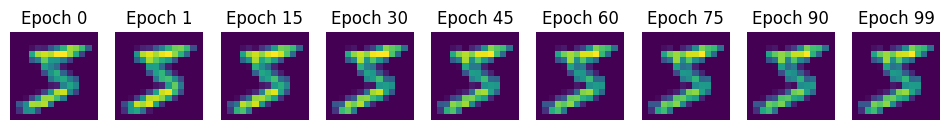

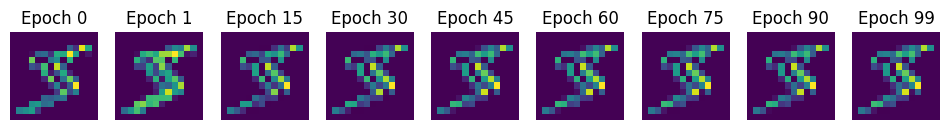

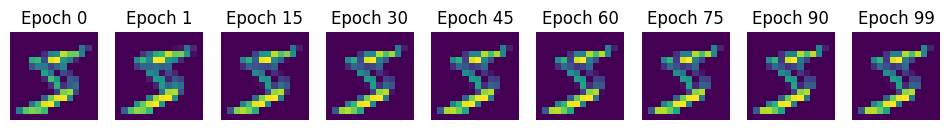

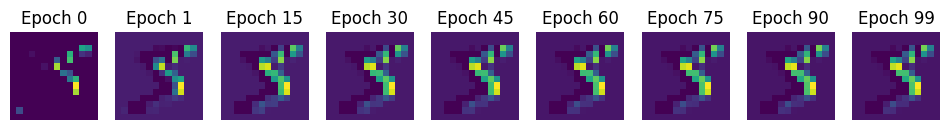

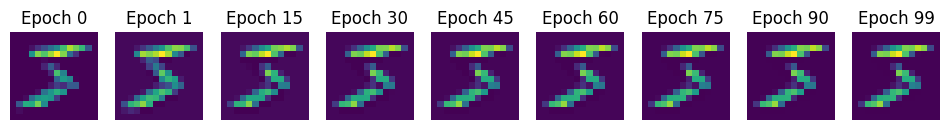

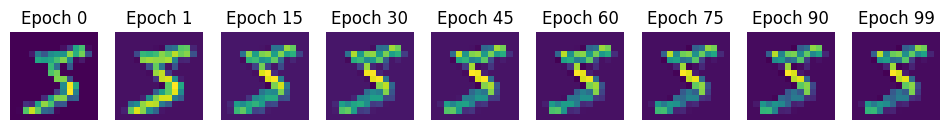

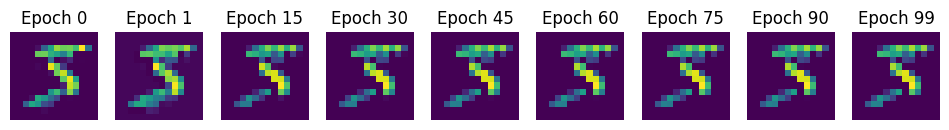

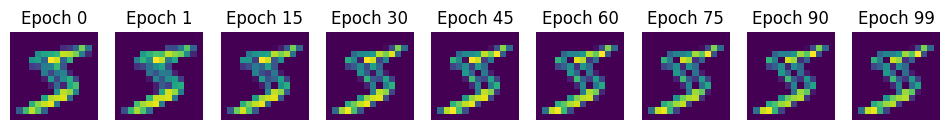

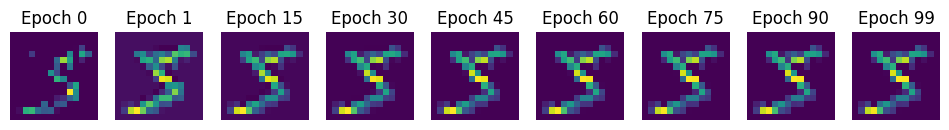

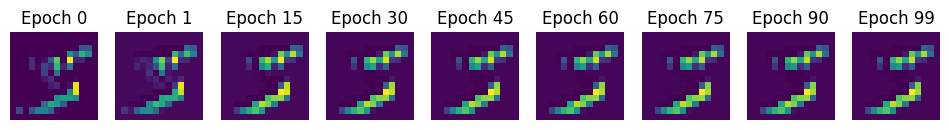

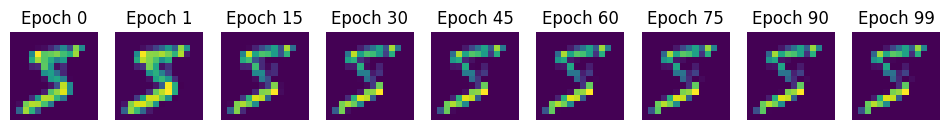

In [24]:
for i in range(16):
    filter_idx = i

    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))


    for ax, epoch in zip(axes, epochs):

        fmap = feature_history[epoch]["pooled_maps"][0,filter_idx]

        ax.imshow(fmap,cmap="viridis")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

### Remarkable difference is observed between the features/ activations of the kernels, even after 1 epoch, especially when compared to the filters as autoencoders model

In [17]:
import torch.nn.functional as F 
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.5488)
tensor(0.9517)


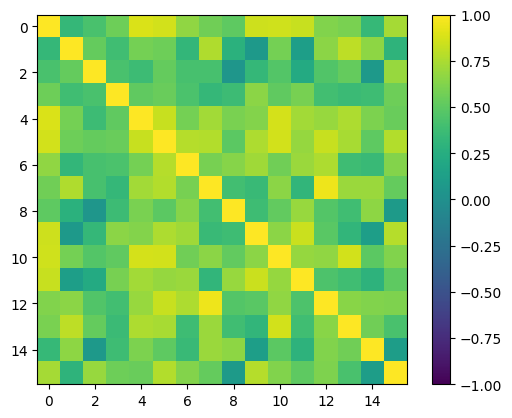

In [27]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# hist to see distribution of activation similarity

Text(0, 0.5, 'Number of filter pairs')

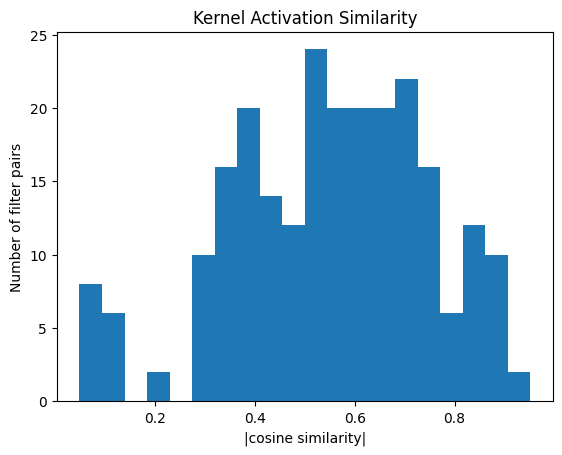

In [18]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Learned kernels...

### Kernels at first forward pass (no optimisation yet performed)

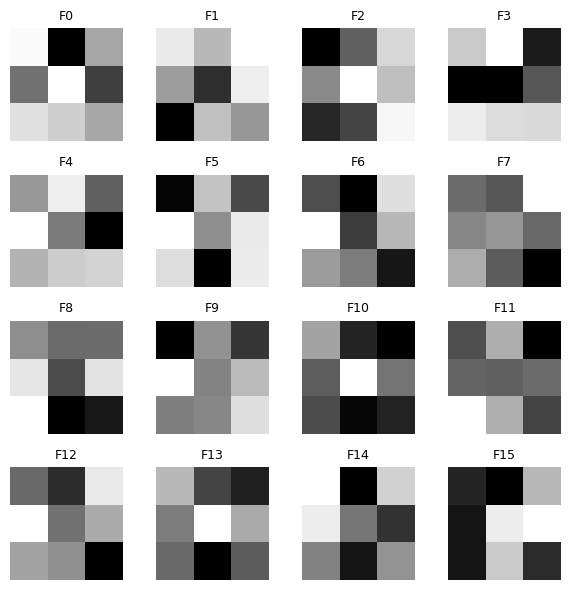

In [28]:

weights = feature_history[0]["kernel_weights"]


fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i, 0]         
    ax.imshow(kernel, cmap="gray")
    ax.set_title(f"F{i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


### kernels at 1 epoch (one full optimisation loop and the subsequent forward activation):

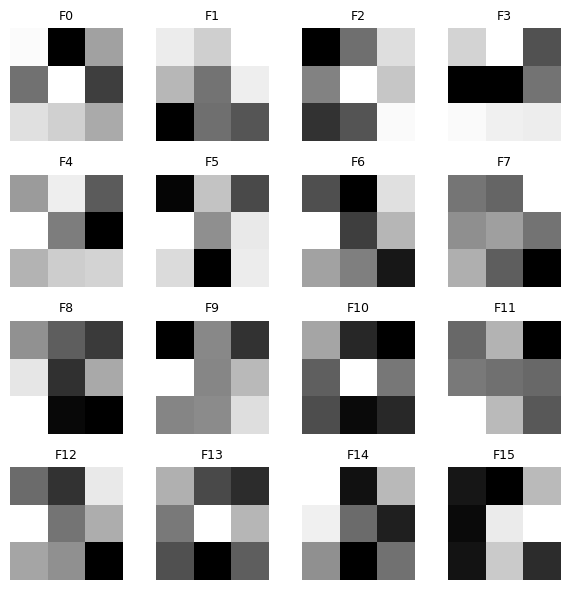

In [29]:

weights = feature_history[1]["kernel_weights"]


fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i, 0]         
    ax.imshow(kernel, cmap="gray")
    ax.set_title(f"F{i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


### kernels at 30 epochs:

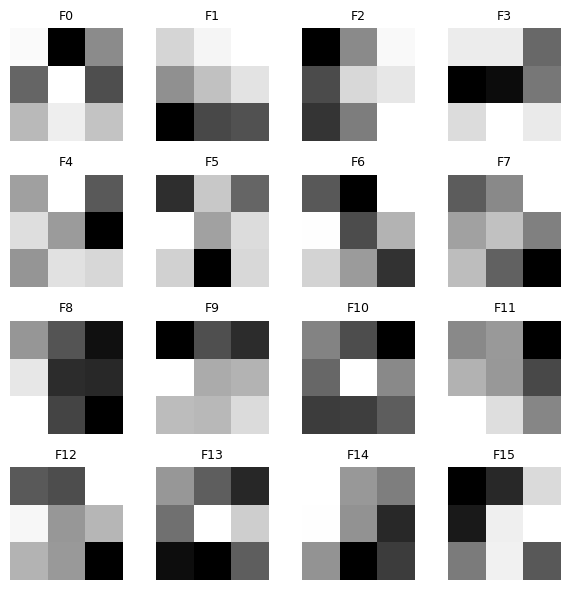

In [30]:
weights = feature_history[30]["kernel_weights"]

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i, 0]      
    ax.imshow(kernel, cmap="gray")
    ax.set_title(f"F{i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

### kernels at 99 epochs:

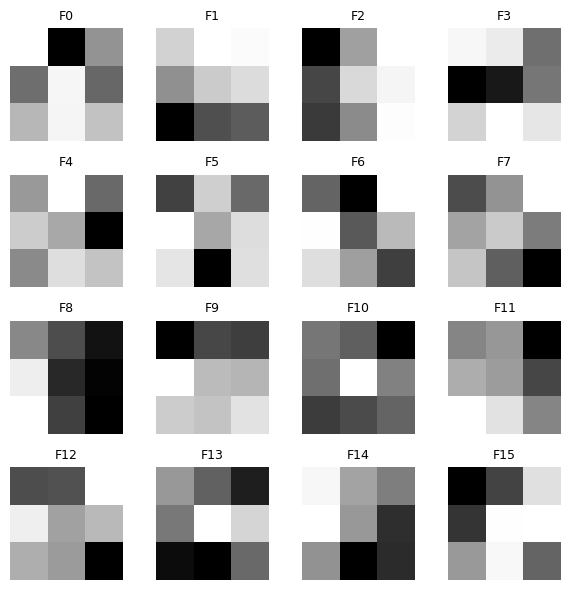

In [31]:
weights = feature_history[99]["kernel_weights"]

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i, 0]  
    ax.imshow(kernel, cmap="gray")
    ax.set_title(f"F{i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

### optimised kernels resemble their initial values, only more specialised- this may be seen more clearly below in the evolution of kernels... The filters as autoencoders model however resembles larger divergence in those kernels learned vs how they were initialised.

# Evolution of kernels through epochs

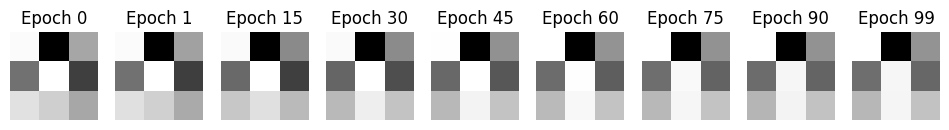

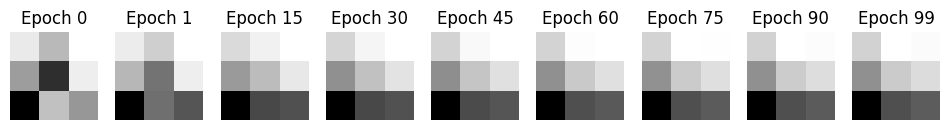

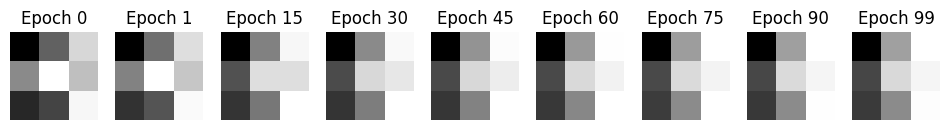

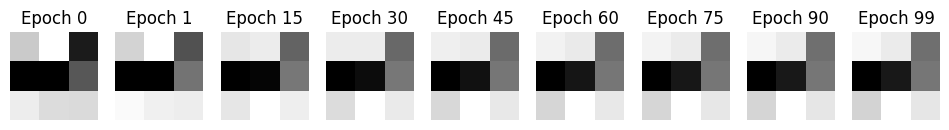

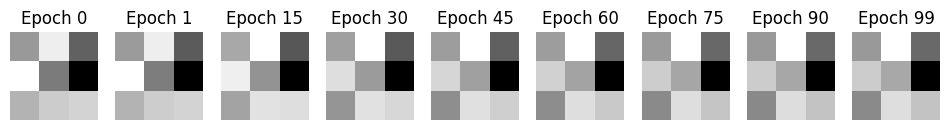

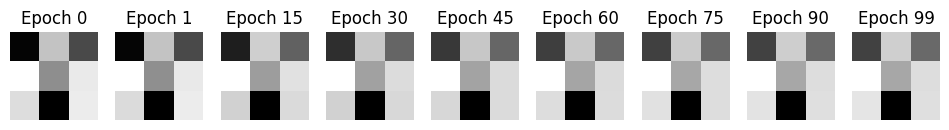

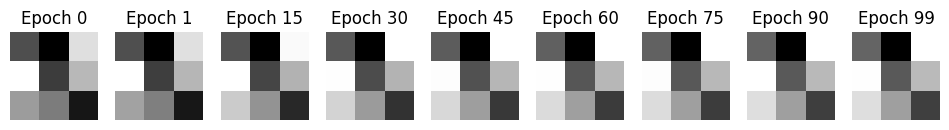

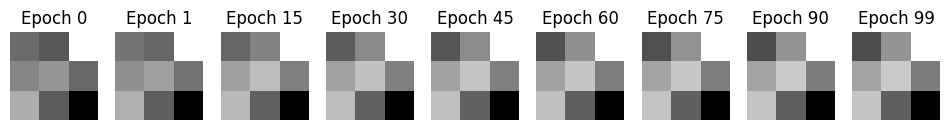

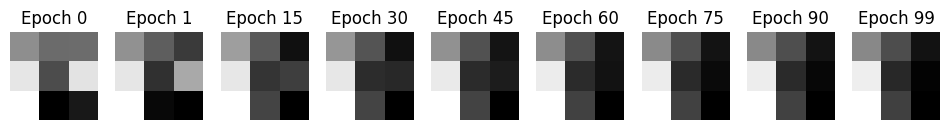

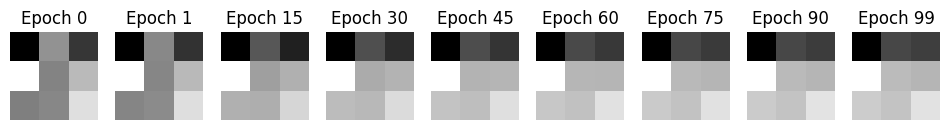

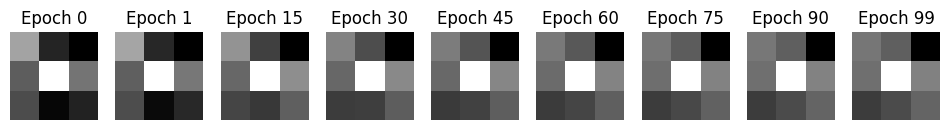

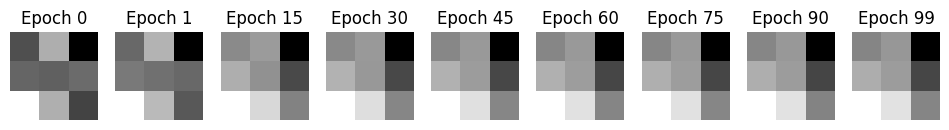

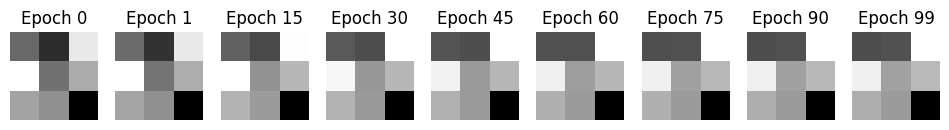

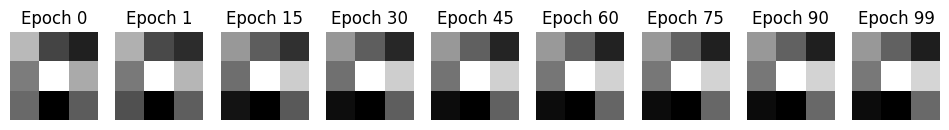

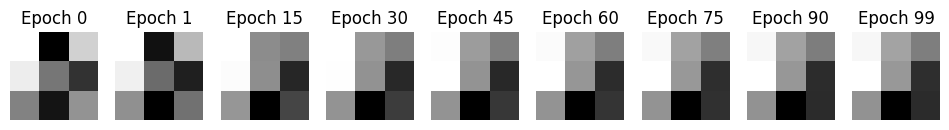

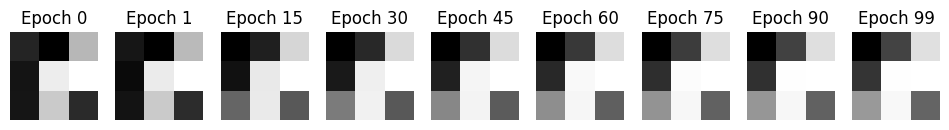

In [32]:
for i in range(16):
    filter_idx = i

    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))

    for ax, epoch in zip(axes, epochs):

        weights = feature_history[epoch]["kernel_weights"][filter_idx,0]

        #kernel = weights[i, 0] 
        
        ax.imshow(weights,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()



### due likely to the global optimisation, filters are distinct from each other even after 1 epoch, thus model capacity is ensured vs the redundancy of filters within the initial filters as autencoders model

In [12]:
conv_weights = model.conv1.weight.flatten(1)

conv_weights = F.normalize(conv_weights, dim=1)

similarity_matrix = conv_weights @ conv_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=conv_weights.device)


mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")


Mean abs filter cosine similarity: 0.2731
Mean filter cosine similarity: -0.0119
Maximum filter similarity: 0.8506
Minimum filter similarity: -0.8002


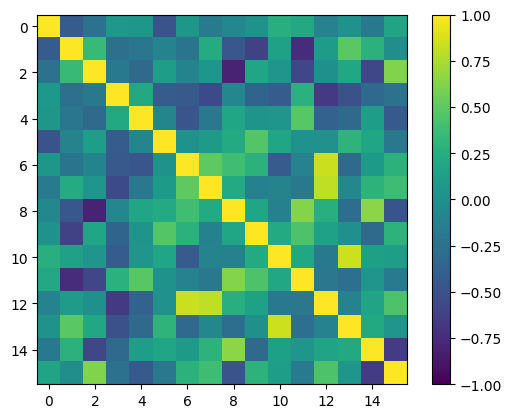

In [35]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# hist to see distribution of kernel similarity

Text(0, 0.5, 'Number of filter pairs')

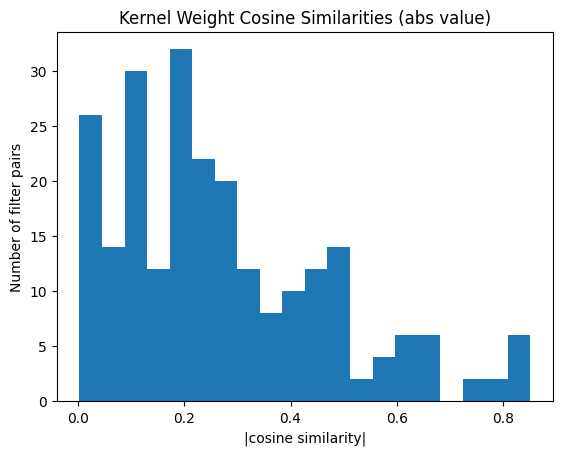

In [16]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Now remove bias and inspect again

In [9]:
all_train_histories = []
all_train_accuracies = []

peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_cnn_get_features(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        bias=False,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Training Loss: 0.4177, Training Accuracy: 88.45
Epoch [2/100], Training Loss: 0.1645, Training Accuracy: 95.44
Epoch [3/100], Training Loss: 0.1160, Training Accuracy: 96.81
Epoch [4/100], Training Loss: 0.0931, Training Accuracy: 97.40
Epoch [5/100], Training Loss: 0.0802, Training Accuracy: 97.78
Epoch [6/100], Training Loss: 0.0706, Training Accuracy: 98.04
Epoch [7/100], Training Loss: 0.0636, Training Accuracy: 98.24
Epoch [8/100], Training Loss: 0.0586, Training Accuracy: 98.37
Epoch [9/100], Training Loss: 0.0539, Training Accuracy: 98.47
Epoch [10/100], Training Loss: 0.0497, Training Accuracy: 98.61
Epoch [11/100], Training Loss: 0.0471, Training Accuracy: 98.66
Epoch [12/100], Training Loss: 0.0432, Training Accuracy: 98.77
Epoch [13/100], Training Loss: 0.0413, Training Accuracy: 98.82
Epoch [14/100], Training Loss: 0.0387, Training Accuracy: 98.90
Epoch [15/100], Training Loss: 0.0365, Training Accuracy: 98.95
Epoch [16/100], Trai

# Loss and Accuracy

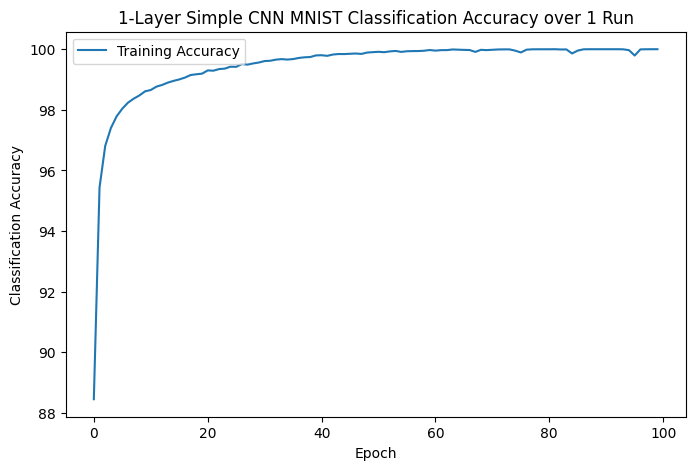

In [10]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")



plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Simple CNN MNIST Classification Accuracy over 1 Run")
plt.show()

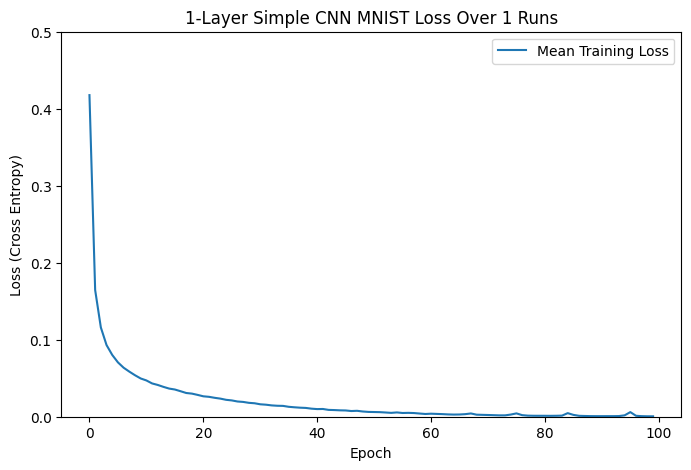

In [11]:
epochs = np.arange(len(training_history["train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_loss"],label="Mean Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer Simple CNN MNIST Loss Over 1 Runs")
plt.show()

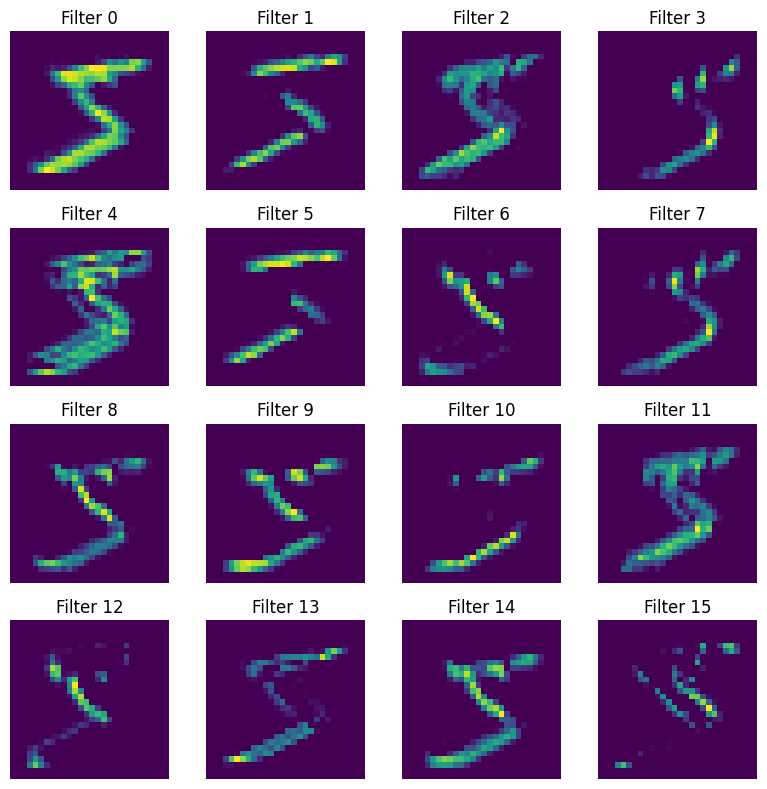

In [12]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
import torch.nn.functional as F 
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.5274)
tensor(0.9796)


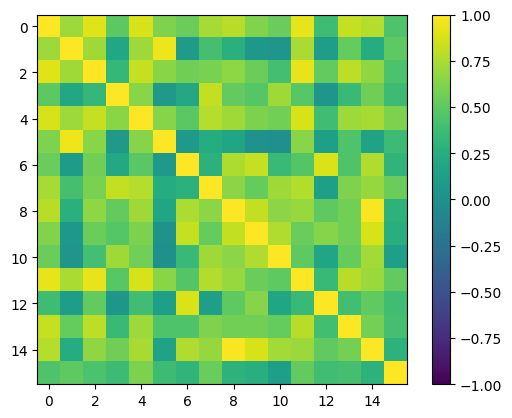

In [14]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

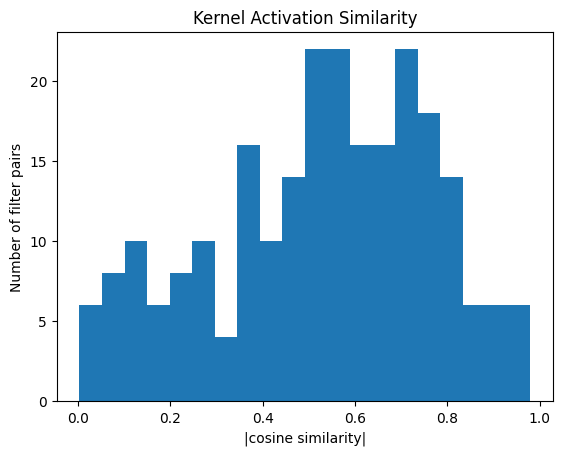

In [15]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

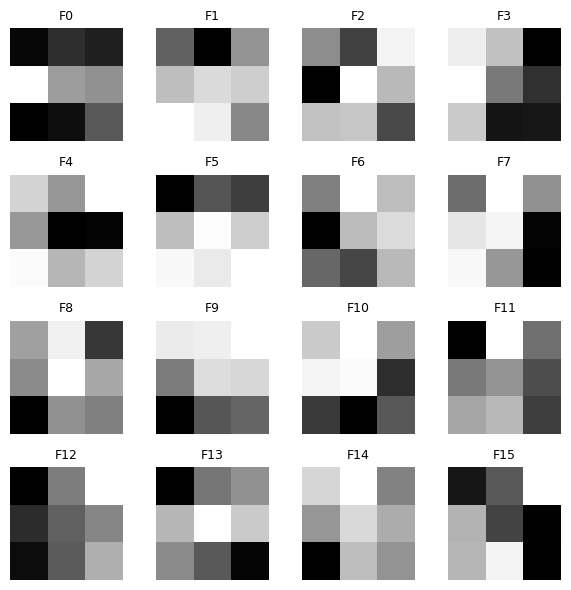

In [16]:
weights = feature_history[99]["kernel_weights"]

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i, 0]  
    ax.imshow(kernel, cmap="gray")
    ax.set_title(f"F{i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
conv_weights = model.conv1.weight.flatten(1)

conv_weights = F.normalize(conv_weights, dim=1)

similarity_matrix = conv_weights @ conv_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=conv_weights.device)


mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")


Mean abs filter cosine similarity: 0.2696
Mean filter cosine similarity: 0.0245
Maximum filter similarity: 0.9098
Minimum filter similarity: -0.7103


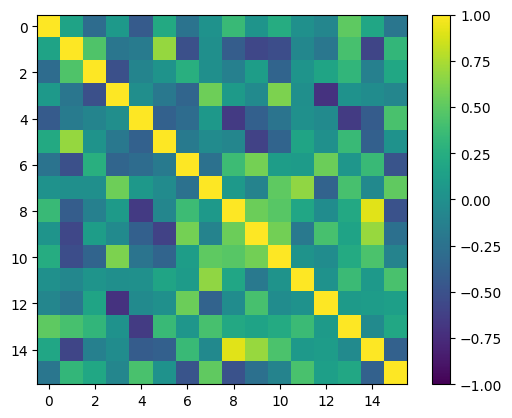

In [18]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

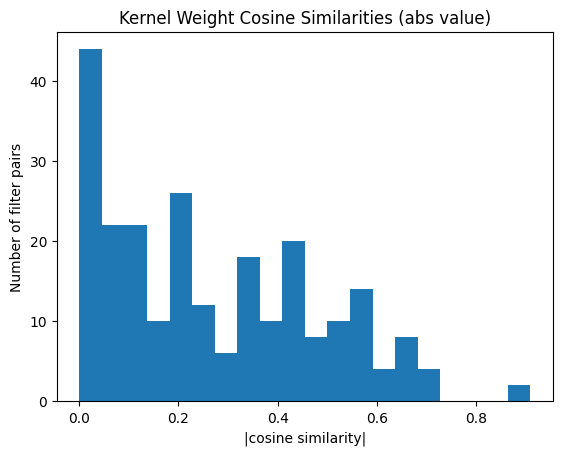

In [19]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Baseline Convolutional Autoencoder For Classification

In [ ]:
#count how many params of the model...



device = torch.device('cuda')

model = conv_autoencoder.CNN_AE(    
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 1, 3, 3) -> 144
encoder.bias         (16,) -> 16
decoder.weight       (16, 1, 3, 3) -> 144
decoder.bias         (1,) -> 1
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31675


In [8]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): # just  run
    #run training and evaluation



    print(f"model run: {seed}")

    if seed == 0 :
        n_epochs=1
    else:
        n_epochs=100


    model, training_history,feature_history, elapsed = cnn_experiments.train_ae_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )

    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])


    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)



model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0709
Epoch [1/1], Training Loss: 0.4409, Training Accuracy: 88.27
peak memory from train : 69.0537109375
memory now reset and is: 17.49609375 MB
time elapsed: 3.041122530999985
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.0938
Epoch [1/100], Training Loss: 0.4160, Training Accuracy: 88.11
Epoch [2/100], Encoder Loss: 0.0026
Epoch [2/100], Training Loss: 0.2165, Training Accuracy: 93.81
Epoch [3/100], Encoder Loss: 0.0011
Epoch [3/100], Training Loss: 0.1895, Training Accuracy: 94.58
Epoch [4/100], Encoder Loss: 0.0008
Epoch [4/100], Training Loss: 0.1783, Training Accuracy: 94.99
Epoch [5/100], Encoder Loss: 0.0006
Epoch [5/100], Training Loss: 0.1684, Training Accuracy: 95.18
Epoch [6/100], Encoder Loss: 0.0005
Epoch [6/100], Training Loss: 0.1585, Training Accuracy: 95.50
Epoch [7/100], Encoder Loss: 0.0005
Epoch [7/100], Training Loss: 0.1523, Training Accuracy: 95.65
Epoch [8/100], Encoder Loss: 0.0005
Epoch [

In [12]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()

In [12]:

epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

In [15]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_epoch_results.csv",
    index=False,
)

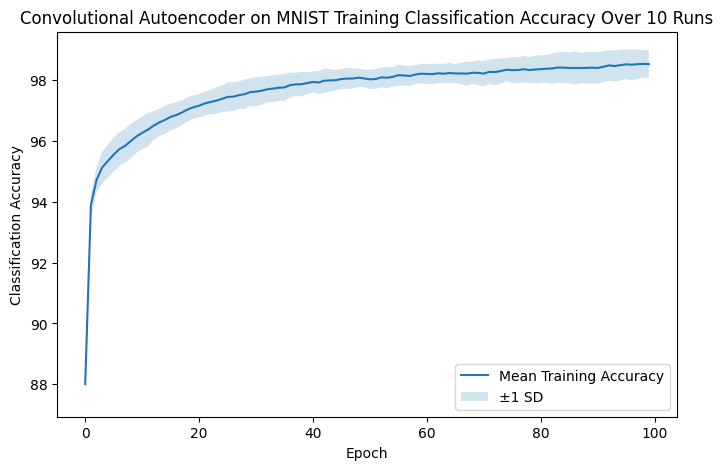

In [17]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

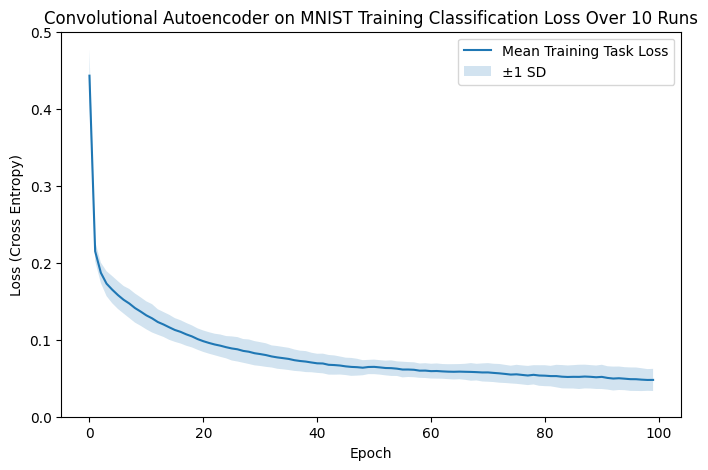

In [19]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Task Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("Convolutional Autoencoder on MNIST Training Classification Loss Over 10 Runs")
plt.show()

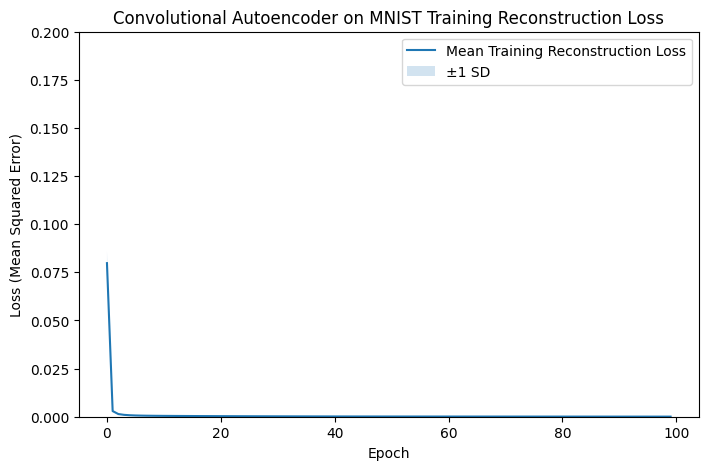

In [22]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Reconstruction Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(0,0.2)
plt.title("Convolutional Autoencoder on MNIST Training Reconstruction Loss")
plt.show()

In [13]:
print(f"Mean training time: {mean_runtime} ")
print(f"All training times:")
print(times) #exluding the first run
print(run_times)

Mean training time: 130.08637691229998 
All training times:
[129.99161257 129.87634723 129.73902979 129.86935286 129.79406884
 130.05460747 129.98862192 130.62885711 130.68642798 130.23484336]
[3.041122530999985, 129.99161256999997, 129.87634723399998, 129.739029791, 129.86935285799996, 129.79406883699994, 130.05460746900008, 129.98862191600006, 130.62885710799992, 130.68642797899997, 130.234843361]


# Test of removing the bias

In [ ]:
#count how many params of the model...



device = torch.device('cuda')

model = conv_autoencoder.CNN_AE(    
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        bias=False,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 1, 3, 3) -> 144
decoder.weight       (16, 1, 3, 3) -> 144
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31658


In [ ]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): 
    #run training and evaluation



    print(f"model run: {seed}")

    if seed == 0 :
        n_epochs=1
    else:
        n_epochs=100


    model, training_history,feature_history, elapsed = cnn_experiments.train_ae_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])


    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.1780
Epoch [1/1], Training Loss: 0.4295, Training Accuracy: 88.35
peak memory from train : 69.17236328125
memory now reset and is: 17.49462890625 MB
time elapsed: 2.8854495749999955
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.1885
Epoch [1/100], Training Loss: 0.4076, Training Accuracy: 88.01
Epoch [2/100], Encoder Loss: 0.1592
Epoch [2/100], Training Loss: 0.1982, Training Accuracy: 94.37
Epoch [3/100], Encoder Loss: 0.1535
Epoch [3/100], Training Loss: 0.1592, Training Accuracy: 95.42
Epoch [4/100], Encoder Loss: 0.1512
Epoch [4/100], Training Loss: 0.1352, Training Accuracy: 96.16
Epoch [5/100], Encoder Loss: 0.1499
Epoch [5/100], Training Loss: 0.1234, Training Accuracy: 96.45
Epoch [6/100], Encoder Loss: 0.1489
Epoch [6/100], Training Loss: 0.1149, Training Accuracy: 96.64
Epoch [7/100], Encoder Loss: 0.1480
Epoch [7/100], Training Loss: 0.1073, Training Accuracy: 96.88
Epoch [8/100], Encoder Loss: 0.1474
Ep

In [11]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()



In [12]:

epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

In [14]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_no_bias_epoch_results.csv",
    index=False,
)

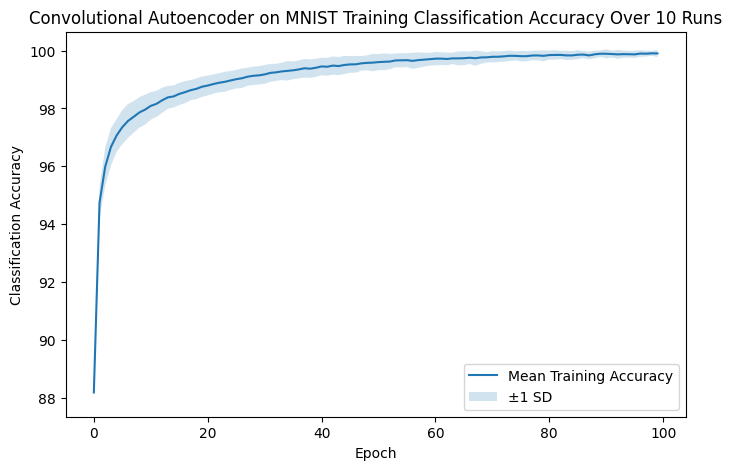

In [15]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

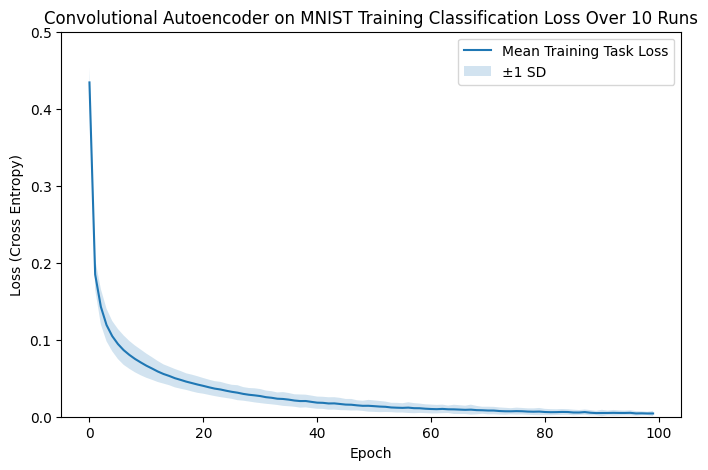

In [16]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Task Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("Convolutional Autoencoder on MNIST Training Classification Loss Over 10 Runs")
plt.show()

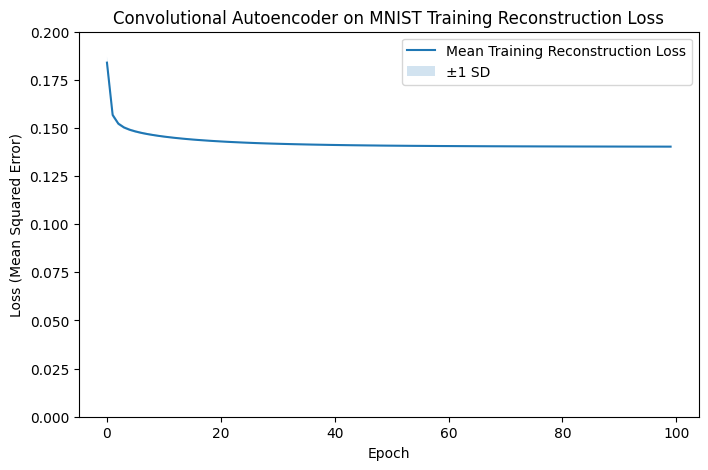

In [17]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Reconstruction Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(0,0.2)
plt.title("Convolutional Autoencoder on MNIST Training Reconstruction Loss")
plt.show()

# Now weight tying (with a bias term)

In [ ]:
#count how many params of the model...


device = torch.device('cpu')

model = weight_tied_conv_autoencoder.CNN_AE(
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        pool_padding=0,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        bias=True,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

decoder_bias         (1,) -> 1
encoder.weight       (16, 1, 3, 3) -> 144
encoder.bias         (16,) -> 16
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31531


In [ ]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): 
    #run training and evaluation


    print(f"model run: {seed}")

    if seed == 0 :
        n_epochs=1
    else:
        n_epochs=100


    model, training_history, elapsed = cnn_experiments.train_ae_cnn_weight_tied(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=True,
        seed=seed 
    )

    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])


    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0573
Epoch [1/1], Training Loss: 0.5201, Training Accuracy: 87.66
peak memory from train : 69.05078125
memory now reset and is: 17.494140625 MB
time elapsed: 2.8088570989999653
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.0979
Epoch [1/100], Training Loss: 0.4773, Training Accuracy: 87.71
Epoch [2/100], Encoder Loss: 0.0056
Epoch [2/100], Training Loss: 0.2566, Training Accuracy: 93.74
Epoch [3/100], Encoder Loss: 0.0034
Epoch [3/100], Training Loss: 0.2046, Training Accuracy: 94.80
Epoch [4/100], Encoder Loss: 0.0026
Epoch [4/100], Training Loss: 0.1802, Training Accuracy: 95.28
Epoch [5/100], Encoder Loss: 0.0021
Epoch [5/100], Training Loss: 0.1674, Training Accuracy: 95.63
Epoch [6/100], Encoder Loss: 0.0017
Epoch [6/100], Training Loss: 0.1597, Training Accuracy: 95.77
Epoch [7/100], Encoder Loss: 0.0014
Epoch [7/100], Training Loss: 0.1561, Training Accuracy: 95.87
Epoch [8/100], Encoder Loss: 0.0011
Epoch [

In [9]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()



In [12]:

epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

In [13]:
epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_weight_tied_epoch_results.csv",
    index=False,
)

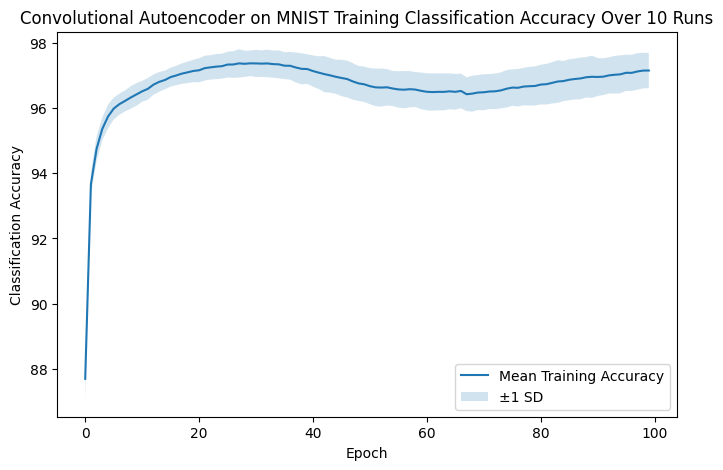

In [14]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

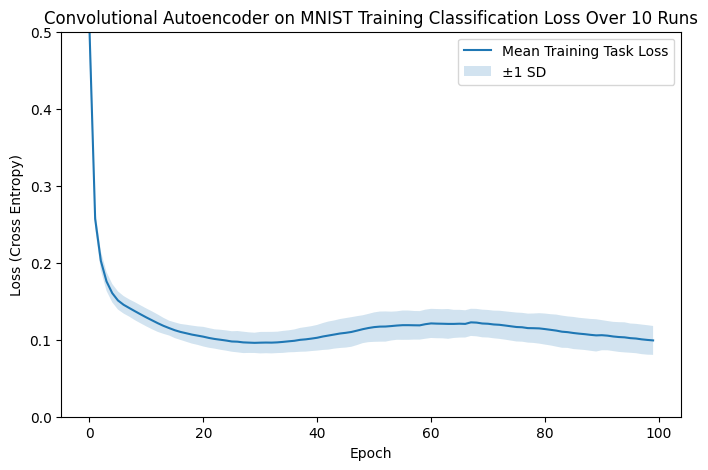

In [15]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Task Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("Convolutional Autoencoder on MNIST Training Classification Loss Over 10 Runs")
plt.show()

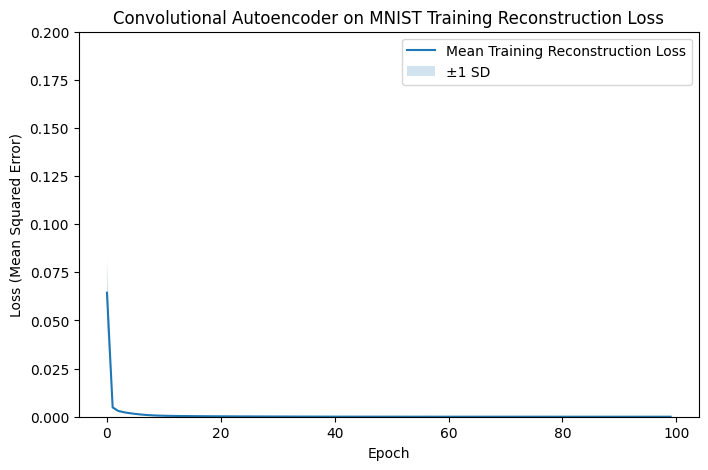

In [16]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Reconstruction Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(0,0.2)
plt.title("Convolutional Autoencoder on MNIST Training Reconstruction Loss")
plt.show()

# Now weight tying without a bias

In [ ]:
#count how many params of the model...



device = torch.device('cpu')

model = weight_tied_conv_autoencoder.CNN_AE(
        input_dims=28,
        in_channels=1,
        pool_kernel_size=2,
        pool_stride=2,
        pool_padding=0,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        bias=False,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 1, 3, 3) -> 144
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31514


In [ ]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): 
    #run training and evaluation


    print(f"model run: {seed}")

    if seed == 0 :
        n_epochs=1
    else:
        n_epochs=100


    model, training_history, elapsed = cnn_experiments.train_ae_cnn_weight_tied(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])


    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.1755
Epoch [1/1], Training Loss: 0.4588, Training Accuracy: 88.53
peak memory from train : 69.04736328125
memory now reset and is: 17.4921875 MB
time elapsed: 1.882465449999927
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.2174
Epoch [1/100], Training Loss: 0.4068, Training Accuracy: 88.59
Epoch [2/100], Encoder Loss: 0.1626
Epoch [2/100], Training Loss: 0.1836, Training Accuracy: 95.21
Epoch [3/100], Encoder Loss: 0.1557
Epoch [3/100], Training Loss: 0.1369, Training Accuracy: 96.55
Epoch [4/100], Encoder Loss: 0.1530
Epoch [4/100], Training Loss: 0.1168, Training Accuracy: 97.12
Epoch [5/100], Encoder Loss: 0.1516
Epoch [5/100], Training Loss: 0.1034, Training Accuracy: 97.42
Epoch [6/100], Encoder Loss: 0.1506
Epoch [6/100], Training Loss: 0.0928, Training Accuracy: 97.68
Epoch [7/100], Encoder Loss: 0.1499
Epoch [7/100], Training Loss: 0.0854, Training Accuracy: 97.79
Epoch [8/100], Encoder Loss: 0.1493
Epoch [

In [8]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()



In [10]:

epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_weight_tied_no_bias_epoch_results.csv",
    index=False,
)

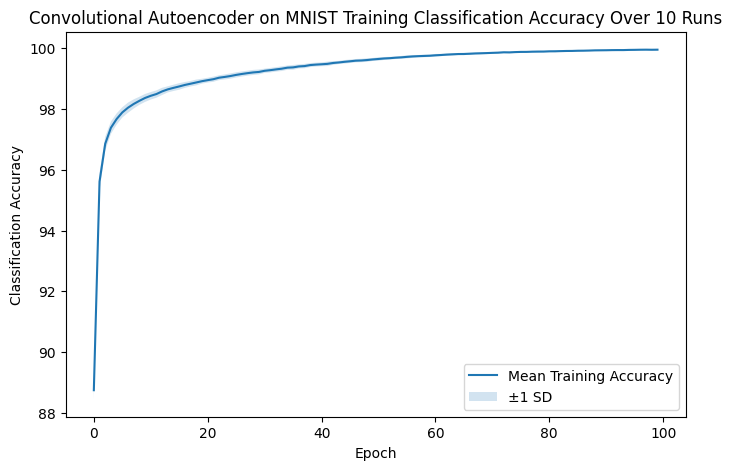

In [11]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

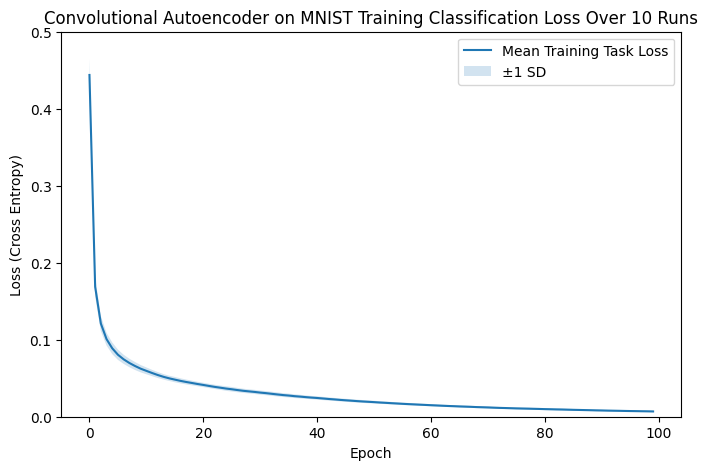

In [12]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Task Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("Convolutional Autoencoder on MNIST Training Classification Loss Over 10 Runs")
plt.show()

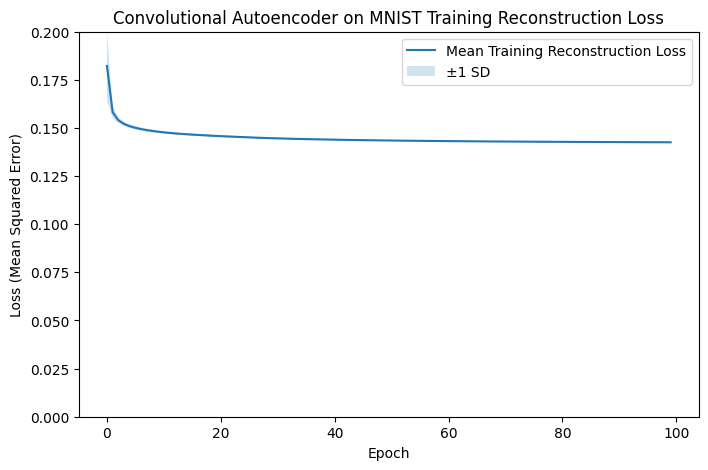

In [13]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Reconstruction Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(0,0.2)
plt.title("Convolutional Autoencoder on MNIST Training Reconstruction Loss")
plt.show()

# Comparing Results

In [10]:
initial_bias_results = pd.read_csv("/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_epoch_results.csv")

In [15]:
no_bias_results = pd.read_csv("/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_no_bias_epoch_results.csv")

In [43]:
initial_bias_weight_tie_results = pd.read_csv("/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_weight_tied_epoch_results.csv")

In [12]:
no_bias_weight_tie_results = pd.read_csv("/content/drive/MyDrive/research_jobs/standard_autoencoder_cnn_weight_tied_no_bias_epoch_results.csv")

### initial model:

In [31]:
print(f"Initial Max accuracy: {initial_bias_results["mean_accuracy"].max()}")
print(f"Initial Max accuracy std: {initial_bias_results["std_accuracy"].max()}")

print(f"Initial Min Loss: {initial_bias_results["task_mean_loss"].min()}")
print(f"Initial Max Loss std: {initial_bias_results["task_std_loss"].max()}")

print(f"Initial Min Encoder Loss: {initial_bias_results["encoder_mean_loss"].min()} (to 10 dp: {initial_bias_results["encoder_mean_loss"].min():.10f})")
print(f"Initial Max Encoder Loss std: {initial_bias_results["encoder_std_loss"].min()} (to 10 dp: {initial_bias_results["encoder_std_loss"].min():.10f})")

Initial Max accuracy: 98.529
Initial Max accuracy std: 0.5656364163979858
Initial Min Loss: 0.0477498140479338
Initial Max Loss std: 0.0345446954229238
Initial Min Encoder Loss: 5.1823183288085625e-05 (to 10 dp: 0.0000518232)
Initial Max Encoder Loss std: 9.321305585372935e-06 (to 10 dp: 0.0000093213)


### removing the encoder/decoder biases:

In [33]:
print(f"No Bias Max accuracy: {no_bias_results["mean_accuracy"].max()}")
print(f"No Bias Max accuracy std: {no_bias_results["std_accuracy"].max()}")

print(f"No Bias Min Loss: {no_bias_results["task_mean_loss"].min()}")
print(f"No Bias Max Loss std: {no_bias_results["task_std_loss"].max()}")

print(f"No Bias Min Encoder Loss: {no_bias_results["encoder_mean_loss"].min()} (to 10 dp: {no_bias_results["encoder_mean_loss"].min():.10f})")
print(f"No Bias Max Encoder Loss std: {no_bias_results["encoder_std_loss"].min()} (to 10 dp: {no_bias_results["encoder_std_loss"].min():.10f})")

No Bias Max accuracy: 99.905
No Bias Max accuracy std: 0.6666849997479248
No Bias Min Loss: 0.0041994168640961
No Bias Max Loss std: 0.0229305346223378
No Bias Min Encoder Loss: 0.1403040780539208 (to 10 dp: 0.1403040781)
No Bias Max Encoder Loss std: 3.954405997681477e-05 (to 10 dp: 0.0000395441)


### Initial model (with bias) weight tying:

In [45]:
print(f"Initial With Weight Tie Max accuracy: {initial_bias_weight_tie_results["mean_accuracy"].max()}")
print(f"Initial With Weight Tie Max accuracy std: {initial_bias_weight_tie_results["std_accuracy"].max()}")

print(f"Initial With Weight Tie Min Loss: {initial_bias_weight_tie_results["task_mean_loss"].min()}")
print(f"Initial With Weight Tie Max Loss std: {initial_bias_weight_tie_results["task_std_loss"].max()}")

print(f"Initial With Weight Tie Min Encoder Loss: {initial_bias_weight_tie_results["encoder_mean_loss"].min()} (to 10 dp: {initial_bias_weight_tie_results["encoder_mean_loss"].min():.10f})")
print(f"Initial With Weight Tie Max Encoder Loss std: {initial_bias_weight_tie_results["encoder_std_loss"].min()} (to 10 dp: {initial_bias_weight_tie_results["encoder_std_loss"].min():.10f})")

Initial With Weight Tie Max accuracy: 97.371
Initial With Weight Tie Max accuracy std: 0.6548425595345632
Initial With Weight Tie Min Loss: 0.0959494285015983
Initial With Weight Tie Max Loss std: 0.0354044924695682
Initial With Weight Tie Min Encoder Loss: 8.015052414685534e-06 (to 10 dp: 0.0000080151)
Initial With Weight Tie Max Encoder Loss std: 3.6139433521011264e-06 (to 10 dp: 0.0000036139)


### removing the encoder/decoder biases and weight tying:

In [34]:
print(f"No Bias & Weight Tie Max accuracy: {no_bias_weight_tie_results["mean_accuracy"].max()}")
print(f"No Bias & Weight Tie Max accuracy std: {no_bias_weight_tie_results["std_accuracy"].max()}")

print(f"No Bias & Weight Tie Min Loss: {no_bias_weight_tie_results["task_mean_loss"].min()}")
print(f"No Bias & Weight Tie Max Loss std: {no_bias_weight_tie_results["task_std_loss"].max()}")

print(f"No Bias & Weight Tie Min Encoder Loss: {no_bias_weight_tie_results["encoder_mean_loss"].min()} (to 10 dp: {no_bias_weight_tie_results["encoder_mean_loss"].min():.10f})")
print(f"No Bias & Weight Tie Max Encoder Loss std: {no_bias_weight_tie_results["encoder_std_loss"].min()} (to 10 dp: {no_bias_weight_tie_results["encoder_std_loss"].min():.10f})")

No Bias & Weight Tie Max accuracy: 99.95266666666669
No Bias & Weight Tie Max accuracy std: 0.2962829447223252
No Bias & Weight Tie Min Loss: 0.006848982908327
No Bias & Weight Tie Max Loss std: 0.0215462525352457
No Bias & Weight Tie Min Encoder Loss: 0.1425639138196376 (to 10 dp: 0.1425639138)
No Bias & Weight Tie Max Encoder Loss std: 0.0001625525736483 (to 10 dp: 0.0001625526)


# Now inspecting the features learnt (how do our attempts at regularisation allow for more performant classification)

## Extract features from the baseline model:

In [20]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_ae_cnn_get_features(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Loss: 0.0709
Epoch [1/100], Training Loss: 0.4409, Training Accuracy: 88.27
Epoch [2/100], Encoder Loss: 0.0023
Epoch [2/100], Training Loss: 0.2037, Training Accuracy: 94.28
Epoch [3/100], Encoder Loss: 0.0013
Epoch [3/100], Training Loss: 0.1745, Training Accuracy: 95.12
Epoch [4/100], Encoder Loss: 0.0009
Epoch [4/100], Training Loss: 0.1633, Training Accuracy: 95.48
Epoch [5/100], Encoder Loss: 0.0007
Epoch [5/100], Training Loss: 0.1573, Training Accuracy: 95.64
Epoch [6/100], Encoder Loss: 0.0006
Epoch [6/100], Training Loss: 0.1490, Training Accuracy: 95.83
Epoch [7/100], Encoder Loss: 0.0005
Epoch [7/100], Training Loss: 0.1405, Training Accuracy: 96.11
Epoch [8/100], Encoder Loss: 0.0005
Epoch [8/100], Training Loss: 0.1322, Training Accuracy: 96.44
Epoch [9/100], Encoder Loss: 0.0005
Epoch [9/100], Training Loss: 0.1278, Training Accuracy: 96.47
Epoch [10/100], Encoder Loss: 0.0004
Epoch [10/100], Training Loss: 0.1236, Trai

In [11]:
# accuracy
accuracy= np.array(all_train_accuracies[0])

# task loss
task_loss = np.array(all_train_histories[0])

# encoder loss
encoder_loss = np.array(all_encoder_histories[0])

#peak memory
relevant_peak_mems = np.array(peak_memory[0]) 
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[0:])

In [12]:
epochs = np.arange(1, len(task_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_loss": task_loss,
    "accuracy": accuracy,

    "encoder_loss": encoder_loss,

})


In [15]:
#save the features history 
features_df= pd.DataFrame(feature_history)

features_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_autoencoder_features.csv",
    index=False,
)

# Brief validation of accuracy (just so we know our seed and training is consistent)

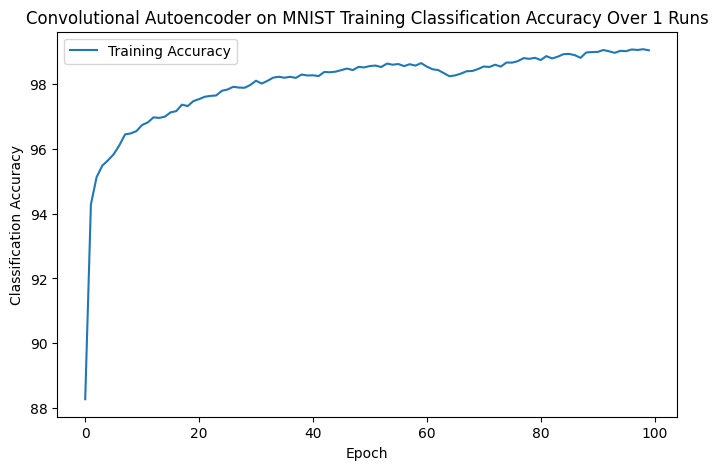

In [16]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Classification Accuracy Over 1 Runs")
plt.show()

# Final filters

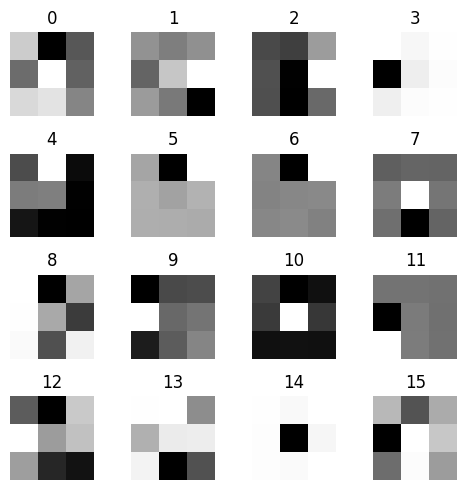

In [23]:
weights = feature_history[99]["encoder_weights"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[i,0], cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

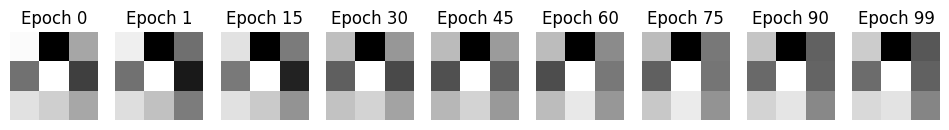

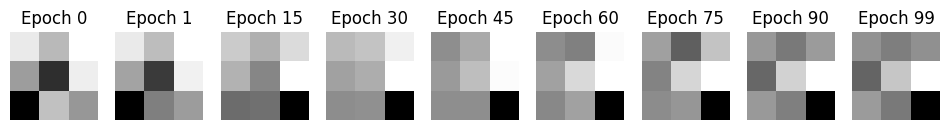

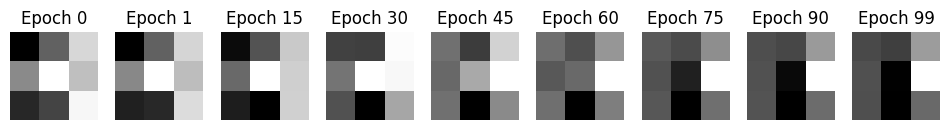

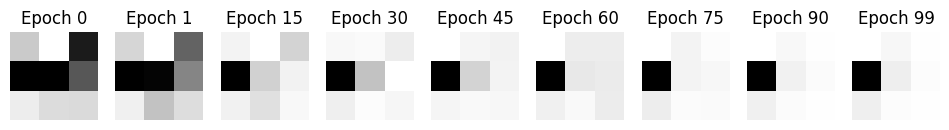

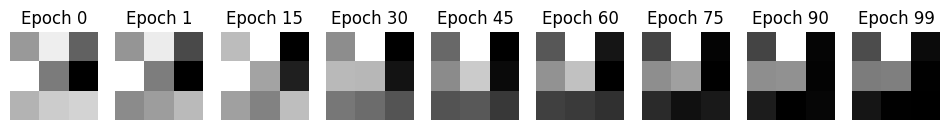

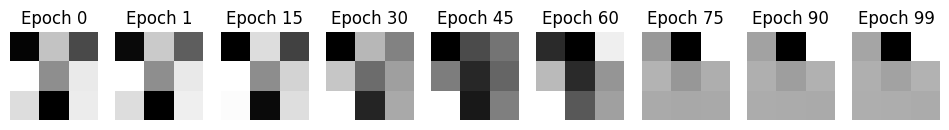

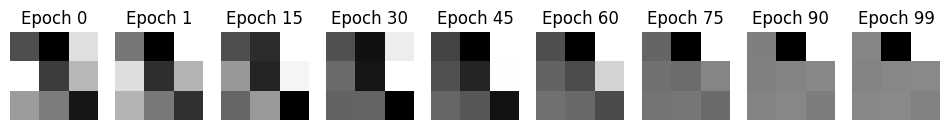

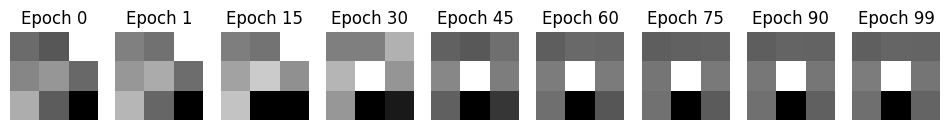

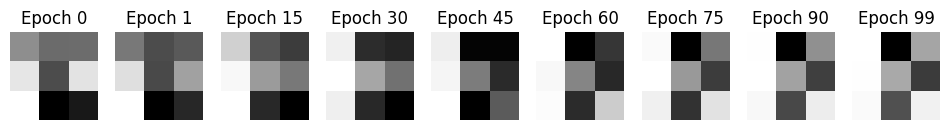

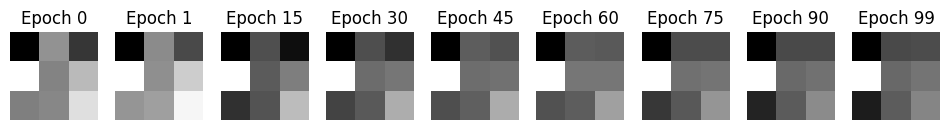

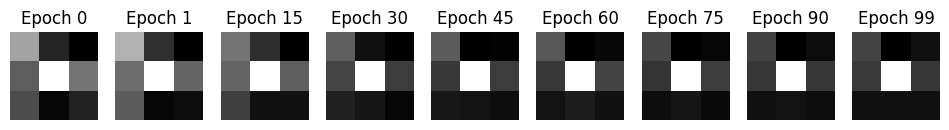

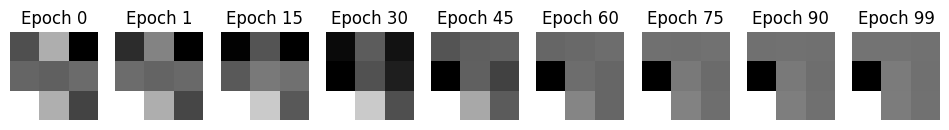

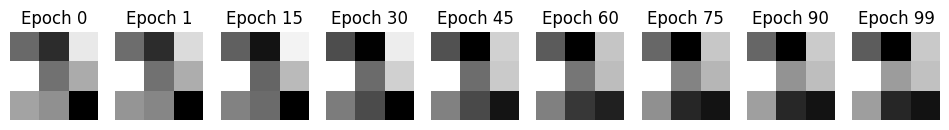

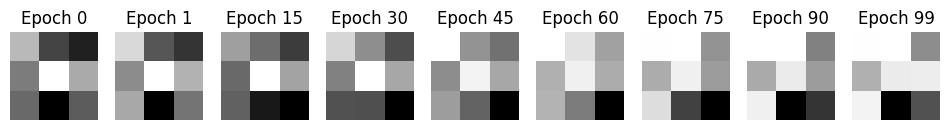

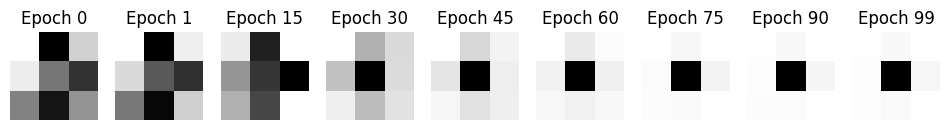

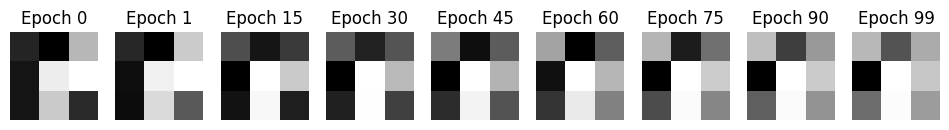

In [24]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        kernel = feature_history[epoch]["encoder_weights"][filter_idx,0]

        ax.imshow(kernel,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [21]:

encoder_weights = model.encoder.weight.flatten(1)

encoder_weights = F.normalize(encoder_weights, dim=1)

similarity_matrix = encoder_weights @ encoder_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=encoder_weights.device)

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.2659
Mean filter cosine similarity: 0.0244
Maximum filter similarity: 0.9541
Minimum filter similarity: -0.9570


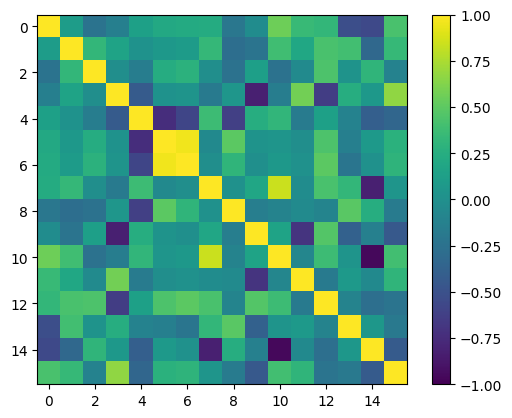

In [47]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# hist of kernel weight similarities

Text(0, 0.5, 'Number of filter pairs')

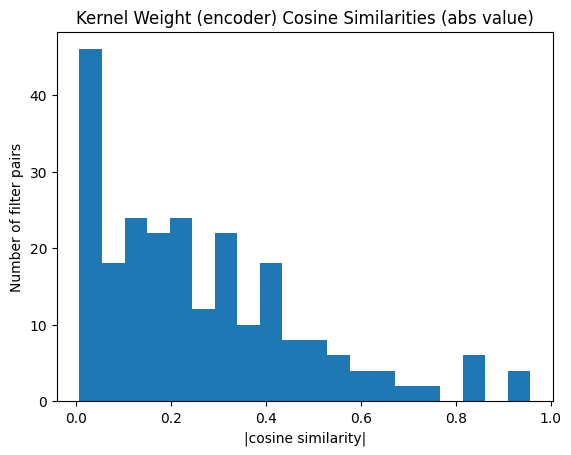

In [23]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight (encoder) Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Feature maps

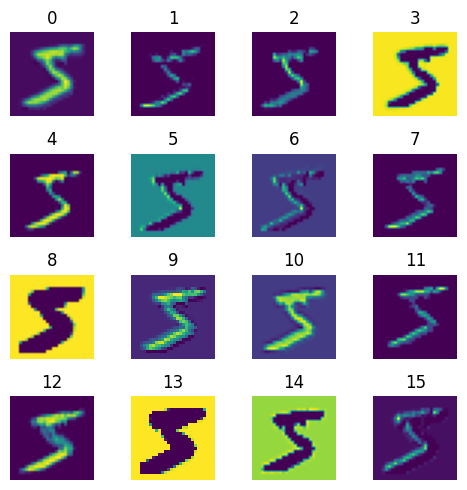

In [39]:
weights = feature_history[99]["maps"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[0,i], cmap="viridis")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Pooled:

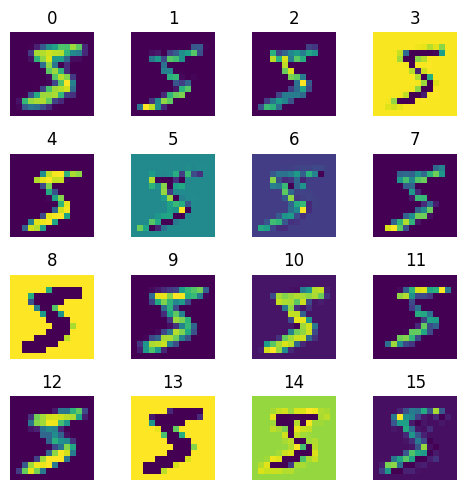

In [41]:
weights = feature_history[99]["pooled_maps"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[0,i], cmap="viridis")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

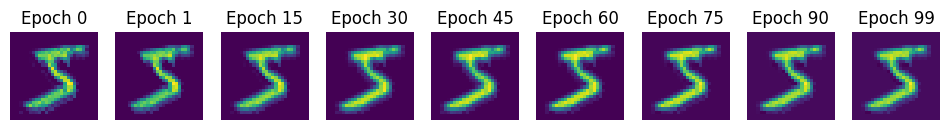

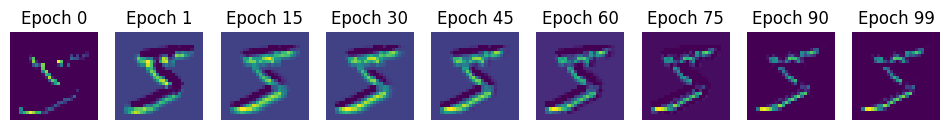

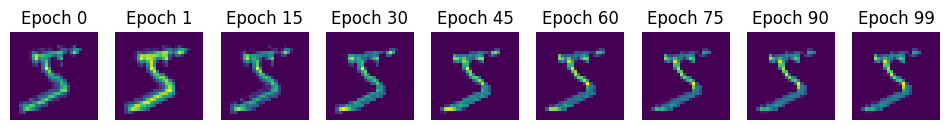

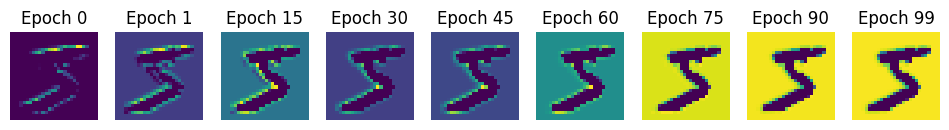

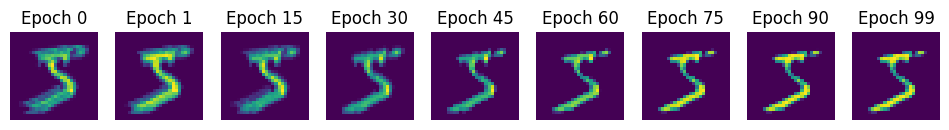

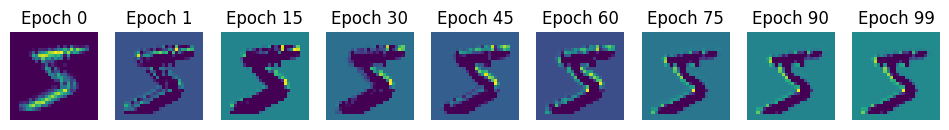

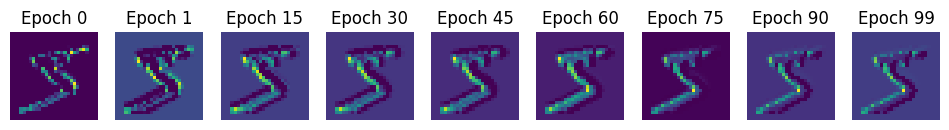

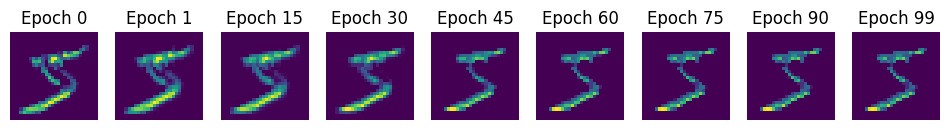

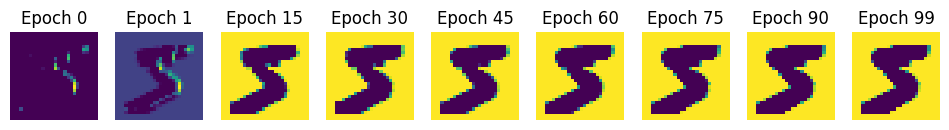

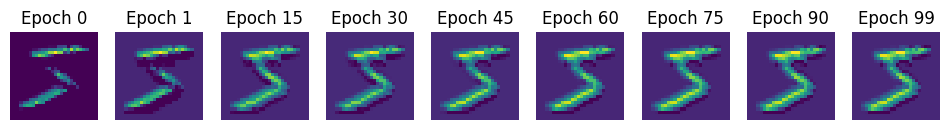

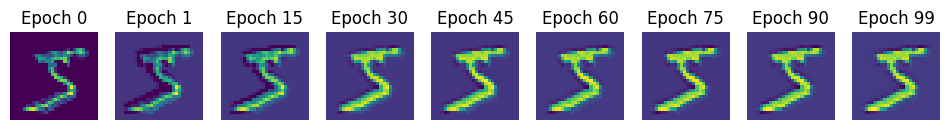

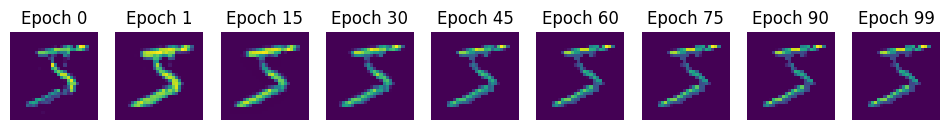

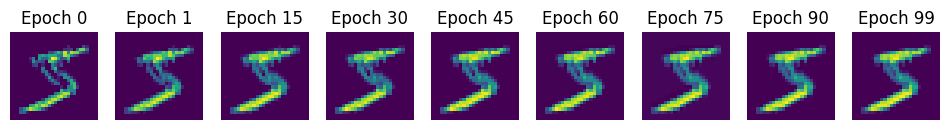

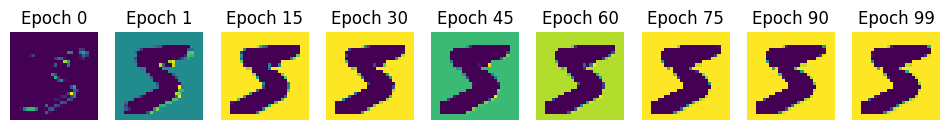

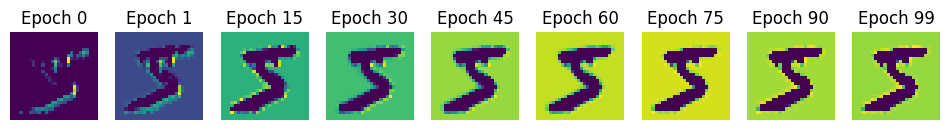

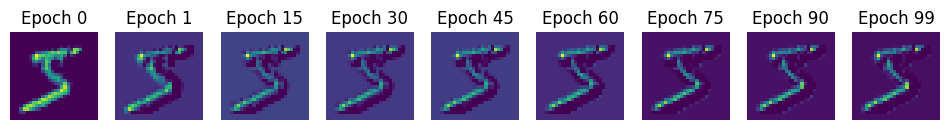

In [42]:
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

# Pooled feature similarity for the sample image:

In [24]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.5362)
tensor(0.9907)


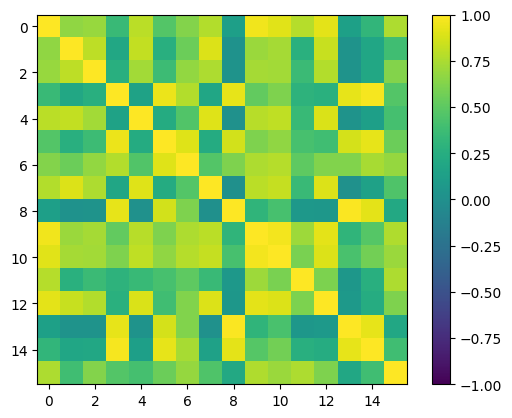

In [49]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# Hist for kernal activation similarities

Text(0, 0.5, 'Number of filter pairs')

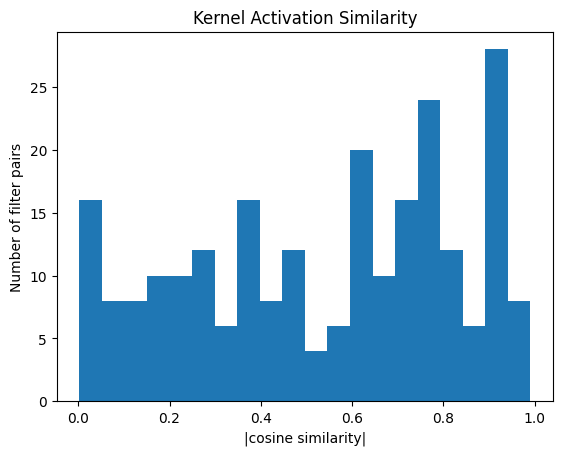

In [25]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Now inspecting the model omitting the bias terms

In [26]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_ae_cnn_get_features(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Loss: 0.1780
Epoch [1/100], Training Loss: 0.4295, Training Accuracy: 88.35
Epoch [2/100], Encoder Loss: 0.1567
Epoch [2/100], Training Loss: 0.1815, Training Accuracy: 94.88
Epoch [3/100], Encoder Loss: 0.1523
Epoch [3/100], Training Loss: 0.1339, Training Accuracy: 96.26
Epoch [4/100], Encoder Loss: 0.1503
Epoch [4/100], Training Loss: 0.1093, Training Accuracy: 96.97
Epoch [5/100], Encoder Loss: 0.1492
Epoch [5/100], Training Loss: 0.0943, Training Accuracy: 97.35
Epoch [6/100], Encoder Loss: 0.1482
Epoch [6/100], Training Loss: 0.0839, Training Accuracy: 97.64
Epoch [7/100], Encoder Loss: 0.1474
Epoch [7/100], Training Loss: 0.0758, Training Accuracy: 97.87
Epoch [8/100], Encoder Loss: 0.1466
Epoch [8/100], Training Loss: 0.0699, Training Accuracy: 98.05
Epoch [9/100], Encoder Loss: 0.1460
Epoch [9/100], Training Loss: 0.0645, Training Accuracy: 98.22
Epoch [10/100], Encoder Loss: 0.1456
Epoch [10/100], Training Loss: 0.0596, Trai

In [52]:
#save the features history 
features_df= pd.DataFrame(feature_history)

features_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_autoencoder_no_bias_features.csv",
    index=False,
)

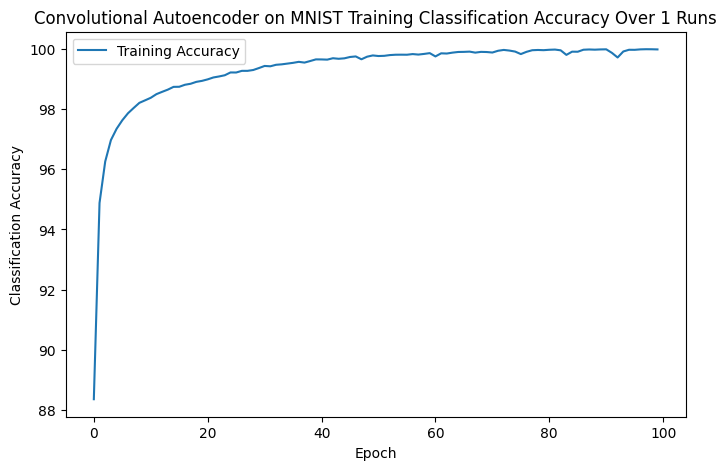

In [53]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Classification Accuracy Over 1 Runs")
plt.show()

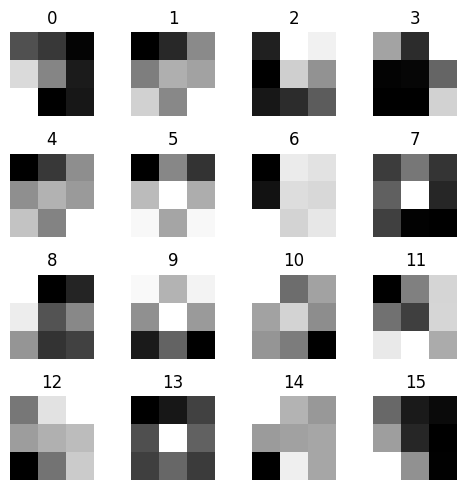

In [54]:
weights = feature_history[99]["encoder_weights"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[i,0], cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

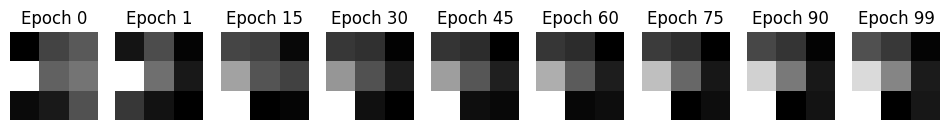

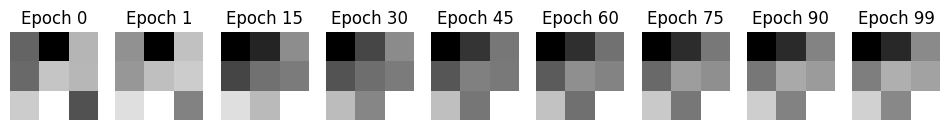

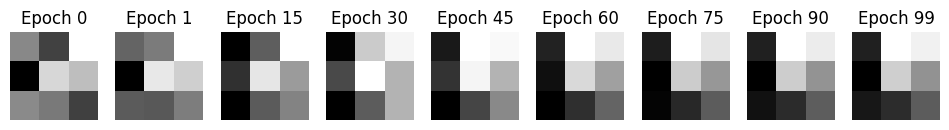

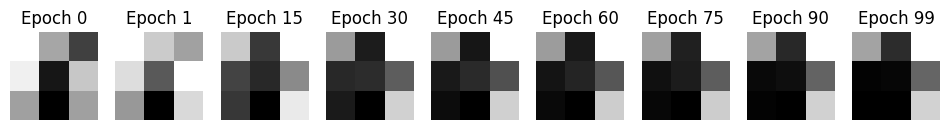

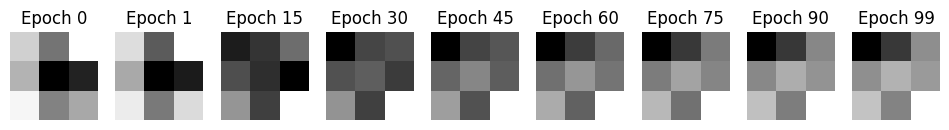

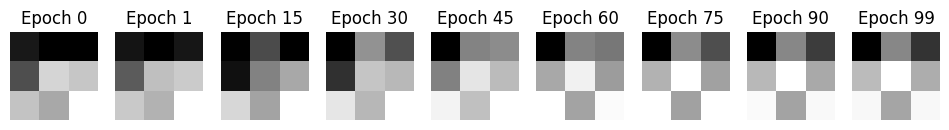

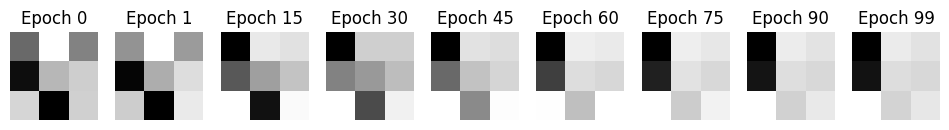

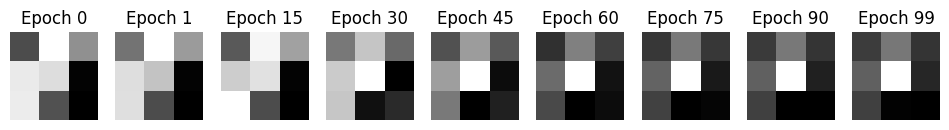

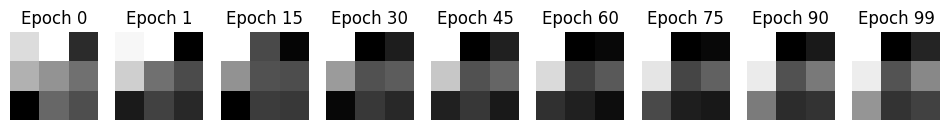

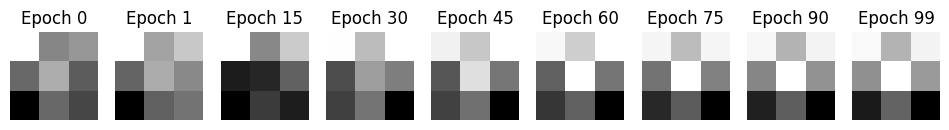

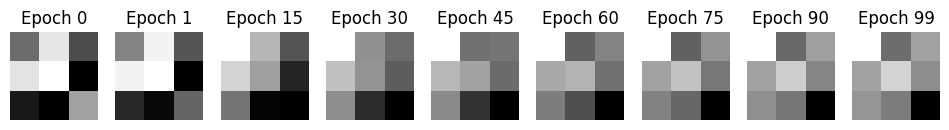

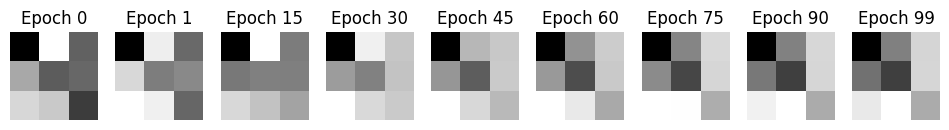

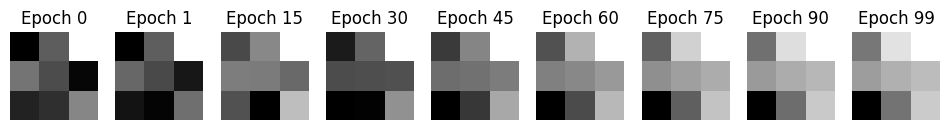

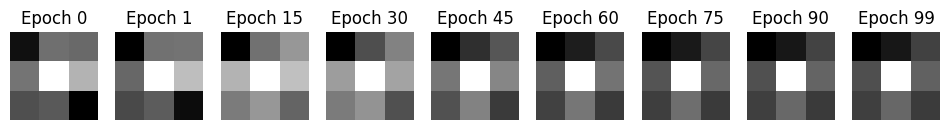

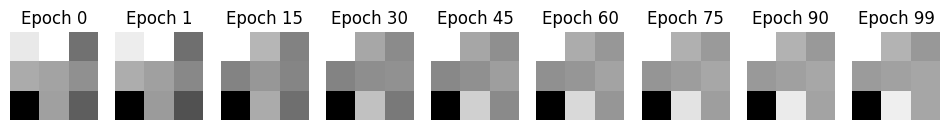

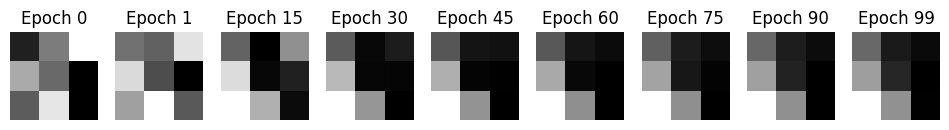

In [55]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        kernel = feature_history[epoch]["encoder_weights"][filter_idx,0]

        ax.imshow(kernel,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [27]:

encoder_weights = model.encoder.weight.flatten(1)

encoder_weights = F.normalize(encoder_weights, dim=1)

similarity_matrix = encoder_weights @ encoder_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=encoder_weights.device)

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.3180
Mean filter cosine similarity: 0.0102
Maximum filter similarity: 0.9945
Minimum filter similarity: -0.8757


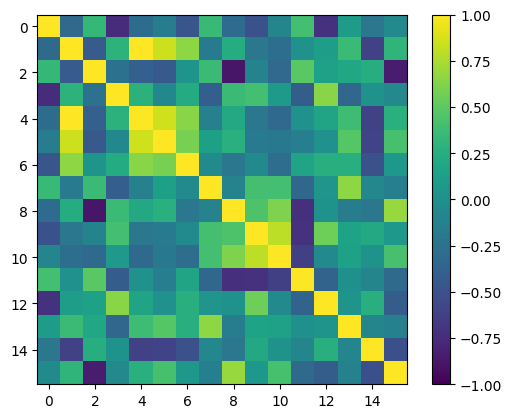

In [57]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# hist for kernel weights

Text(0, 0.5, 'Number of filter pairs')

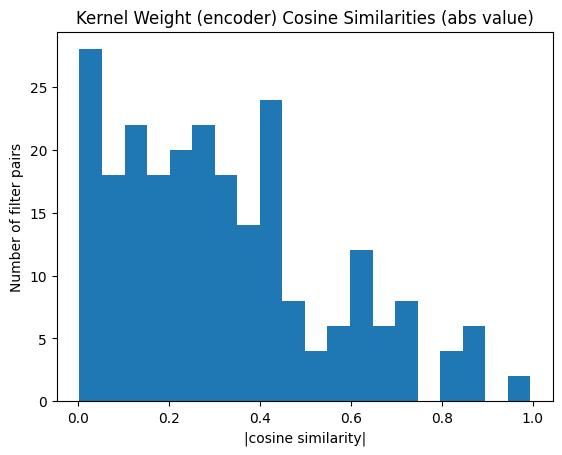

In [28]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight (encoder) Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Feature maps

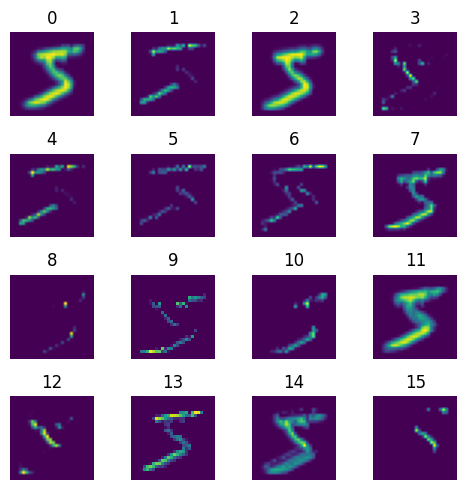

In [58]:
weights = feature_history[99]["maps"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[0,i], cmap="viridis")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Pooled:

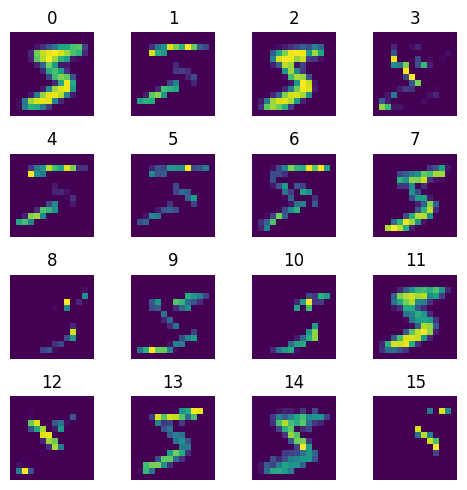

In [59]:
weights = feature_history[99]["pooled_maps"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[0,i], cmap="viridis")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

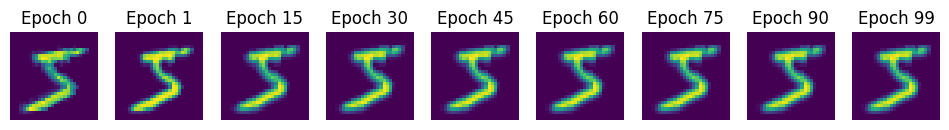

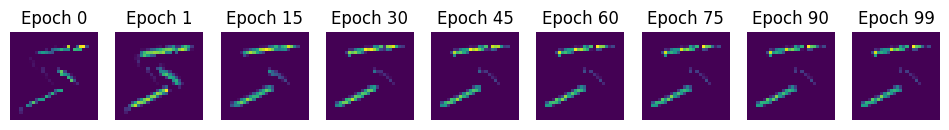

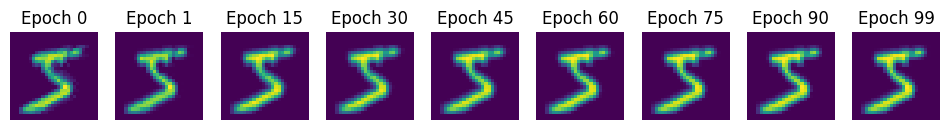

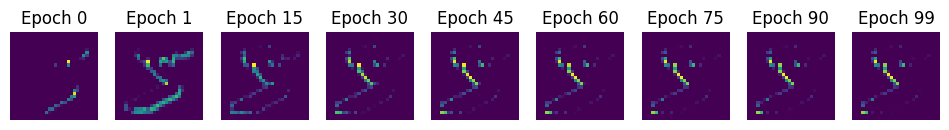

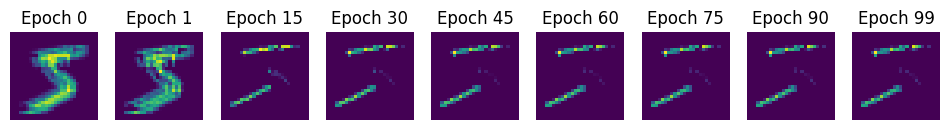

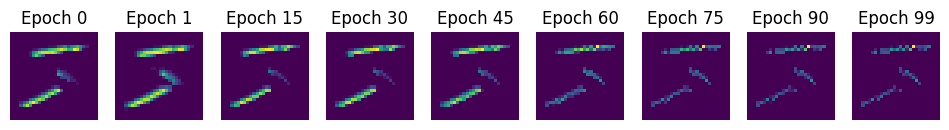

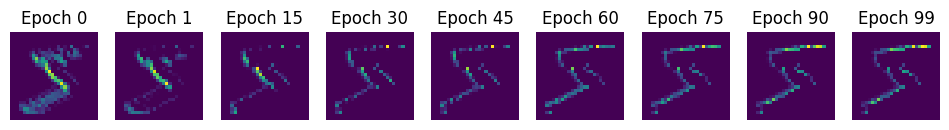

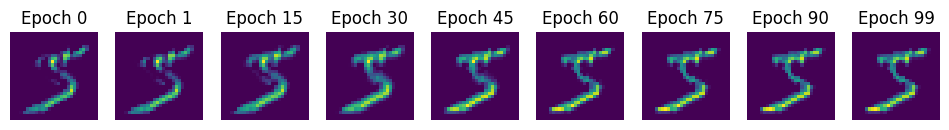

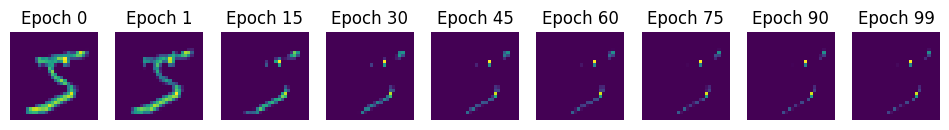

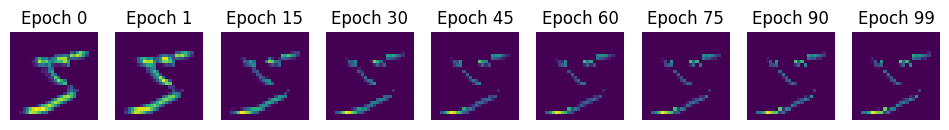

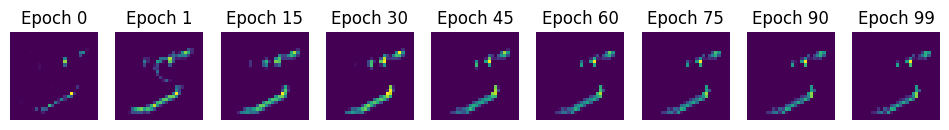

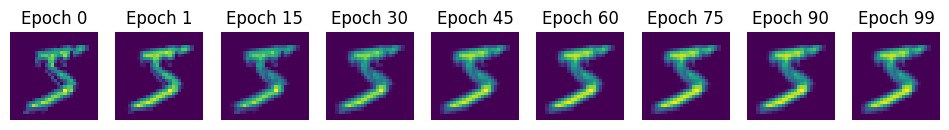

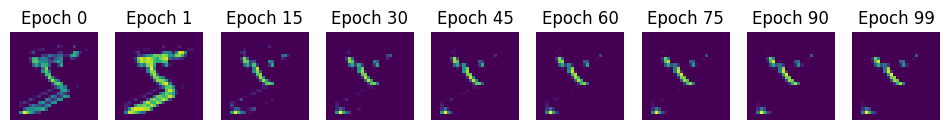

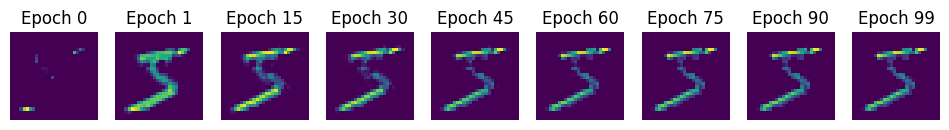

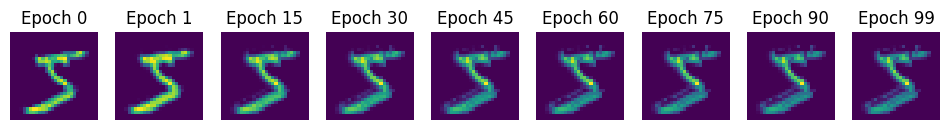

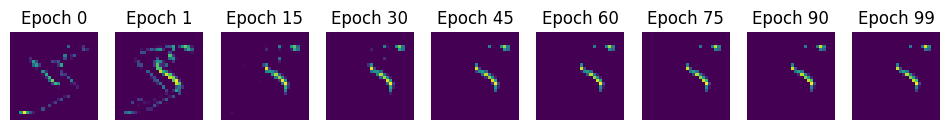

In [60]:
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [29]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.3440)
tensor(0.9922)


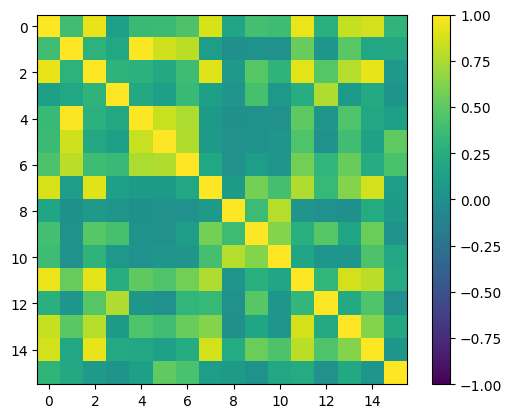

In [62]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# activation hist

Text(0, 0.5, 'Number of filter pairs')

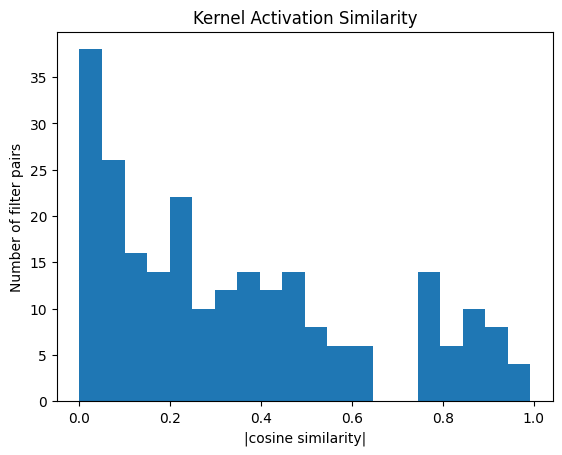

In [30]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Now inspecting the Optimal convolutional autoencoder model (no biases, weight sharing)

In [31]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_ae_cnn_weight_tie_get_features(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Loss: 0.1755
Epoch [1/100], Training Loss: 0.4588, Training Accuracy: 88.53
Epoch [2/100], Encoder Loss: 0.1586
Epoch [2/100], Training Loss: 0.1799, Training Accuracy: 95.38
Epoch [3/100], Encoder Loss: 0.1548
Epoch [3/100], Training Loss: 0.1310, Training Accuracy: 96.59
Epoch [4/100], Encoder Loss: 0.1527
Epoch [4/100], Training Loss: 0.1105, Training Accuracy: 97.14
Epoch [5/100], Encoder Loss: 0.1513
Epoch [5/100], Training Loss: 0.0982, Training Accuracy: 97.43
Epoch [6/100], Encoder Loss: 0.1504
Epoch [6/100], Training Loss: 0.0877, Training Accuracy: 97.70
Epoch [7/100], Encoder Loss: 0.1497
Epoch [7/100], Training Loss: 0.0794, Training Accuracy: 97.88
Epoch [8/100], Encoder Loss: 0.1492
Epoch [8/100], Training Loss: 0.0728, Training Accuracy: 98.03
Epoch [9/100], Encoder Loss: 0.1488
Epoch [9/100], Training Loss: 0.0676, Training Accuracy: 98.24
Epoch [10/100], Encoder Loss: 0.1484
Epoch [10/100], Training Loss: 0.0631, Trai

In [8]:
#save the features history 
features_df= pd.DataFrame(feature_history)

features_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_autoencoder_no_bias_weight_share_features.csv",
    index=False,
)

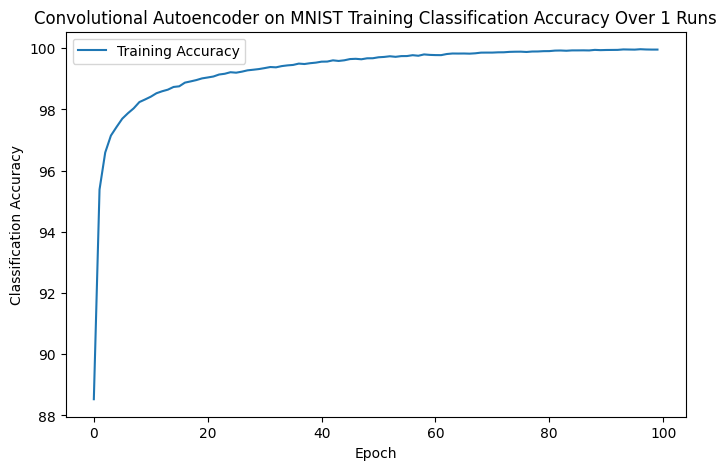

In [9]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Classification Accuracy Over 1 Runs")
plt.show()

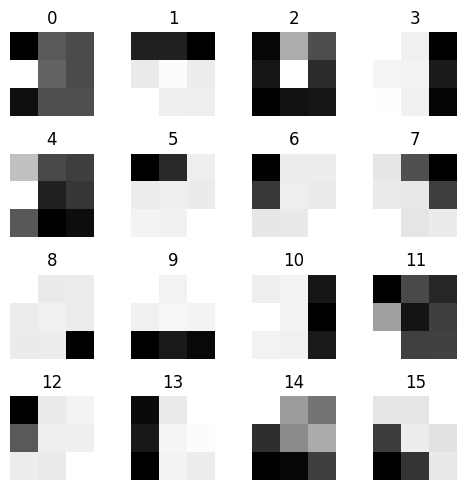

In [10]:
weights = feature_history[99]["encoder_weights"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[i,0], cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

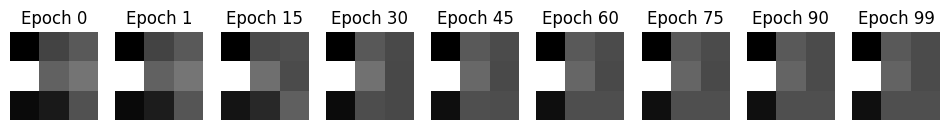

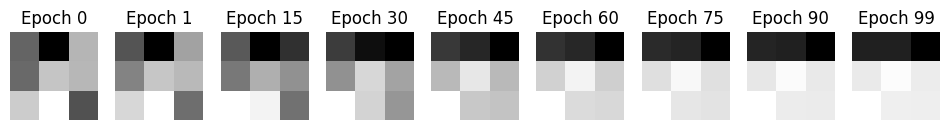

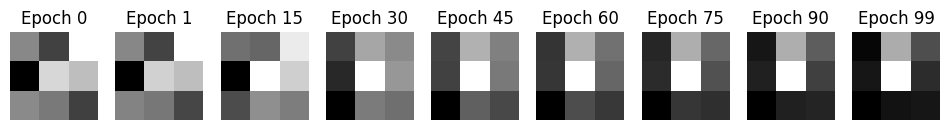

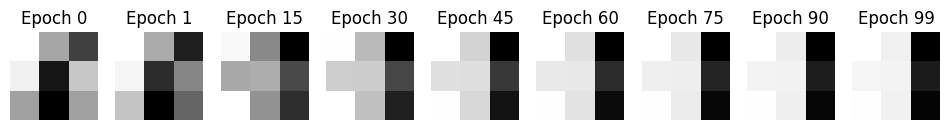

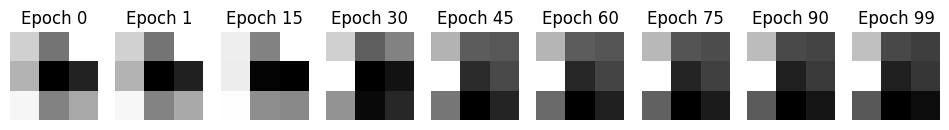

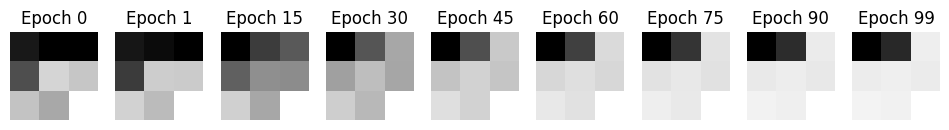

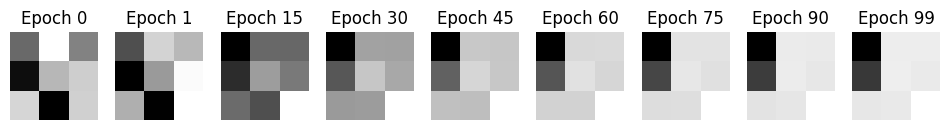

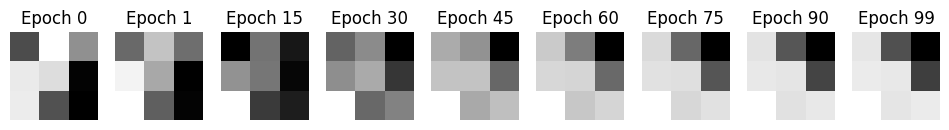

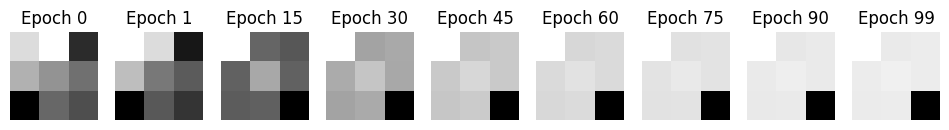

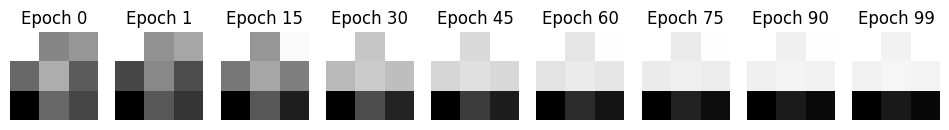

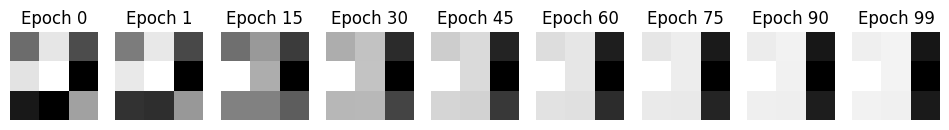

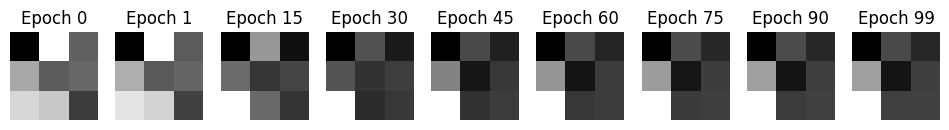

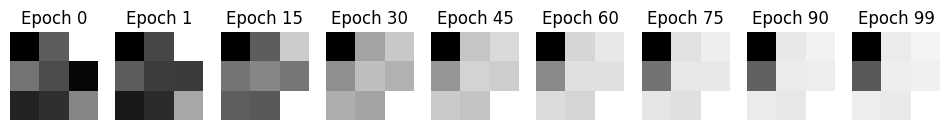

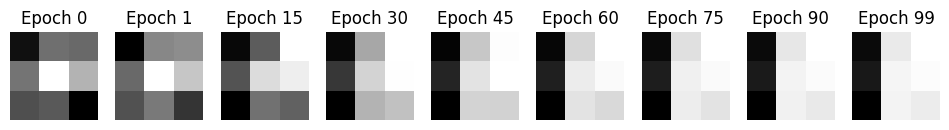

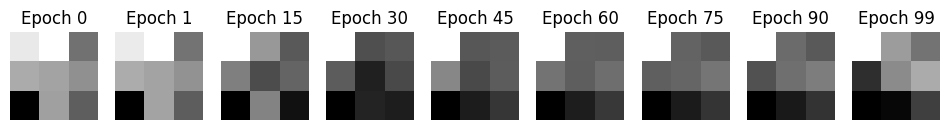

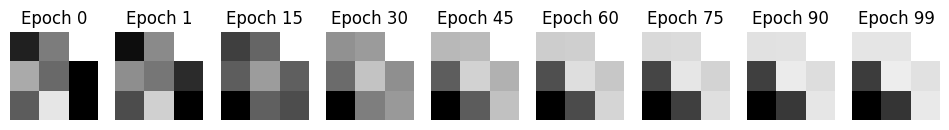

In [11]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        kernel = feature_history[epoch]["encoder_weights"][filter_idx,0]

        ax.imshow(kernel,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [32]:
import torch.nn.functional as F 
encoder_weights = model.encoder.weight.flatten(1)

encoder_weights = F.normalize(encoder_weights, dim=1)

similarity_matrix = encoder_weights @ encoder_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=encoder_weights.device)

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.2854
Mean filter cosine similarity: 0.1042
Maximum filter similarity: 0.9960
Minimum filter similarity: -0.8758


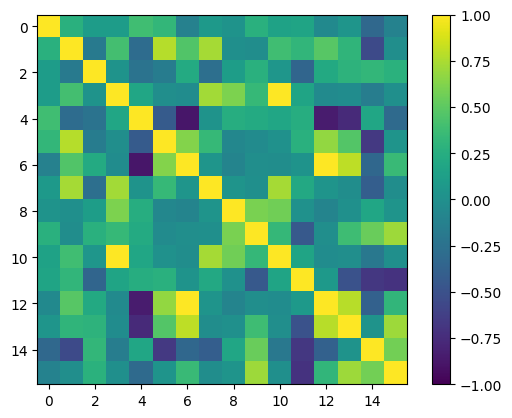

In [14]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# kernel similarity hist

Text(0, 0.5, 'Number of filter pairs')

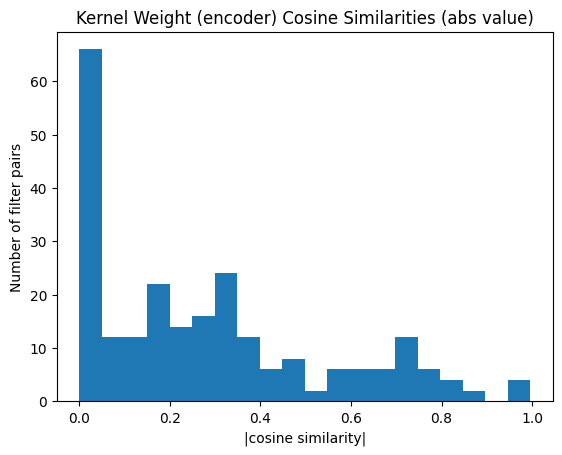

In [33]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight (encoder) Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

#  Feature maps

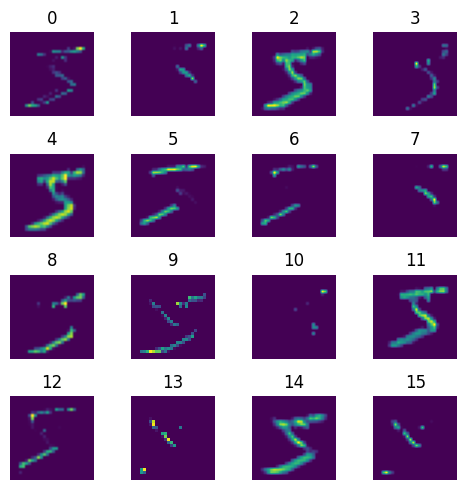

In [15]:
weights = feature_history[99]["maps"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[0,i], cmap="viridis")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Pooled:

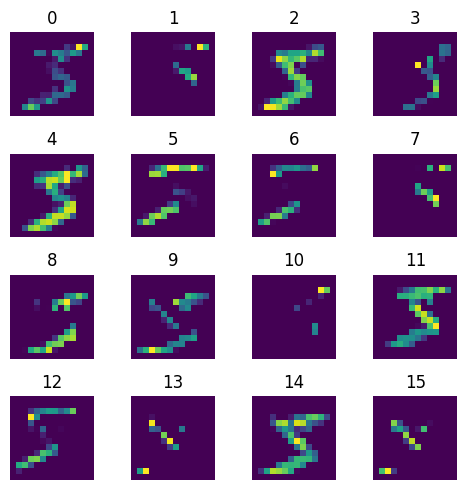

In [16]:
weights = feature_history[99]["pooled_maps"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[0,i], cmap="viridis")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

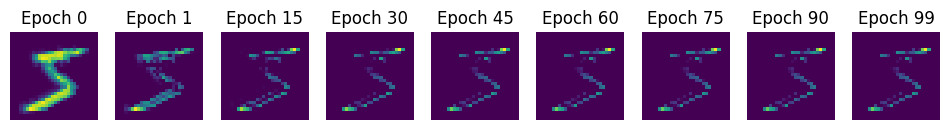

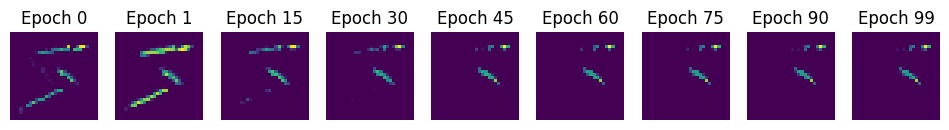

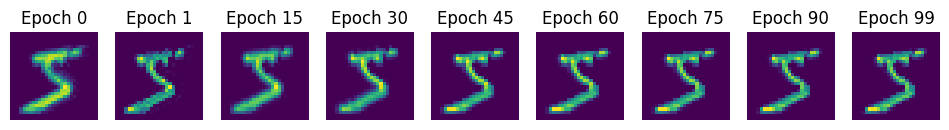

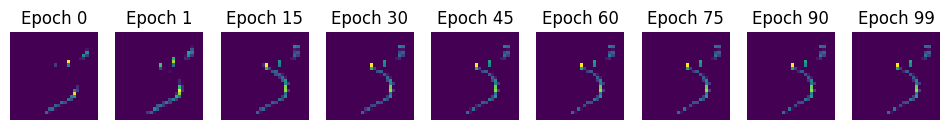

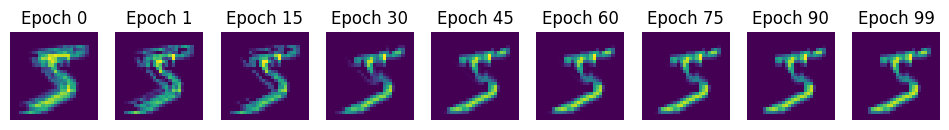

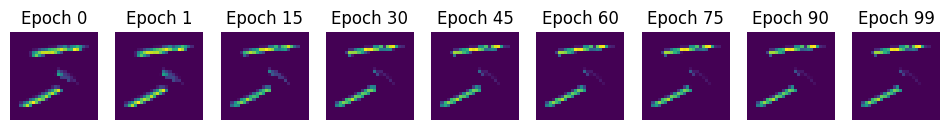

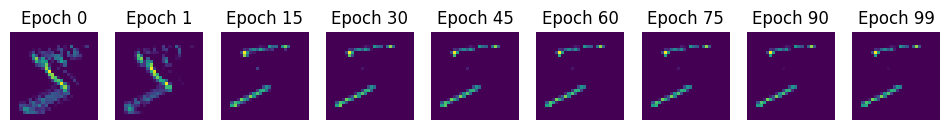

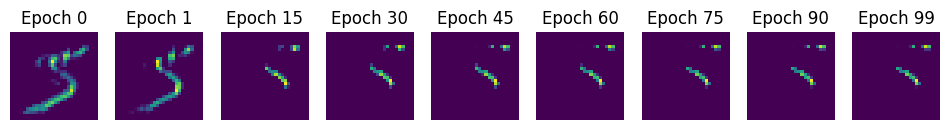

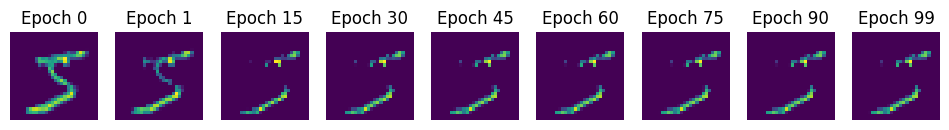

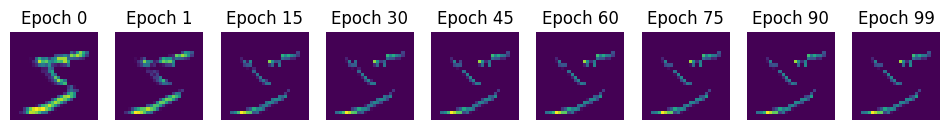

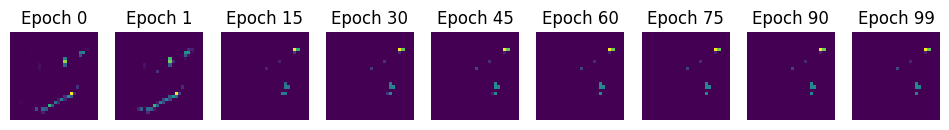

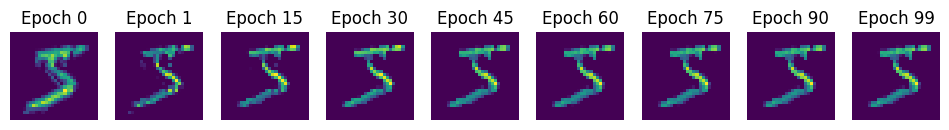

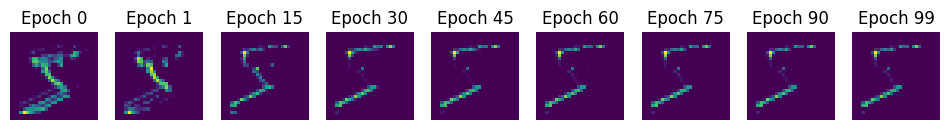

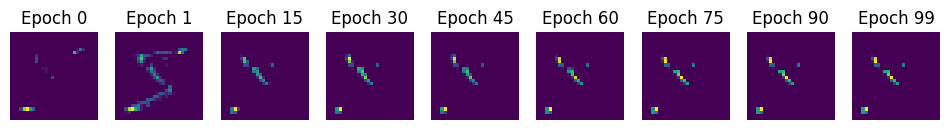

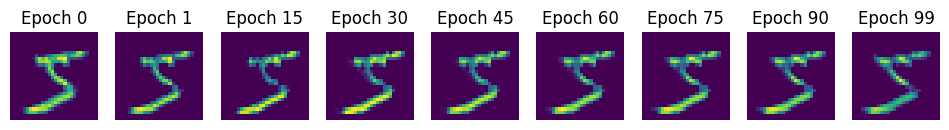

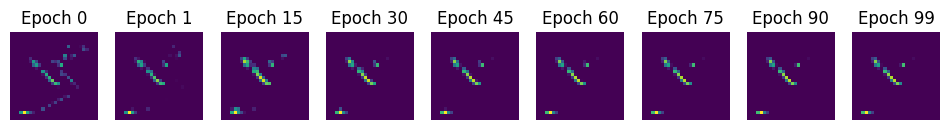

In [17]:
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [34]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)


mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.2716)
tensor(0.9774)


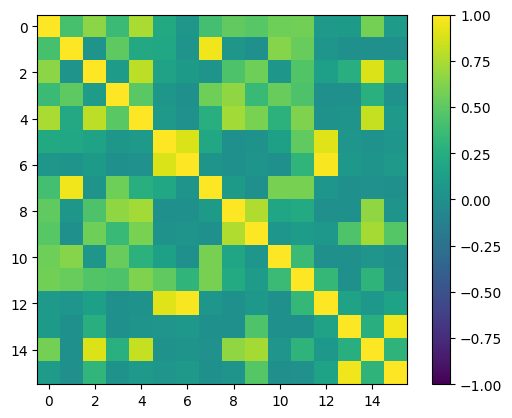

In [19]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# hist of activations similarities

Text(0, 0.5, 'Number of filter pairs')

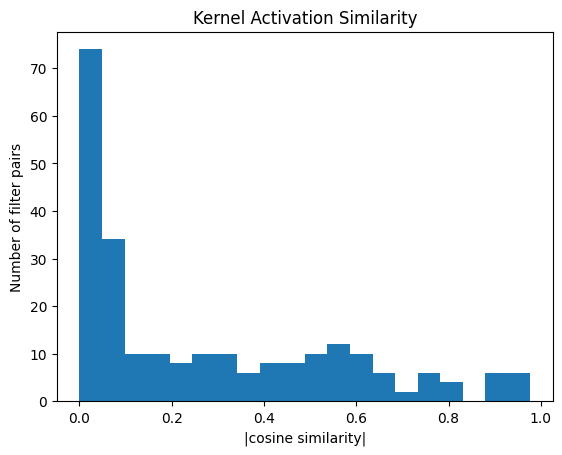

In [35]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# briefly testing compressing feature maps

In [50]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): # just 1 run
    #run training and evaluation

    if seed==0:
        n_epochs=1
    else:
        n_epochs=100


    print(f"model run: {seed}")


    model, training_history, elapsed = cnn_experiments.train_no_pool_ae_cnn_weight_tied(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=2,
        padding=1,
        kernel_size=3,
        output_padding=1,
        n_classes=10,
        bias=False,
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.1981
Epoch [1/1], Training Loss: 0.5309, Training Accuracy: 87.08
peak memory from train : 76.3828125
memory now reset and is: 33.978515625 MB
time elapsed: 1.2558099319994653
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.2139
Epoch [1/100], Training Loss: 0.4642, Training Accuracy: 87.45
Epoch [2/100], Encoder Loss: 0.1849
Epoch [2/100], Training Loss: 0.2261, Training Accuracy: 93.93
Epoch [3/100], Encoder Loss: 0.1759
Epoch [3/100], Training Loss: 0.1725, Training Accuracy: 95.31
Epoch [4/100], Encoder Loss: 0.1714
Epoch [4/100], Training Loss: 0.1413, Training Accuracy: 96.14
Epoch [5/100], Encoder Loss: 0.1691
Epoch [5/100], Training Loss: 0.1195, Training Accuracy: 96.76
Epoch [6/100], Encoder Loss: 0.1677
Epoch [6/100], Training Loss: 0.1042, Training Accuracy: 97.15
Epoch [7/100], Encoder Loss: 0.1667
Epoch [7/100], Training Loss: 0.0942, Training Accuracy: 97.39
Epoch [8/100], Encoder Loss: 0.1659
Epoch [8

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_compressed_epoch_results.csv",
    index=False,
)

# Loss and Accuracy

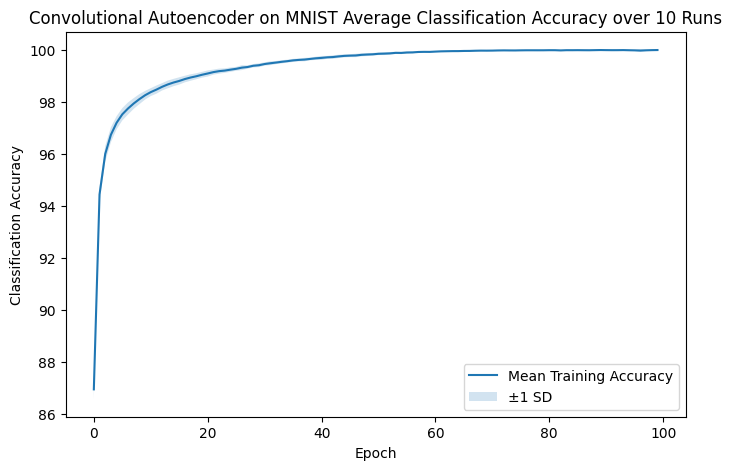

In [14]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Average Classification Accuracy over 10 Runs")
plt.show()

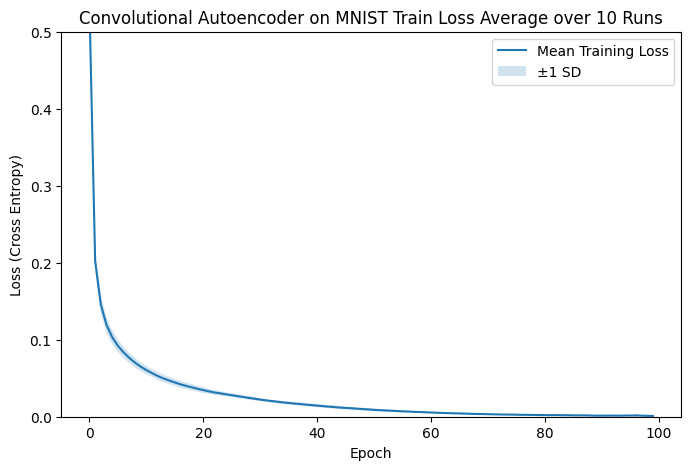

In [10]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("Convolutional Autoencoder on MNIST Train Loss Average over 10 Runs")
plt.show()

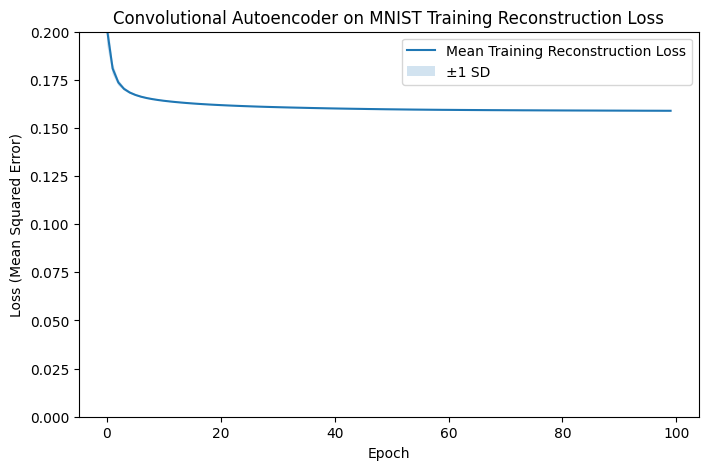

In [16]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Reconstruction Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(0,0.2)
plt.title("Convolutional Autoencoder on MNIST Training Reconstruction Loss")
plt.show()

# Memory and Runtime

In [52]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 60.82734375
All peak memories (including the warm up run):


[76.3828125,
 75.6650390625,
 59.1787109375,
 59.1787109375,
 59.1787109375,
 59.1787109375,
 59.1787109375,
 59.1787109375,
 59.1787109375,
 59.1787109375,
 59.1787109375]

In [53]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 125.61086344359992 
All training times for the 100 epochs over the 10 runs:


array([125.65810082, 126.60584169, 125.3996809 , 125.65489348,
       125.491046  , 125.09399574, 126.01888963, 125.07046916,
       125.84184381, 125.2738732 ])

# Inspecting the averages over the 10 runs:

In [ ]:
print(f"Max accuracy: {epoch_df["mean_accuracy"].max()}")
print(f"Max accuracy std: {epoch_df["std_accuracy"].max()}")

print(f"Min Loss: {epoch_df["task_mean_loss"].min()}")
print(f"Max Loss std: {epoch_df["task_std_loss"].max()}")

print(f"Min Encoder Loss: {epoch_df["encoder_mean_loss"].min()} (to 10 dp: {epoch_df["encoder_mean_loss"].min():.10f})")
print(f"Max Encoder Loss std: {epoch_df["encoder_std_loss"].min()} (to 10 dp: {epoch_df["encoder_std_loss"].min():.10f})")

Max accuracy: 99.99716666666667
Max accuracy std: 0.3787743758199308
Min Loss: 0.0010207980249957627
Max Loss std: 0.035799694550951326
Min Encoder Loss: 0.15893174908262617 (to 10 dp: 0.1589317491)
Max Encoder Loss std: 3.985372769561518e-05 (to 10 dp: 0.0000398537)


# Removing the pooling but keeping the 28x28 feature maps

In [31]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): # just 1 run
    #run training and evaluation

    if seed==0:
        n_epochs=1
    else:
        n_epochs=100


    print(f"model run: {seed}")


    model, training_history, elapsed = cnn_experiments.train_no_pool_ae_cnn_weight_tied(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        output_padding=0,
        n_classes=10,
        bias=False,
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.1755
Epoch [1/1], Training Loss: 0.3045, Training Accuracy: 91.78
peak memory from train : 93.79443359375
memory now reset and is: 40.5595703125 MB
time elapsed: 1.345567229000153
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.2174
Epoch [1/100], Training Loss: 0.2807, Training Accuracy: 91.88
Epoch [2/100], Encoder Loss: 0.1626
Epoch [2/100], Training Loss: 0.1221, Training Accuracy: 96.79
Epoch [3/100], Encoder Loss: 0.1557
Epoch [3/100], Training Loss: 0.0888, Training Accuracy: 97.78
Epoch [4/100], Encoder Loss: 0.1530
Epoch [4/100], Training Loss: 0.0756, Training Accuracy: 98.13
Epoch [5/100], Encoder Loss: 0.1516
Epoch [5/100], Training Loss: 0.0663, Training Accuracy: 98.42
Epoch [6/100], Encoder Loss: 0.1506
Epoch [6/100], Training Loss: 0.0586, Training Accuracy: 98.58
Epoch [7/100], Encoder Loss: 0.1499
Epoch [7/100], Training Loss: 0.0529, Training Accuracy: 98.73
Epoch [8/100], Encoder Loss: 0.1493
Epoc

In [ ]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_no_pool_28x28_epoch_results.csv",
    index=False,
)

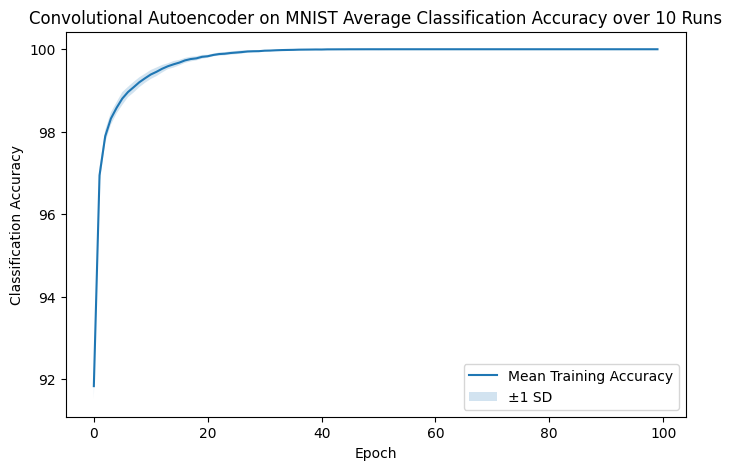

In [34]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Average Classification Accuracy over 10 Runs")
plt.show()

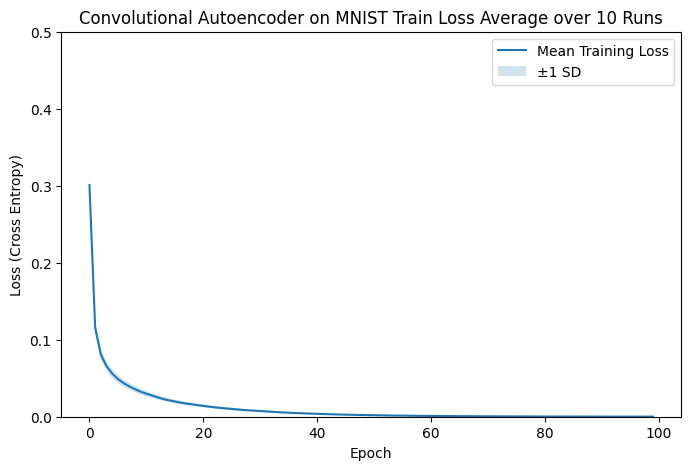

In [15]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("Convolutional Autoencoder on MNIST Train Loss Average over 10 Runs")
plt.show()

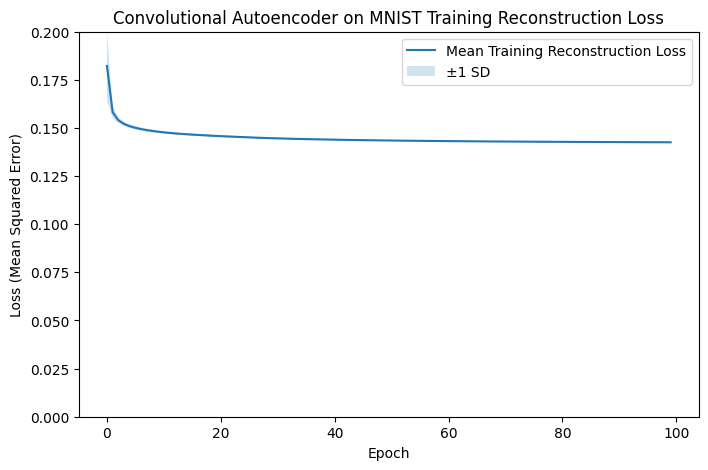

In [36]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Reconstruction Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(0,0.2)
plt.title("Convolutional Autoencoder on MNIST Training Reconstruction Loss")
plt.show()

In [37]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 88.51552734375
All peak memories (including the warm up run):


[93.79443359375,
 93.79248046875,
 87.92919921875,
 87.92919921875,
 87.92919921875,
 87.92919921875,
 87.92919921875,
 87.92919921875,
 87.92919921875,
 87.92919921875,
 87.92919921875]

In [38]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 129.00922023510006 
All training times for the 100 epochs over the 10 runs:


array([130.19111606, 129.612078  , 129.92961926, 128.5007536 ,
       128.95654995, 128.89787923, 128.05676546, 128.86909397,
       128.76743636, 128.31091047])

In [39]:
print(f"Max accuracy: {epoch_df["mean_accuracy"].max()}")
print(f"Max accuracy std: {epoch_df["std_accuracy"].max()}")

print(f"Min Loss: {epoch_df["task_mean_loss"].min()}")
print(f"Max Loss std: {epoch_df["task_std_loss"].max()}")

print(f"Min Encoder Loss: {epoch_df["encoder_mean_loss"].min()} (to 10 dp: {epoch_df["encoder_mean_loss"].min():.10f})")
print(f"Max Encoder Loss std: {epoch_df["encoder_std_loss"].min()} (to 10 dp: {epoch_df["encoder_std_loss"].min():.10f})")

Max accuracy: 100.0
Max accuracy std: 0.31711897521978016
Min Loss: 9.358983246203663e-05
Max Loss std: 0.015965346136263006
Min Encoder Loss: 0.14256391381963768 (to 10 dp: 0.1425639138)
Max Encoder Loss std: 0.00016255257364838948 (to 10 dp: 0.0001625526)


# Running the training and test procedure for the convolutional autoencoder
### For comparison with all other methods (all other methods being filters as autoencoders model, cnn, and hebb model)

In [6]:
from torchvision import datasets, transforms

In [7]:
#controlling randomness
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [ ]:
#count how many params of the model...



device = torch.device('cuda')

model = weight_tied_conv_autoencoder.CNN_AE(    
        input_dims=28,
        in_channels=1,
        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        kernel_size=5,
        stride=1,
        padding=2,

        bias=False,

        n_filters=16,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 1, 5, 5) -> 400
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31770


In [8]:

mnist_root = "../datasets/mnist"

base_transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root=mnist_root,
    train=True,
    download=True,
    transform=base_transform
)

mnist_test = datasets.MNIST(
    root=mnist_root,
    train=False,
    download=True,
    transform=base_transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.72MB/s]


In [9]:
#control the dataloader workers
def seed_worker(worker_id): 
    worker_seed = torch.initial_seed() % 2**32 #converting to range expected by NumPy/Python's seeding mechanisms.

    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [ ]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_linear_annealing_ae_cnn_weight_tied(
        mnist_train,
        mnist_test,
        input_dims=28,
        in_channels=1,
   
        learning_rate=0.001,


        bias=False,   
        n_ae_epochs=1,      
        n_classifier_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda


Epoch [1/1], Encoder Loss: 0.1075
Training classifier...
Epoch [1/30], Task Training Loss: 0.1868, Accuracy: 94.83%, Task Test Loss: 0.08645373061714563, Task Test Accuracy: 97.58% LR: 0.001000
Epoch [2/30], Task Training Loss: 0.0774, Accuracy: 97.78%, Task Test Loss: 0.06695204455061418, Task Test Accuracy: 97.83% LR: 0.001000
Epoch [3/30], Task Training Loss: 0.0595, Accuracy: 98.23%, Task Test Loss: 0.05858726908265951, Task Test Accuracy: 98.23% LR: 0.001000
Epoch [4/30], Task Training Loss: 0.0511, Accuracy: 98.52%, Task Test Loss: 0.0499611999702367, Task Test Accuracy: 98.35% LR: 0.001000
Epoch [5/30], Task Training Loss: 0.0446, Accuracy: 98.67%, Task Test Loss: 0.051941819722203623, Task Test Accuracy: 98.3% LR: 0.001000
Epoch [6/30], Task Training Loss: 0.0400, Accuracy: 98.77%, Task Test Loss: 0.05523984716718743, Task Test Accuracy: 98.22% LR: 0.001000
Epoch [7/30], Task Training Loss: 0.0357, Accuracy: 98.88%, Task Test Loss: 0.04913188614869553, Task Test Accuracy: 98.51

In [ ]:
# extracted run results manually for inspection
#first run test results:
run1= [98.62,
    98.57,
    98.59,
    98.63,
    98.65,
    98.62,
    98.62,
    98.65,
    98.64,
    98.63
]
#next run:
run2 = [
    98.56,
    98.59,
    98.54,
    98.57,
    98.55,
    98.56,
    98.57,
    98.57,
    98.57,
    98.57
]
run3 =[
    98.75,
    98.74,
    98.74,
    98.73,
    98.73,
    98.73,
    98.75,
    98.75,
    98.74,
    98.75
]
run4= [
    98.56,
    98.52,
    98.62,
    98.63,
    98.61,
    98.61,
    98.62,
    98.61,
    98.61,
    98.61
]
run5=[
    98.60,
    98.58,
    98.58,
    98.58,
    98.57,
    98.59,
    98.57,
    98.57,
    98.57,
    98.57
]



In [12]:
runs = np.array([run1, run2, run3, run4, run5])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 98.62 ± 0.06%


In [11]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories)
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


ae_epochs= np.arange(1, len(encoder_mean_loss)+1)

epochs = np.arange(1, len(task_mean_loss)+1)



In [12]:
ae_df = pd.DataFrame({
    "epoch": ae_epochs,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})


classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [ ]:
final10 = np.mean(test_accuracies[:, 10:20], axis=1)
np.mean(final10), np.std(final10)

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
ae_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal_ae_epoch_results.csv",
    index=False,
)

In [15]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal__classifer_epoch_results.csv",
    index=False,
)

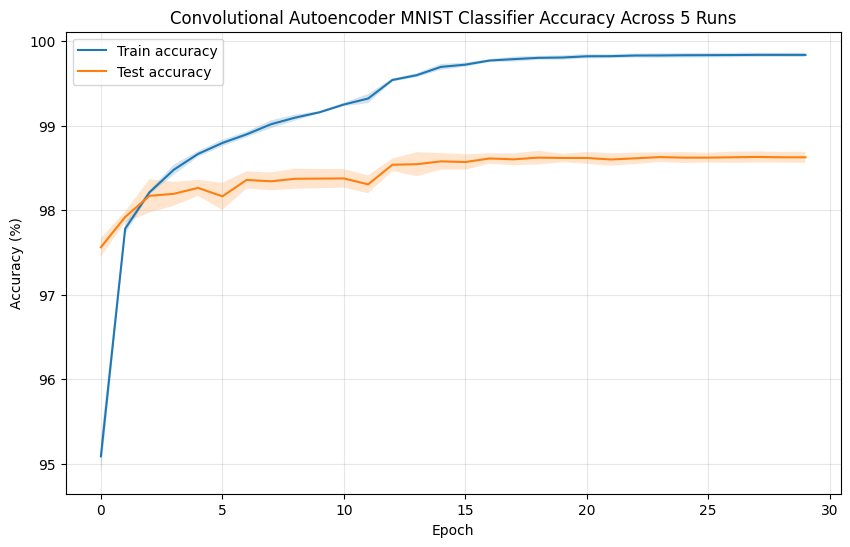

In [16]:
epochs = np.arange(len(mean_acc))



plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Convolutional Autoencoder MNIST Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

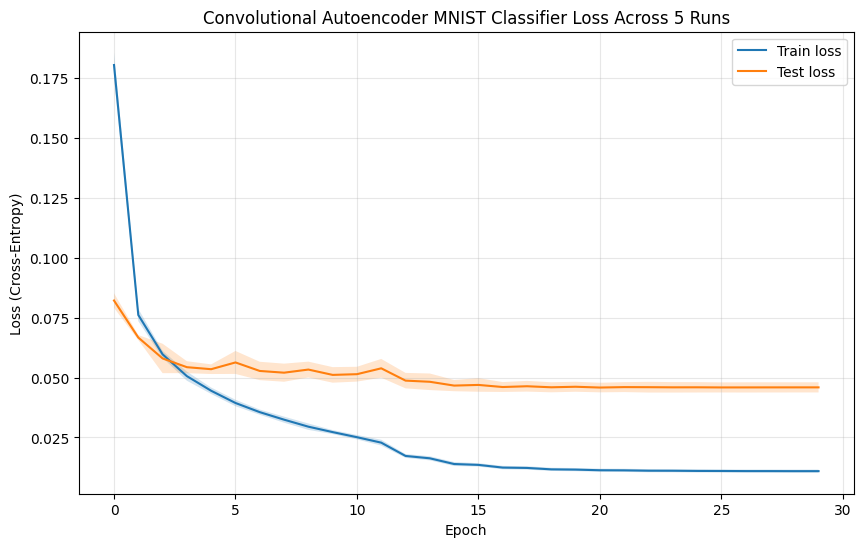

In [17]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("Convolutional Autoencoder MNIST Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 75.4033203125
All peak memories (including the warm up run):


[75.28076171875, 75.4033203125, 75.4033203125, 75.4033203125, 75.4033203125]

In [19]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 331.6732967287499 
All training times for the 100 epochs over the 10 runs:
[334.40533864 331.43153759 330.1206486  330.73566209]
[330.73148994999997, 334.4053386369999, 331.4315375880001, 330.12064860099963, 330.735662089]


In [20]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")

print(" " \
"")
print(f"Min avg Encoder Loss: {ae_df["encoder_mean_loss"].min():.2f} (to 10 dp: {ae_df["encoder_mean_loss"].min():.10f})")

Max avg train accuracy: 99.84
 
Max avg test accuracy: 98.63
 
Min train avg Loss: 0.01
 
Min avg Encoder Loss: 0.11 (to 10 dp: 0.1096171780)


In [21]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 99.84
final test mean accuracy: 98.63


In [22]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 0.03
the above test accuracy with std: 0.07


In [23]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 99.83 ± 0.01%
average test mean accuracy final 10 epochs: 98.62 ± 0.01%


In [ ]:
runs = np.array([run1, run2, run3, run4, run5])

#man accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 98.62 ± 0.06%


# FMNIST 
### (same number of params)

In [24]:
#getting data with minimal preprocessing

fmnist_root = "../datasets/fmnist"

base_transform = transforms.ToTensor()

fmnist_train = datasets.FashionMNIST(
    root=fmnist_root,
    train=True,
    download=True,
    transform=base_transform
)

fmnist_test = datasets.FashionMNIST(
    root=fmnist_root,
    train=False,
    download=True,
    transform=base_transform
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.49MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.61MB/s]


In [ ]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_linear_annealing_ae_cnn_weight_tied(
        fmnist_train,
        fmnist_test,
        input_dims=28,
        in_channels=1,
   
        learning_rate=0.001,


        bias=False,   
        n_ae_epochs=1,      
        n_classifier_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0791
Training classifier...
Epoch [1/30], Task Training Loss: 0.4220, Accuracy: 85.40%, Task Test Loss: 0.355661827382768, Task Test Accuracy: 87.34% LR: 0.001000
Epoch [2/30], Task Training Loss: 0.3144, Accuracy: 88.86%, Task Test Loss: 0.33500846802808676, Task Test Accuracy: 88.14% LR: 0.001000
Epoch [3/30], Task Training Loss: 0.2865, Accuracy: 89.76%, Task Test Loss: 0.311475548394926, Task Test Accuracy: 88.65% LR: 0.001000
Epoch [4/30], Task Training Loss: 0.2705, Accuracy: 90.27%, Task Test Loss: 0.3006663909478552, Task Test Accuracy: 89.18% LR: 0.001000
Epoch [5/30], Task Training Loss: 0.2585, Accuracy: 90.70%, Task Test Loss: 0.3045578957742946, Task Test Accuracy: 89.17% LR: 0.001000
Epoch [6/30], Task Training Loss: 0.2500, Accuracy: 90.99%, Task Test Loss: 0.3171452603712203, Task Test Accuracy: 88.61% LR: 0.001000
Epoch [7/30], Task Training Loss: 0.2418, Accuracy: 91.22%, Task Test Loss: 0.30153657135310447, Ta

In [14]:
#again extracted final 10 runs manually for inspection


run1= [
    90.15,
    90.12,
    90.08,
    90.12,
    90.08,
    90.08,
    90.08,
    90.07,
    90.12,
    90.07
]

run2=[
    90.19,
    90.16,
    90.27,
    90.20,
    90.25,
    90.25,
    90.21,
    90.29,
    90.25,
    90.29
]

run3=[
    90.17,
    90.03,
    90.12,
    90.05,
    90.10,
    90.02,
    90.01,
    90.05,
    90.05,
    90.00
]

run4=[
    90.45,
    90.44,
    90.45,
    90.40,
    90.42,
    90.39,
    90.47,
    90.45,
    90.46,
    90.46
]

run5=[
    90.17,
    90.16,
    90.14,
    90.17,
    90.19,
    90.17,
    90.12,
    90.15,
    90.19,
    90.20
]

In [26]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories)
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


ae_epochs= np.arange(1, len(encoder_mean_loss)+1)

epochs = np.arange(1, len(task_mean_loss)+1)



In [27]:
ae_df = pd.DataFrame({
    "epoch": ae_epochs,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})


classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [28]:
ae_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal_fmnist_ae_epoch_results.csv",
    index=False,
)

In [29]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal__fmnist_classifer_epoch_results.csv",
    index=False,
)

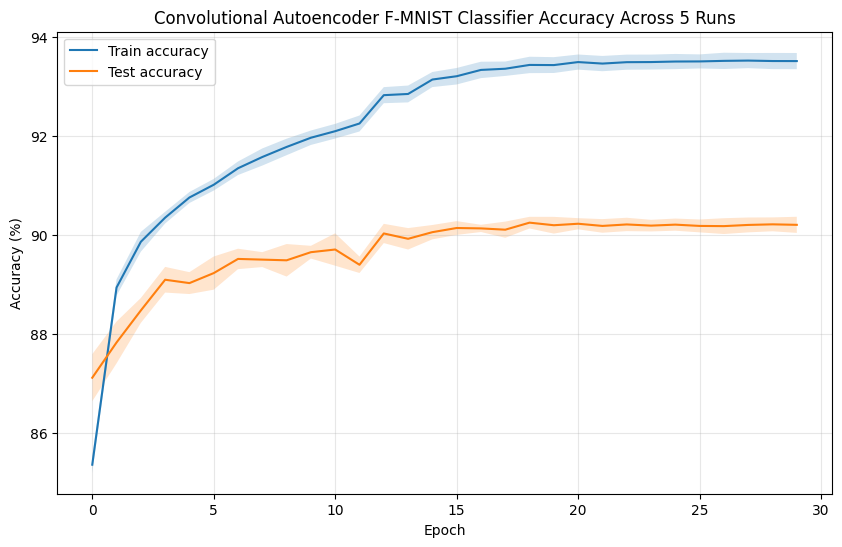

In [30]:
epochs = np.arange(len(mean_acc))



plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Convolutional Autoencoder F-MNIST Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

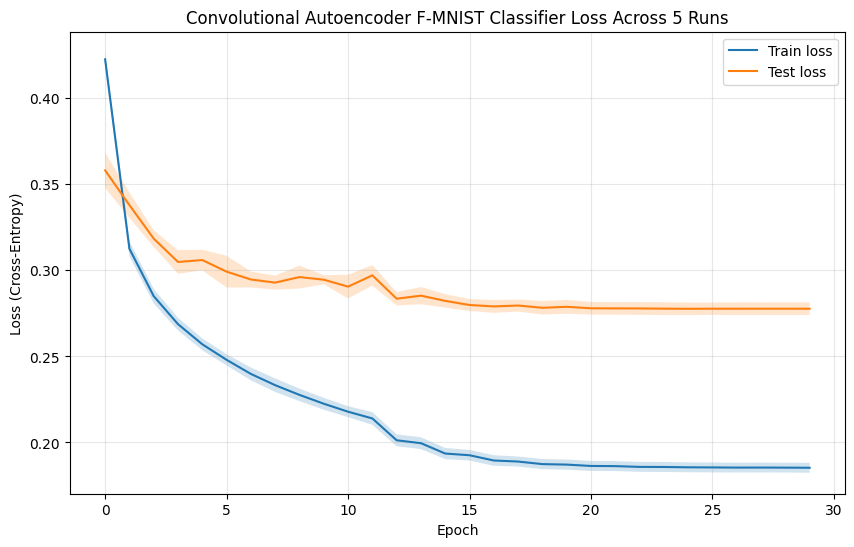

In [31]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("Convolutional Autoencoder F-MNIST Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [32]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 75.4033203125
All peak memories (including the warm up run):


[75.4033203125, 75.4033203125, 75.4033203125, 75.4033203125, 75.4033203125]

In [33]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 340.0953029107501 
All training times for the 100 epochs over the 10 runs:
[339.19185957 338.52141419 341.29510823 341.37282966]
[342.66889408399993, 339.1918595699999, 338.5214141880001, 341.29510822500015, 341.3728296600002]


In [34]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")

print(" " \
"")
print(f"Min avg Encoder Loss: {ae_df["encoder_mean_loss"].min():.2f} (to 10 dp: {ae_df["encoder_mean_loss"].min():.10f})")

Max avg train accuracy: 93.52
 
Max avg test accuracy: 90.25
 
Min train avg Loss: 0.19
 
Min avg Encoder Loss: 0.08 (to 10 dp: 0.0799795277)


In [35]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 93.51
final test mean accuracy: 90.20


In [36]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 0.16
the above test accuracy with std: 0.16


In [37]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 93.49 ± 0.03%
average test mean accuracy final 10 epochs: 90.20 ± 0.02%


In [16]:
runs = np.array([run1, run2, run3, run4, run5])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 90.20 ± 0.13%


# Cifar-10

In [ ]:
#count how many params of the model...


device = torch.device('cuda')

model = weight_tied_conv_autoencoder.CNN_AE(    
        input_dims=32,
        in_channels=3,
        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        kernel_size=5,
        stride=1,
        padding=2,

        bias=False,

        n_filters=16,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 3, 5, 5) -> 1200
fc.weight            (10, 4096) -> 40960
fc.bias              (10,) -> 10
42170


In [39]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayush1220/cifar10")

print("Path to dataset files:", path)

100%|██████████| 139M/139M [00:03<00:00, 37.0MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2


In [40]:
print(os.listdir(path))

['cifar10']


In [41]:
cifar_path = os.path.join(path, "cifar10")

In [42]:
cifar_train_path = os.path.join(cifar_path,"train")

In [43]:
cifar_test_path = os.path.join(cifar_path,"test")

In [44]:
final_transform = transforms.Compose([
    transforms.ToTensor()
])

In [45]:
train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=final_transform
)

test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=final_transform
)

In [ ]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_linear_annealing_ae_cnn_weight_tied(
        train_dataset,
        test_dataset,
        input_dims=32,
        in_channels=3,
   
        learning_rate=0.001,


        bias=False,   
        n_ae_epochs=1,      
        n_classifier_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0365
Training classifier...
Epoch [1/30], Task Training Loss: 1.4867, Accuracy: 48.03%, Task Test Loss: 1.342195674112648, Task Test Accuracy: 53.0% LR: 0.001000
Epoch [2/30], Task Training Loss: 1.2943, Accuracy: 54.85%, Task Test Loss: 1.2772624784973776, Task Test Accuracy: 56.07% LR: 0.001000
Epoch [3/30], Task Training Loss: 1.2370, Accuracy: 57.04%, Task Test Loss: 1.2554151184239966, Task Test Accuracy: 56.64% LR: 0.001000
Epoch [4/30], Task Training Loss: 1.2017, Accuracy: 58.07%, Task Test Loss: 1.2324161100539432, Task Test Accuracy: 57.15% LR: 0.001000
Epoch [5/30], Task Training Loss: 1.1703, Accuracy: 59.32%, Task Test Loss: 1.235347666937834, Task Test Accuracy: 57.23% LR: 0.001000
Epoch [6/30], Task Training Loss: 1.1578, Accuracy: 59.79%, Task Test Loss: 1.2225046556466703, Task Test Accuracy: 57.93% LR: 0.001000
Epoch [7/30], Task Training Loss: 1.1326, Accuracy: 60.80%, Task Test Loss: 1.2268745842253326, Task 

In [17]:
run0 = [
    59.16, 59.34, 59.55, 59.36, 59.25, 59.44, 59.34, 59.26, 59.35, 59.26
]

run1 = [
    59.24, 58.89, 59.10, 59.08, 59.15, 59.11, 59.08, 59.05, 59.14, 59.18
]

run2 = [
    58.95, 58.84, 58.70, 58.78, 58.80, 58.78, 58.77, 58.74, 58.85, 58.81
]

run3 = [
    58.38, 58.65, 58.30, 58.38, 58.43, 58.34, 58.50, 58.43, 58.46, 58.45
]

run4 = [
    59.19, 59.25, 59.33, 59.17, 59.06, 59.35, 59.25, 59.28, 59.18, 59.17
]

In [47]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories)
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


ae_epochs= np.arange(1, len(encoder_mean_loss)+1)

epochs = np.arange(1, len(task_mean_loss)+1)



In [48]:
ae_df = pd.DataFrame({
    "epoch": ae_epochs,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})


classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [49]:
ae_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal_cifar10_ae_epoch_results.csv",
    index=False,
)

In [50]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal__cifar10_classifer_epoch_results.csv",
    index=False,
)

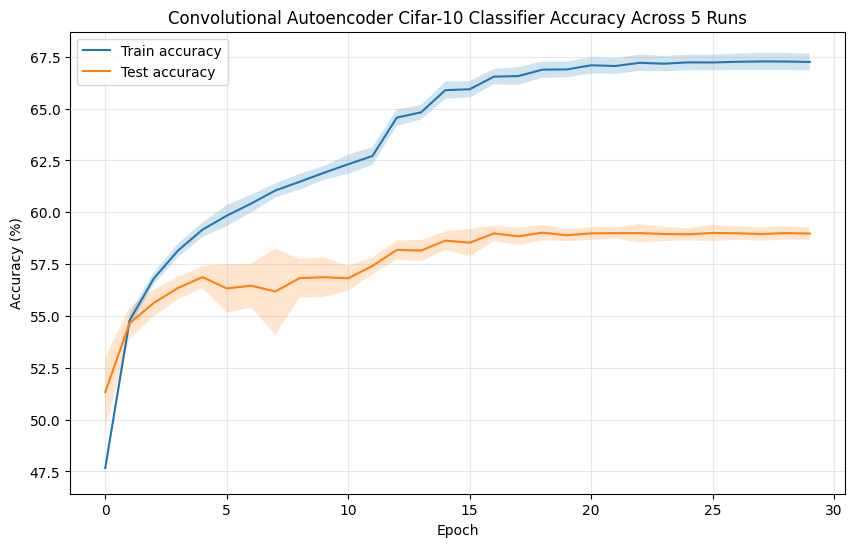

In [51]:
epochs = np.arange(len(mean_acc))



plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Convolutional Autoencoder Cifar-10 Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

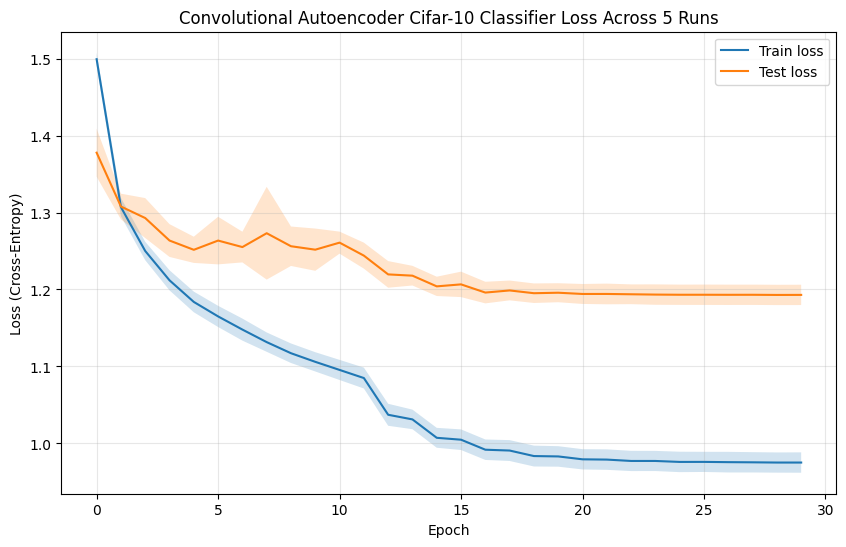

In [52]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("Convolutional Autoencoder Cifar-10 Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [53]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 85.0693359375
All peak memories (including the warm up run):


[84.9072265625, 85.0693359375, 85.0693359375, 85.0693359375, 85.0693359375]

In [54]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 584.3843910082498 
All training times for the 100 epochs over the 10 runs:
[585.91873574 584.41808576 584.53905248 582.66169006]
[585.8245238219997, 585.9187357359997, 584.4180857579995, 584.5390524820004, 582.6616900569998]


In [55]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")

print(" " \
"")
print(f"Min avg Encoder Loss: {ae_df["encoder_mean_loss"].min():.2f} (to 10 dp: {ae_df["encoder_mean_loss"].min():.10f})")

Max avg train accuracy: 67.27
 
Max avg test accuracy: 59.02
 
Min train avg Loss: 0.98
 
Min avg Encoder Loss: 0.04 (to 10 dp: 0.0357050163)


In [56]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 67.25
final test mean accuracy: 58.97


In [57]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 0.41
the above test accuracy with std: 0.30


In [58]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 67.17 ± 0.12%
average test mean accuracy final 10 epochs: 58.97 ± 0.03%


In [19]:
runs = np.array([run0, run1, run2, run3, run4])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 58.98 ± 0.33%


# STL10

In [59]:
#count how many params of the model...


device = torch.device('cuda')

model = weight_tied_conv_autoencoder.CNN_AE(    
        input_dims=96,
        in_channels=3,
        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        kernel_size=5,
        stride=1,
        padding=2,

        bias=False,

        n_filters=16,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 3, 5, 5) -> 1200
fc.weight            (10, 36864) -> 368640
fc.bias              (10,) -> 10
369850


In [60]:

stl10_root = "../datasets/STL10"

base_transform = transforms.ToTensor()

stl10_train = datasets.STL10(
    root=stl10_root,
    split="train",
    download=True,
    transform=base_transform
)

stl10_test = datasets.STL10(
    root=stl10_root,
    split="test",
    download=True,
    transform=base_transform
)

100%|██████████| 2.64G/2.64G [09:27<00:00, 4.65MB/s] 


In [ ]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_linear_annealing_ae_cnn_weight_tied(
        stl10_train,
        stl10_test,
        input_dims=96,
        in_channels=3,
   
        learning_rate=0.001,


        bias=False,   
        n_ae_epochs=1,      
        n_classifier_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0773
Training classifier...
Epoch [1/30], Task Training Loss: 2.3253, Accuracy: 35.04%, Task Test Loss: 1.5128303070068359, Task Test Accuracy: 47.1875% LR: 0.001000
Epoch [2/30], Task Training Loss: 1.1964, Accuracy: 57.86%, Task Test Loss: 1.668072777748108, Task Test Accuracy: 46.8625% LR: 0.001000
Epoch [3/30], Task Training Loss: 0.9754, Accuracy: 65.46%, Task Test Loss: 1.8297049360275268, Task Test Accuracy: 44.4125% LR: 0.001000
Epoch [4/30], Task Training Loss: 0.8187, Accuracy: 72.02%, Task Test Loss: 1.5537573347091675, Task Test Accuracy: 50.525% LR: 0.001000
Epoch [5/30], Task Training Loss: 0.6202, Accuracy: 79.04%, Task Test Loss: 1.6172023859024047, Task Test Accuracy: 50.3125% LR: 0.001000
Epoch [6/30], Task Training Loss: 0.4880, Accuracy: 85.86%, Task Test Loss: 1.605904356956482, Task Test Accuracy: 50.6625% LR: 0.001000
Epoch [7/30], Task Training Loss: 0.4238, Accuracy: 87.28%, Task Test Loss: 1.66266784095

In [20]:
#extracting final 10 epochs from runs:

run1 = [52.3625, 52.2125, 52.275, 52.25,
    52.3, 52.225, 52.2875, 52.25, 52.275, 52.25
]

run2=[52.3125, 52.4375, 52.475, 52.3625,
    52.3875, 52.3625, 52.375, 52.375, 52.425, 52.3375]

run3=[53.3, 53.3625, 53.225, 53.3375,
    53.35, 53.3875, 53.2875, 53.3375, 53.325, 53.375]

run4=[53.225, 53.2375, 53.1, 53.1125,
    53.1, 53.0625, 53.1375, 53.125, 53.125, 53.1375]

run5=[ 51.9, 52.0375, 51.9875, 51.875,
    51.925, 51.9125, 51.8625, 51.825, 51.875, 51.9]



In [62]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories)
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


ae_epochs= np.arange(1, len(encoder_mean_loss)+1)

epochs = np.arange(1, len(task_mean_loss)+1)



In [63]:
ae_df = pd.DataFrame({
    "epoch": ae_epochs,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})


classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [64]:
ae_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal_stl10_ae_epoch_results.csv",
    index=False,
)

In [65]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_optimal_linear_1update_anneal__stl10_classifer_epoch_results.csv",
    index=False,
)

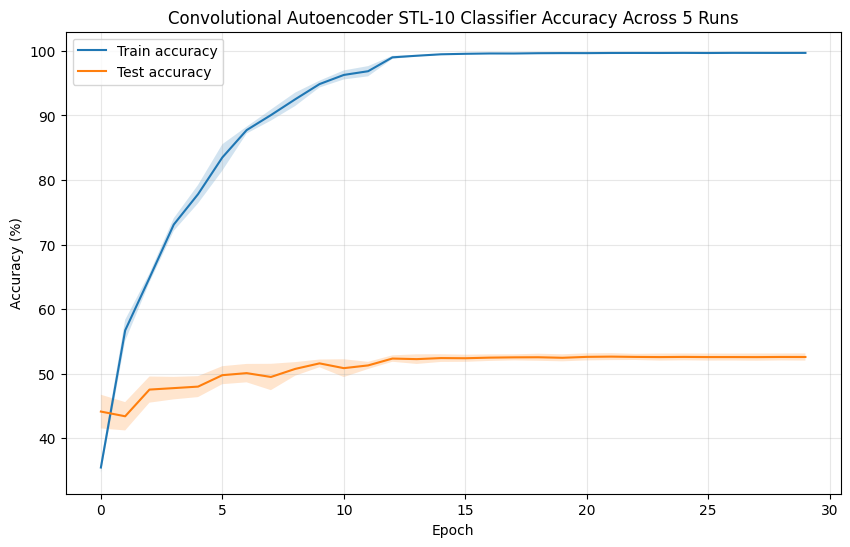

In [66]:
epochs = np.arange(len(mean_acc))



plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Convolutional Autoencoder STL-10 Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

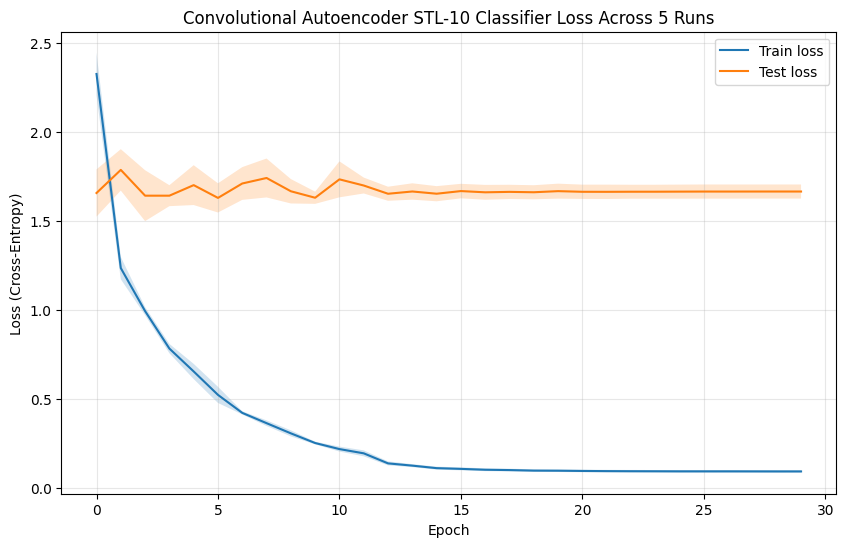

In [67]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("Convolutional Autoencoder STL-10 Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [68]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 227.38232421875
All peak memories (including the warm up run):


[225.72021484375,
 227.13232421875,
 227.63232421875,
 227.13232421875,
 227.63232421875]

In [69]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 201.52638311400005 
All training times for the 100 epochs over the 10 runs:
[200.84018557 200.77226388 200.02312955 204.46995345]
[201.49123525399955, 200.84018557200034, 200.77226387599876, 200.02312955399975, 204.46995345400137]


In [70]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")

print(" " \
"")
print(f"Min avg Encoder Loss: {ae_df["encoder_mean_loss"].min():.2f} (to 10 dp: {ae_df["encoder_mean_loss"].min():.10f})")

Max avg train accuracy: 99.68
 
Max avg test accuracy: 52.66
 
Min train avg Loss: 0.09
 
Min avg Encoder Loss: 0.07 (to 10 dp: 0.0679092306)


In [71]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 99.68
final test mean accuracy: 52.60


In [72]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 0.03
the above test accuracy with std: 0.56


In [73]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 99.67 ± 0.01%
average test mean accuracy final 10 epochs: 52.59 ± 0.04%


In [21]:
runs = np.array([run1, run2, run3, run4, run5])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 52.61 ± 0.54%


# Running the training and test procedure for the standard CNN
### For comparison with all other methods (all other methods being filters as autoencoders model, convolutional autoencoder, and hebb model)

# MNIST

In [5]:
from torchvision import datasets, transforms


In [6]:
#controlling randomness
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

## Inspecting model

In [40]:
#count how many params of the model...


device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=28,
        in_channels=1,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        kernel_size=5,
        stride=1,
        padding=2,
        
        n_filters=16,
        bias=False,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (16, 1, 5, 5) -> 400
fc.weight            (10, 3136) -> 31360
fc.bias              (10,) -> 10
31770


In [7]:

mnist_root = "../datasets/mnist"

base_transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root=mnist_root,
    train=True,
    download=True,
    transform=base_transform
)

mnist_test = datasets.MNIST(
    root=mnist_root,
    train=False,
    download=True,
    transform=base_transform
)

In [ ]:
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_annealing_cnn(
        mnist_train,
        mnist_test,
        input_dims=28,
        in_channels=1,
   
        learning_rate=0.001,


        bias=False,       
        n_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )


    all_task_histories.append(training_history["train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/30], Training Loss: 0.2637, Training Accuracy: 92.36, Task Test Loss: 0.1276644324041476, Task Test Accuracy: 96.37% LR: 0.001000
Epoch [2/30], Training Loss: 0.1205, Training Accuracy: 96.52, Task Test Loss: 0.09319389853507849, Task Test Accuracy: 97.28% LR: 0.001000
Epoch [3/30], Training Loss: 0.0930, Training Accuracy: 97.34, Task Test Loss: 0.07881476772818596, Task Test Accuracy: 97.66% LR: 0.001000
Epoch [4/30], Training Loss: 0.0803, Training Accuracy: 97.58, Task Test Loss: 0.07301126467953821, Task Test Accuracy: 97.73% LR: 0.001000
Epoch [5/30], Training Loss: 0.0720, Training Accuracy: 97.82, Task Test Loss: 0.06812635652578561, Task Test Accuracy: 97.82% LR: 0.001000
Epoch [6/30], Training Loss: 0.0655, Training Accuracy: 98.05, Task Test Loss: 0.08083182535353739, Task Test Accuracy: 97.59% LR: 0.001000
Epoch [7/30], Training Loss: 0.0613, Training Accuracy: 98.13, Task Test Loss: 0.06962674742291687, Task Test Accuracy: 97.8% LR: 0.

In [22]:
run1= [98.56, 98.51, 98.50, 98.50, 98.53, 98.50, 98.50, 98.48, 98.50, 98.48]
run2=[98.40, 98.43, 98.40, 98.38, 98.39, 98.41, 98.38, 98.41, 98.40, 98.40]
run3=[98.53, 98.54, 98.53, 98.51, 98.53, 98.50, 98.54, 98.52, 98.53, 98.52]
run4=[98.60, 98.61, 98.59, 98.57, 98.61, 98.62, 98.59, 98.60, 98.60, 98.61]
run5=[98.42, 98.45, 98.44, 98.45, 98.43, 98.45, 98.47, 98.45, 98.45, 98.45]

In [11]:
#make averages here

#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()



epochs = np.arange(1, len(task_mean_loss)+1)



In [12]:
classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_anneal_epoch_results.csv",
    index=False,
)

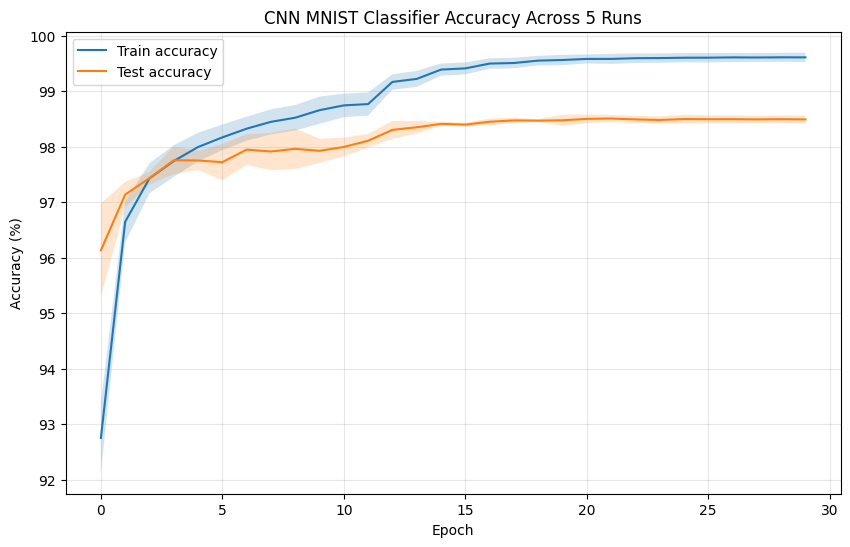

In [16]:
epochs = np.arange(len(mean_acc))


plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN MNIST Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

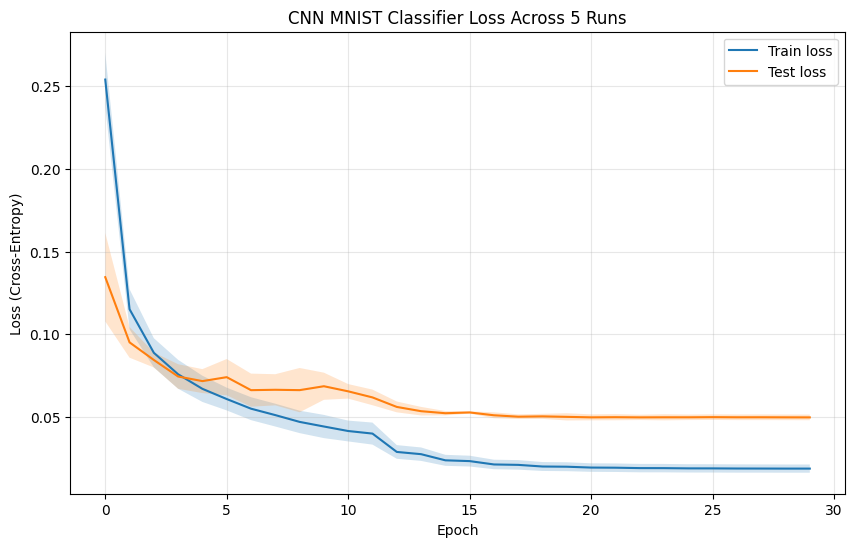

In [17]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("CNN MNIST Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 75.1650390625
All peak memories (including the warm up run):


[74.9208984375, 75.1650390625, 75.1650390625, 75.1650390625, 75.1650390625]

In [19]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 319.61556862525 
All training times for the 100 epochs over the 10 runs:
[317.99555315 317.91698748 318.80637819 323.74335568]
[316.109451606, 317.99555315400016, 317.91698748399995, 318.80637818700006, 323.74335567599974]


In [20]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")


Max avg train accuracy: 99.61
 
Max avg test accuracy: 98.51
 
Min train avg Loss: 0.02


In [21]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 99.61
final test mean accuracy: 98.49


In [22]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 0.08
the above test accuracy with std: 0.07


In [23]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 99.60 ± 0.01%
average test mean accuracy final 10 epochs: 98.49 ± 0.01%


In [23]:
runs = np.array([run1, run2, run3, run4, run5])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 98.50 ± 0.07%


# FMNIST

In [24]:
#getting data with minimal preprocessing

fmnist_root = "../datasets/fmnist"

base_transform = transforms.ToTensor()

fmnist_train = datasets.FashionMNIST(
    root=fmnist_root,
    train=True,
    download=True,
    transform=base_transform
)

fmnist_test = datasets.FashionMNIST(
    root=fmnist_root,
    train=False,
    download=True,
    transform=base_transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.02MB/s]


In [ ]:
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_annealing_cnn(
        fmnist_train,
        fmnist_test,
        input_dims=28,
        in_channels=1,
   
        learning_rate=0.001,


        bias=False,       
        n_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )


    all_task_histories.append(training_history["train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/30], Training Loss: 0.4822, Training Accuracy: 82.90, Task Test Loss: 0.4098615221157195, Task Test Accuracy: 85.55% LR: 0.001000
Epoch [2/30], Training Loss: 0.3764, Training Accuracy: 86.80, Task Test Loss: 0.3664115371218153, Task Test Accuracy: 87.44% LR: 0.001000
Epoch [3/30], Training Loss: 0.3484, Training Accuracy: 87.77, Task Test Loss: 0.36460072219751444, Task Test Accuracy: 87.63% LR: 0.001000
Epoch [4/30], Training Loss: 0.3272, Training Accuracy: 88.40, Task Test Loss: 0.36043682219875844, Task Test Accuracy: 86.84% LR: 0.001000
Epoch [5/30], Training Loss: 0.3185, Training Accuracy: 88.72, Task Test Loss: 0.33621351885947454, Task Test Accuracy: 88.47% LR: 0.001000
Epoch [6/30], Training Loss: 0.3066, Training Accuracy: 89.26, Task Test Loss: 0.3517829263286226, Task Test Accuracy: 87.68% LR: 0.001000
Epoch [7/30], Training Loss: 0.2998, Training Accuracy: 89.38, Task Test Loss: 0.358875031683855, Task Test Accuracy: 87.51% LR: 0.001

In [24]:
run1=[89.99, 89.95, 90.06, 89.98, 90.08, 90.04, 90.02, 90.02, 90.05, 90.04]
run2=[89.93, 89.95, 89.98, 90.04, 89.99, 89.98, 89.94, 89.96, 90.02, 89.97]
run3=[90.16, 90.08, 89.94, 89.90, 90.00, 90.06, 90.06, 90.03, 90.03, 89.97]
run4=[90.27, 90.39, 90.34, 90.26, 90.30, 90.25, 90.27, 90.28, 90.32, 90.19]
run5=[89.99, 89.98, 89.96, 89.95, 90.10, 89.98, 89.92, 89.97, 89.99, 89.99]


In [26]:
#make averages here

#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()



epochs = np.arange(1, len(task_mean_loss)+1)



In [27]:
classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [28]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_anneal_fmnist_epoch_results.csv",
    index=False,
)

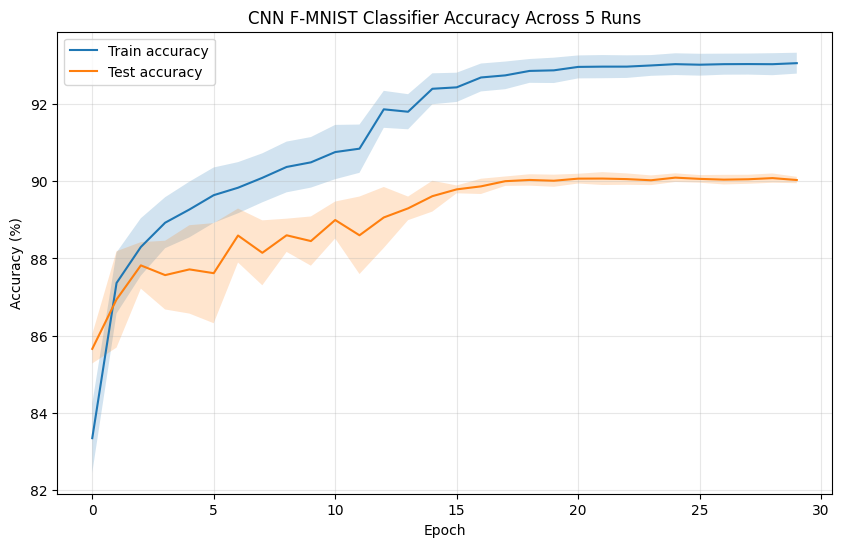

In [29]:
epochs = np.arange(len(mean_acc))


plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN F-MNIST Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

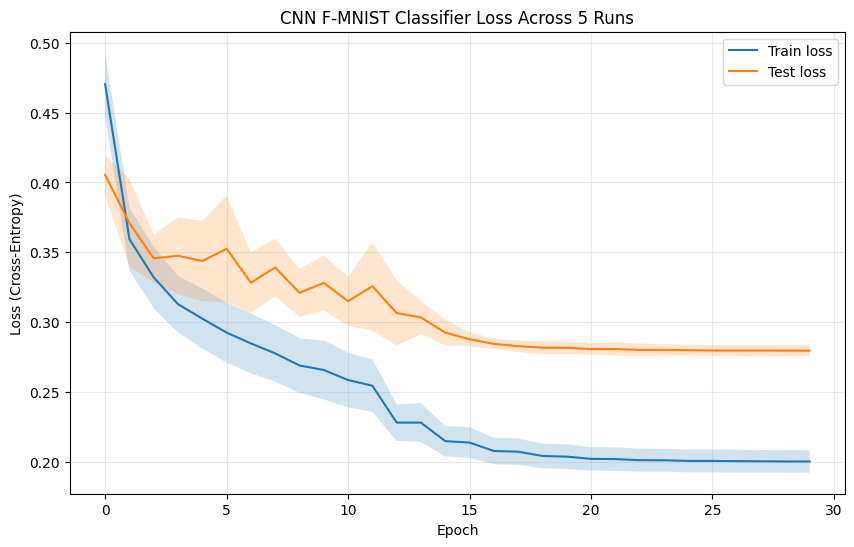

In [30]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("CNN F-MNIST Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 75.1650390625
All peak memories (including the warm up run):


[75.1650390625, 75.1650390625, 75.1650390625, 75.1650390625, 75.1650390625]

In [32]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 333.2541231199999 
All training times for the 100 epochs over the 10 runs:
[331.84834272 335.82717883 333.90929686 331.43167407]
[330.01577961600015, 331.8483427169999, 335.8271788339998, 333.90929686399977, 331.43167406500015]


In [33]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")


Max avg train accuracy: 93.06
 
Max avg test accuracy: 90.09
 
Min train avg Loss: 0.20


In [34]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 93.06
final test mean accuracy: 90.03


In [35]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 0.27
the above test accuracy with std: 0.08


In [36]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 92.99 ± 0.05%
average test mean accuracy final 10 epochs: 90.06 ± 0.02%


In [25]:

runs = np.array([run1, run2, run3, run4, run5])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 90.06 ± 0.12%


# Cifar-10

## inspect model

In [41]:
#count how many params of the model...


device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=32,
        in_channels=3,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        kernel_size=5,
        stride=1,
        padding=2,
        
        n_filters=16,
        bias=False,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (16, 3, 5, 5) -> 1200
fc.weight            (10, 4096) -> 40960
fc.bias              (10,) -> 10
42170


In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayush1220/cifar10")

print("Path to dataset files:", path)

100%|██████████| 139M/139M [00:00<00:00, 176MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2


## Getting cifar-10

In [43]:
print(os.listdir(path))

['cifar10']


In [44]:
cifar_path = os.path.join(path, "cifar10")

In [45]:
cifar_train_path = os.path.join(cifar_path,"train")

In [46]:
cifar_test_path = os.path.join(cifar_path,"test")

In [47]:
final_transform = transforms.Compose([
    transforms.ToTensor()
])

In [48]:
train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=final_transform
)

test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=final_transform
)

In [49]:
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_annealing_cnn(
        train_dataset,
        test_dataset,
        input_dims=32,
        in_channels=3,
   
        learning_rate=0.001,


        bias=False,       
        n_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )


    all_task_histories.append(training_history["train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/30], Training Loss: 1.6466, Training Accuracy: 42.21, Task Test Loss: 1.4912564222979698, Task Test Accuracy: 49.08% LR: 0.001000
Epoch [2/30], Training Loss: 1.4452, Training Accuracy: 49.29, Task Test Loss: 1.3566956732683122, Task Test Accuracy: 52.92% LR: 0.001000
Epoch [3/30], Training Loss: 1.3740, Training Accuracy: 52.13, Task Test Loss: 1.4804230708225516, Task Test Accuracy: 48.18% LR: 0.001000
Epoch [4/30], Training Loss: 1.3440, Training Accuracy: 53.14, Task Test Loss: 1.3544475774096836, Task Test Accuracy: 52.14% LR: 0.001000
Epoch [5/30], Training Loss: 1.3158, Training Accuracy: 54.03, Task Test Loss: 1.306919170792695, Task Test Accuracy: 54.35% LR: 0.001000
Epoch [6/30], Training Loss: 1.2990, Training Accuracy: 54.77, Task Test Loss: 1.4240665314303842, Task Test Accuracy: 50.53% LR: 0.001000
Epoch [7/30], Training Loss: 1.2736, Training Accuracy: 55.67, Task Test Loss: 1.304974890058967, Task Test Accuracy: 54.97% LR: 0.001000


In [26]:
run1=[57.79, 57.83, 58.03, 58.02, 57.65, 57.99, 57.95, 57.99, 57.99, 57.92]
run2=[57.80, 57.86, 57.94, 58.00, 57.98, 58.25, 58.25, 58.04, 58.21, 58.10]
run3=[56.64, 56.26, 56.71, 57.09, 56.70, 56.76, 56.95, 56.92, 56.97, 57.02]
run4=[57.27, 57.49, 57.67, 57.26, 57.49, 57.54, 57.43, 57.52, 57.49, 57.57]
run5=[56.89, 56.59, 56.90, 57.04, 57.02, 56.86, 57.06, 57.10, 57.00, 56.99]

In [50]:
#make averages here

#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()



epochs = np.arange(1, len(task_mean_loss)+1)



In [51]:
classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [52]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_anneal_epoch_results.csv",
    index=False,
)

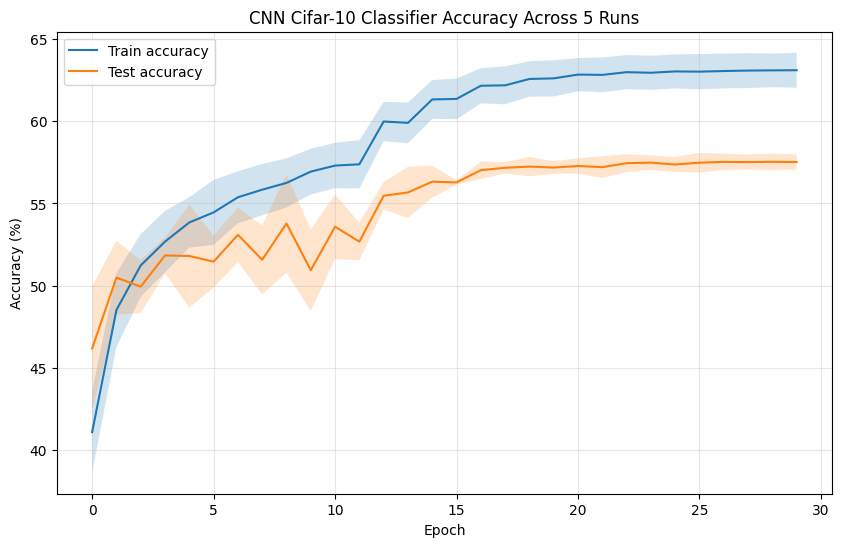

In [53]:
epochs = np.arange(len(mean_acc))


plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Cifar-10 Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

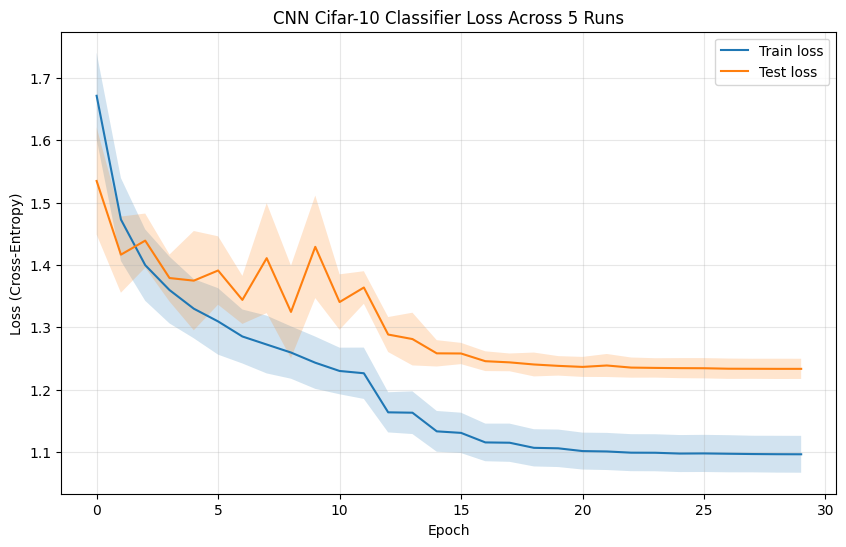

In [54]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("CNN Cifar-10 Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 78.9072265625
All peak memories (including the warm up run):


[78.583984375, 78.9072265625, 78.9072265625, 78.9072265625, 78.9072265625]

In [56]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 559.2469289402502 
All training times for the 100 epochs over the 10 runs:
[554.66206958 560.54547338 562.06044117 559.71973164]
[556.492576787, 554.6620695760002, 560.5454733830002, 562.0604411659997, 559.7197316360007]


In [57]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")


Max avg train accuracy: 63.10
 
Max avg test accuracy: 57.53
 
Min train avg Loss: 1.10


In [58]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 63.10
final test mean accuracy: 57.52


In [59]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 1.06
the above test accuracy with std: 0.45


In [60]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 62.94 ± 0.14%
average test mean accuracy final 10 epochs: 57.40 ± 0.13%


In [27]:
runs = np.array([run1, run2, run3, run4, run5])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 57.44 ± 0.50%


# STL-10

## Inspect model

In [7]:
#count how many params of the model...


device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=96,
        in_channels=3,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        kernel_size=5,
        stride=1,
        padding=2,
        
        n_filters=16,
        bias=False,
        classes=10
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (16, 3, 5, 5) -> 1200
fc.weight            (10, 36864) -> 368640
fc.bias              (10,) -> 10
369850


In [62]:

stl10_root = "../datasets/STL10"

base_transform = transforms.ToTensor()

stl10_train = datasets.STL10(
    root=stl10_root,
    split="train",
    download=True,
    transform=base_transform
)

stl10_test = datasets.STL10(
    root=stl10_root,
    split="test",
    download=True,
    transform=base_transform
)

100%|██████████| 2.64G/2.64G [04:18<00:00, 10.2MB/s]


In [63]:
all_task_histories = []
all_accuracy_histories=[]

all_task_test_histories =[]
all_accuracy_test_histories =[]


peak_memory =[]
run_times= []

for seed in range(5): 

    print(f"model run: {seed}")


    model, training_history, test_history, elapsed = cnn_experiments.train_annelaing_cnn(
        stl10_train,
        stl10_test,
        input_dims=96,
        in_channels=3,
   
        learning_rate=0.001,


        bias=False,       
        n_epochs=30,
        batch_size=64,
        n_filters=16,

        stride=1,
        padding=2,
        kernel_size=5,

        pool_kernel_size=4,
        pool_stride=2,
        pool_padding=1,

        n_classes=10,
        seed=seed,
        seed_worker=seed_worker
    )


    all_task_histories.append(training_history["train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])


    all_task_test_histories.append(test_history["task_loss"])
    all_accuracy_test_histories.append(test_history["task_accuracy"])



    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda


Epoch [1/30], Training Loss: 5.2650, Training Accuracy: 27.50, Task Test Loss: 2.468266357421875, Task Test Accuracy: 34.925% LR: 0.001000
Epoch [2/30], Training Loss: 1.6567, Training Accuracy: 44.20, Task Test Loss: 2.7609619140625, Task Test Accuracy: 29.8375% LR: 0.001000
Epoch [3/30], Training Loss: 1.4984, Training Accuracy: 49.40, Task Test Loss: 1.953428955078125, Task Test Accuracy: 43.5125% LR: 0.001000
Epoch [4/30], Training Loss: 1.2963, Training Accuracy: 54.72, Task Test Loss: 2.02930810546875, Task Test Accuracy: 39.7375% LR: 0.001000
Epoch [5/30], Training Loss: 1.1977, Training Accuracy: 58.60, Task Test Loss: 1.926464111328125, Task Test Accuracy: 42.5375% LR: 0.001000
Epoch [6/30], Training Loss: 1.0878, Training Accuracy: 62.84, Task Test Loss: 1.726836181640625, Task Test Accuracy: 46.1625% LR: 0.001000
Epoch [7/30], Training Loss: 1.0937, Training Accuracy: 64.34, Task Test Loss: 2.075876220703125, Task Test Accuracy: 42.9% LR: 0.001000
Epoch [8/30], Training Loss

In [28]:
run1=[52.5125, 52.5375, 52.525, 52.3875, 52.5125, 52.5875, 52.4875, 52.375, 52.3625, 52.45]
run2=[ 51.3125, 51.6375, 51.4, 51.375, 51.35, 51.325, 51.5, 51.5, 51.4375, 51.325]
run3=[50.275, 50.4625, 50.5375, 50.2375, 50.7375, 50.625, 50.7625, 50.7875, 50.825, 50.7625]
run4=[52.85, 52.825, 52.8625, 52.6375, 53.0125, 52.8, 52.8625, 52.8875, 52.8875, 52.9]
run5=[51.75, 51.8125, 51.9625, 51.7375, 51.8125, 51.9125, 51.775, 51.9125, 51.8125, 51.875]

In [64]:
#make averages here

#avg task loss
task_losses = np.array(all_task_histories)
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories)
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg test task loss
test_task_losses = np.array(all_task_test_histories)
test_task_mean_loss = test_task_losses.mean(axis=0)
test_task_std_loss  = test_task_losses.std(axis=0)


#avg test accuracy
test_accuracies = np.array(all_accuracy_test_histories)
test_mean_acc = test_accuracies.mean(axis=0)
test_std_acc  = test_accuracies.std(axis=0)


#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()



epochs = np.arange(1, len(task_mean_loss)+1)



In [65]:
classifier_df = pd.DataFrame({
    #train
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,

    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,

    #test
    "test_mean_loss": test_task_mean_loss,
    "test_task_std_loss" : test_task_std_loss,

    "test_mean_accuracy": test_mean_acc,
    "test_std_accuracy": test_std_acc


})

In [66]:
classifier_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_anneal_stl10_epoch_results.csv",
    index=False,
)

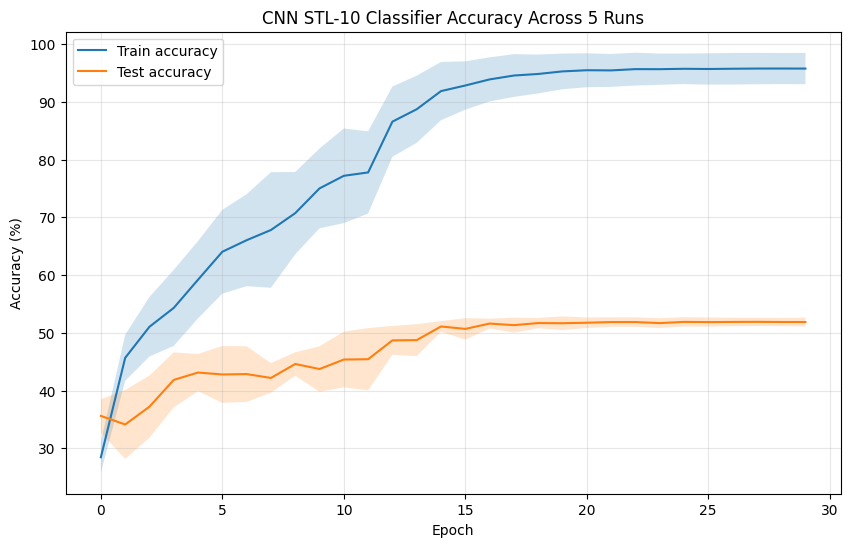

In [67]:
epochs = np.arange(len(mean_acc))


plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, label="Train accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

plt.plot(epochs, test_mean_acc, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean_acc - test_std_acc,
    test_mean_acc + test_std_acc,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN STL-10 Classifier Accuracy Across 5 Runs")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

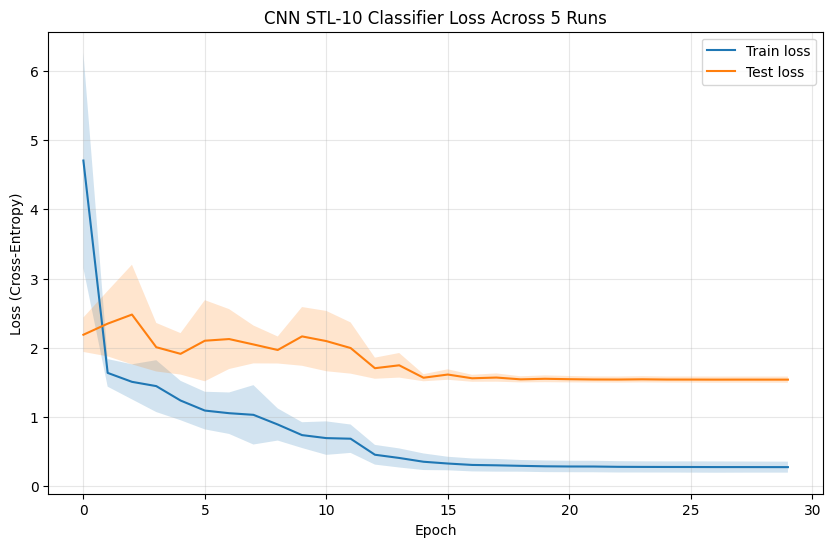

In [68]:

epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(10, 6))

plt.plot(epochs, task_mean_loss, label="Train loss")
plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2
)

plt.plot(epochs, test_task_mean_loss, label="Test loss")
plt.fill_between(
    epochs,
    test_task_mean_loss - test_task_std_loss,
    test_task_mean_loss + test_task_std_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("CNN STL-10 Classifier Loss Across 5 Runs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [69]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 195.75244140625
All peak memories (including the warm up run):


[193.02294921875,
 195.81494140625,
 196.65869140625,
 195.00244140625,
 195.53369140625]

In [70]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
print(times) #exluding the first run
print(run_times)

Mean training time for 100 epochs over the 10 runs: 193.98533266850063 
All training times for the 100 epochs over the 10 runs:
[195.29347268 194.65532739 193.52668421 192.4658464 ]
[192.32888875900062, 195.2934726830008, 194.65532739000082, 193.5266842050005, 192.46584639600042]


In [71]:
print(f"Max avg train accuracy: {classifier_df["mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max (not to be compared with our average best result for the hebb models)

print(" " \
"")
print(f"Max avg test accuracy: {classifier_df["test_mean_accuracy"].max():.2f}") #that is, out of the runs, take the average every epoch, then take the max

print(" " \
"")
print(f"Min train avg Loss: {classifier_df["task_mean_loss"].min():.2f}")


Max avg train accuracy: 95.77
 
Max avg test accuracy: 51.89
 
Min train avg Loss: 0.27


In [72]:
print(f"final train mean accuracy: {classifier_df["mean_accuracy"][29]:.2f}")
print(f"final test mean accuracy: {classifier_df["test_mean_accuracy"][29]:.2f}")


final train mean accuracy: 95.76
final test mean accuracy: 51.86


In [73]:
#where std is deviation across runs
print(f"the above train accuracy with std: {classifier_df['std_accuracy'][29]:.2f}")
print(f"the above test accuracy with std: {classifier_df['test_std_accuracy'][29]:.2f}")

the above train accuracy with std: 2.71
the above test accuracy with std: 0.76


In [74]:
#average over final 10 epochs: (where std is variability of the epoch means)
print(f"average train mean accuracy final 10 epochs: {np.mean(classifier_df["mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["mean_accuracy"][19:29]):.2f}%")
print(f"average test mean accuracy final 10 epochs: {np.mean(classifier_df["test_mean_accuracy"][19:29]):.2f} ± {np.std(classifier_df["test_mean_accuracy"][19:29]):.2f}%")

average train mean accuracy final 10 epochs: 95.62 ± 0.16%
average test mean accuracy final 10 epochs: 51.82 ± 0.09%


In [29]:
runs = np.array([run1, run2, run3, run4, run5])

# Mean accuracy over the final 10 epochs for each run
run_means = np.mean(runs, axis=1)

# Overall mean and standard deviation across runs
mean = np.mean(run_means)
std = np.std(run_means)

print(f"Final 10 epochs: {mean:.2f} ± {std:.2f}%")

Final 10 epochs: 51.84 ± 0.79%


# End